## End-to-End HHL Validation for Graph-Based Credit Risk Propagation (Qubitization + QPE + Chebyshev)

In [1]:
"""
Notebook goal:
--------------

Construct and validate a complete executable HHL pipeline
for graph-based credit-risk propagation models using a
qubitization-compatible architecture.

The linear system of interest is

    A x = b

where A is a sparse Hermitian matrix arising from one of
the following financial contagion models:

Model 1:
    A = L + mu I

Model 2:
    A = I - alpha P_sym

with

    L      = graph Laplacian
    P_sym  = symmetric normalized adjacency matrix.

The notebook implements and validates the following HHL
workflow:

1. Sparse financial graph construction
2. Linear-system assembly
3. Sparse shock-state preparation |b>
4. Walk-operator-based QPE architecture
5. Eigenvalue encoding into a phase register
6. Polynomial approximation of 1/lambda
7. Controlled HHL rotation
8. Polynomial uncomputation
9. Inverse QPE
10. Ancilla post-selection
11. Extraction of the quantum solution state |x>
12. Comparison against the classical solution
13. Financial readout procedures

The notebook performs full statevector validation of the
algorithm and compares the resulting quantum solution
against the classical reference solution

    x = A^{-1} b.

The following quantities are evaluated:

    - Fidelity
    - L1 error
    - L2 error
    - L-infinity error
    - Residual norm ||Ax - b||

The notebook additionally validates two application-level
readout modes relevant to credit-risk propagation:

    1. Top-k risky node discovery
    2. Single-node risk estimation

including both histogram-based sampling and direct
projector measurements of the observable

    |eta><eta|.

Several high-level components (walk operators, Hamiltonian
simulation blocks, polynomial-evaluation operators, and
controlled rotations) are represented as validated
oracle-level unitaries rather than fault-tolerant gate
decompositions. The focus is verification of algorithmic
correctness, register conventions, state evolution, and
financial readout methodology.

Subsequent notebooks will replace these oracle-level
components with explicit circuit constructions suitable
for qubitization and sparse Hamiltonian simulation.
"""

# ============================================================
# Cell 1 : Imports and Initializations
# ============================================================

# -----------------------
# Qiskit
# -----------------------
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator

# -----------------------
# Numerical libraries
# -----------------------
import numpy as np
import scipy.linalg as la
import scipy.sparse as sp
import scipy.sparse.linalg as spla


# -----------------------
# Plotting
# -----------------------
import matplotlib.pyplot as plt

# -----------------------
# Miscellaneous
# -----------------------
import math as m
import warnings

warnings.filterwarnings('ignore')

# -----------------------
# Custom utility functions
# -----------------------
import Our_Qiskit_Functions as oq

# ============================================================
# Simulators
# ============================================================

state_sim = AerSimulator(method='statevector')
qasm_sim = AerSimulator()

# ============================================================
# Global NumPy settings
# ============================================================

np.set_printoptions(
    precision=4,
    suppress=True,
    linewidth=150
)

# ============================================================
# Random seed
# ============================================================

SEED = 42
rng = np.random.default_rng(SEED)

print("Imports successful.")
print(f"Random seed = {SEED}")

Imports successful.
Random seed = 42


In [2]:
# ============================================================
# Cell 2 : Master Configuration
# ============================================================

# -----------------------
# Problem size
# -----------------------

# Total number of nodes INCLUDING dummy nodes.
# Must be a power of 2.
N = 32

# Number of system qubits
n = int(np.log2(N))

assert 2**n == N, "N must be a power of 2."

# -----------------------
# Shock vector sparsity
# -----------------------

# gamma = 2^{ floor(log2( SHOCK_SPARSITY_FACTOR * log2(N) )) }

SHOCK_SPARSITY_FACTOR = 2

assert SHOCK_SPARSITY_FACTOR > 0, \
    "SHOCK_SPARSITY_FACTOR must be positive."

gamma = 2 ** int(
    np.floor(
        np.log2(
            SHOCK_SPARSITY_FACTOR * np.log2(N)
        )
    )
)

# gamma/2 dummy nodes are required
assert gamma % 2 == 0, "gamma must be even."

N_dummy = gamma // 2
N_real = N - N_dummy

assert N_real > 0, \
    "Number of real nodes must be positive."

# -----------------------
# Sparsity specification
# -----------------------

# Sparsity of J
#
# Every real node has exactly s_J neighbours.
#
# Since A = (1-alpha)I + alpha L,
# the diagonal contributes one additional nonzero,
# so
#
#     s = s_J + 1
#
s_J = 3

assert s_J >= 2, \
    "s_J must be at least 2."

# Sparsity of A
s = s_J + 1

# -----------------------
# Edge-weight specification
# -----------------------

# Minimum positive edge weight
J_min = 0.5

assert J_min > 0, \
    "J_min must be strictly positive."

# Ensure 1/J_min is an integer
assert np.isclose(
    1 / J_min,
    round(1 / J_min)
), "1/J_min must be an integer."

# All positive edge weights will be integer multiples of J_min:
#
#     J_ij = k_ij * J_min
#
# where
#
#     k_ij = 1, 2, 3, ...
#

# -----------------------
# Diffusion parameter
# -----------------------

alpha = 0.5

assert 0 < alpha < 1, \
    "alpha must lie strictly between 0 and 1."



# ============================================================
# Precision-design thresholds
# ============================================================

#
# These thresholds define the smallest meaningful
# values that the oracle value register must be
# capable of resolving.
#
# They are NOT the actual values used in the
# particular instance.
#
# Instead, they define the class of matrices
# that this notebook is designed to handle.
#

ALPHA_THRESHOLD = 1e-2

J_MIN_THRESHOLD = 1e-2



# -----------------------
# Model choice
# -----------------------

# 1 :
# A = (1-alpha)I + alpha(D - J)
#
# 2 :
# A = (1-alpha)I + alpha(I - D^{-1/2} J D^{-1/2})
#

#model = 1
model = 2

assert model in [1, 2], \
    "model must be either 1 or 2."

# -----------------------
# Real-network graph type
# -----------------------

# Allowed values:
#
# "nearest"
# "random_regular"
# "irregular"
#

#graph_type = "nearest"
#graph_type = "random_regular"
graph_type = "irregular"

assert graph_type in [
    "nearest",
    "random_regular",
    "irregular"
], "Invalid graph type."

# ============================================================
# Configuration summary
# ============================================================

print("=" * 65)
print("Master Configuration")
print("=" * 65)

print(f"Total nodes N                           : {N}")
print(f"System qubits n = log2(N)               : {n}")

print()

print(f"Shock sparsity factor                   : {SHOCK_SPARSITY_FACTOR}")
print(f"Shock sparsity gamma                    : {gamma}")
print(f"Dummy nodes (gamma/2)                   : {N_dummy}")
print(f"Real nodes                              : {N_real}")

print()

print(f"Sparsity of J (s_J)                     : {s_J}")
print(f"Sparsity of A (s = s_J + 1)             : {s}")

print()

print(f"Minimum edge weight J_min               : {J_min}")
print(f"1 / J_min                               : {int(round(1/J_min))}")

print("Positive edge weights are multiples of J_min")

print()

print(f"Diffusion parameter alpha               : {alpha}")
print(f"Model                                   : {model}")
print(f"Graph type                              : {graph_type}")

print("=" * 65)

Master Configuration
Total nodes N                           : 32
System qubits n = log2(N)               : 5

Shock sparsity factor                   : 2
Shock sparsity gamma                    : 8
Dummy nodes (gamma/2)                   : 4
Real nodes                              : 28

Sparsity of J (s_J)                     : 3
Sparsity of A (s = s_J + 1)             : 4

Minimum edge weight J_min               : 0.5
1 / J_min                               : 2
Positive edge weights are multiples of J_min

Diffusion parameter alpha               : 0.5
Model                                   : 2
Graph type                              : irregular


In [3]:
# ============================================================
# Cell 3 : Node Partitions and Index Sets
# ============================================================

# ------------------------------------------------------------
# Real bank nodes
# ------------------------------------------------------------

real_nodes = np.arange(N_real)

# ------------------------------------------------------------
# Dummy nodes
# ------------------------------------------------------------

dummy_nodes = np.arange(N_real, N)

# ------------------------------------------------------------
# Useful sets (for O(1) membership tests)
# ------------------------------------------------------------

real_node_set = set(real_nodes)
dummy_node_set = set(dummy_nodes)

# ------------------------------------------------------------
# Consistency checks
# ------------------------------------------------------------

assert len(real_nodes) == N_real
assert len(dummy_nodes) == N_dummy

assert real_node_set.isdisjoint(dummy_node_set)

assert len(real_node_set.union(dummy_node_set)) == N

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("=" * 65)
print("Node Partition Summary")
print("=" * 65)

print(f"Total nodes (N)              : {N}")
print(f"Real nodes                   : {N_real}")
print(f"Dummy nodes                  : {N_dummy}")

print()

print(f"Real node indices            : "
      f"{real_nodes[0]} ... {real_nodes[-1]}")

if N_dummy > 0:
    print(f"Dummy node indices           : "
          f"{dummy_nodes[0]} ... {dummy_nodes[-1]}")
else:
    print("Dummy node indices           : None")

print()

print(f"Real node set size           : {len(real_node_set)}")
print(f"Dummy node set size          : {len(dummy_node_set)}")

print("=" * 65)

Node Partition Summary
Total nodes (N)              : 32
Real nodes                   : 28
Dummy nodes                  : 4

Real node indices            : 0 ... 27
Dummy node indices           : 28 ... 31

Real node set size           : 28
Dummy node set size          : 4


J_real Construction Summary
Graph type                          : irregular
Number of real nodes                : 28

Specified s_J                       : 3
Specified sparsity of A (s)         : 4

Minimum actual row sparsity         : 1
Maximum actual row sparsity         : 3

Minimum weighted degree d_min       : 0.5000
Maximum weighted degree d_max       : 3.0000

Number of undirected edges          : 26
Number of non-zero entries          : 52

Minimum positive J_ij               : 0.5000
Maximum positive J_ij               : 1.0000

First few rows of J_real:

Row 0:
    J[0,12] = 1.0
    J[0,21] = 1.0

Row 1:
    J[1,13] = 1.0
    J[1,25] = 0.5

Row 2:
    J[2,4] = 1.0
    J[2,26] = 0.5

Row 3:
    J[3,9] = 0.5
    J[3,20] = 0.5

Row 4:
    J[4,2] = 1.0

Row 5:
    J[5,10] = 0.5
    J[5,24] = 1.0

Row 6:
    J[6,20] = 0.5

Row 7:
    J[7,16] = 0.5

Row 8:
    J[8,13] = 0.5
    J[8,25] = 0.5

Row 9:
    J[9,3] = 0.5
    J[9,20] = 0.5


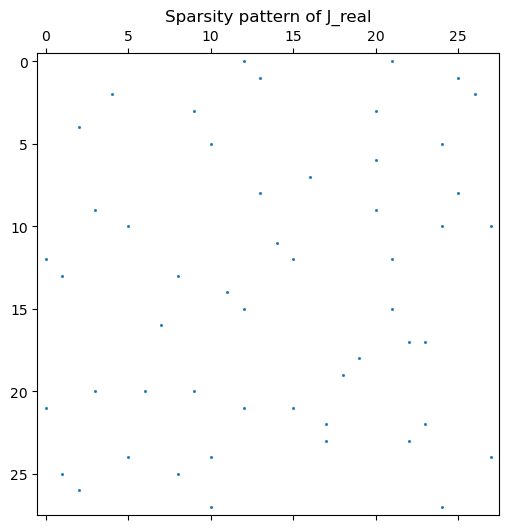

In [4]:
# ============================================================
# Cell 4 : Construct J_real
# ============================================================

# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def generate_weight(J_min, rng):
    """
    Generate a positive edge weight that is an integer
    multiple of J_min and at most 1.

    Returns a value in

        {J_min, 2 J_min, ..., 1}
    """

    max_multiple = int(round(1 / J_min))

    multiplier = rng.integers(1, max_multiple + 1)

    return multiplier * J_min


# ------------------------------------------------------------
# Nearest-neighbour graph
# ------------------------------------------------------------

def generate_nearest_J(N_nodes,
                       J_min):
    """
    Construct a single cycle:

        0 -> 1 -> 2 -> ... -> N-1 -> 0

    All edge weights are J_min.

    Intended primarily for debugging and the case s_J = 2.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    for i in range(N_nodes):

        j = (i + 1) % N_nodes

        J[i, j] = J_min
        J[j, i] = J_min

    return J.tocsr()


# ------------------------------------------------------------
# Random "almost regular" graph
# ------------------------------------------------------------

def generate_random_regular_J(N_nodes,
                              s_J,
                              J_min,
                              rng):
    """
    Randomly partition the nodes.

    Groups of size (s_J + 1):
        Construct complete graphs K_{s_J+1}
        with edge weights J_min.

    Remainder group:
        Construct a simple cycle.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    nodes = rng.permutation(N_nodes)

    group_size = s_J + 1

    n_full_groups = N_nodes // group_size

    remainder = N_nodes % group_size

    # --------------------------------------------------------
    # Full groups
    # --------------------------------------------------------

    start = 0

    for _ in range(n_full_groups):

        group = nodes[start:start + group_size]

        start += group_size

        # Complete graph
        for i in range(len(group)):

            for j in range(i + 1,
                           len(group)):

                u = group[i]
                v = group[j]

                J[u, v] = J_min
                J[v, u] = J_min

    # --------------------------------------------------------
    # Remainder group
    # --------------------------------------------------------

    if remainder >= 2:

        group = nodes[start:]

        for i in range(len(group)):

            u = group[i]

            v = group[(i + 1) % len(group)]

            J[u, v] = J_min
            J[v, u] = J_min

    elif remainder == 1:

        print(
            "Warning: One node in the remainder "
            "group has no real-network connections."
        )

    return J.tocsr()


# ------------------------------------------------------------
# Irregular graph
# ------------------------------------------------------------

def generate_irregular_J(N_nodes,
                         s_J,
                         J_min,
                         rng):
    """
    Construct a general irregular graph.

    Procedure:
    1. Partition the nodes into groups whose sizes
       are random integers between 2 and s_J + 1.
    2. Within each group, consider all pairings.
    3. Assign each pairing a weight chosen from

            {0, J_min, 2J_min, ..., 1}

    4. Repair isolated nodes by assigning one
       incident edge weight J_min.

    Guarantees:
        - symmetric,
        - zero diagonal,
        - J_ij >= J_min whenever J_ij > 0,
        - d_i >= J_min for every node.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    nodes = list(rng.permutation(N_nodes))

    groups = []

    # --------------------------------------------------------
    # Create random groups
    # --------------------------------------------------------

    while len(nodes) > 0:

        remaining = len(nodes)

        if remaining <= s_J + 1:

            group_size = remaining

        else:

            group_size = rng.integers(
                2,
                s_J + 2
            )

        group = nodes[:group_size]

        groups.append(group)

        nodes = nodes[group_size:]

    # --------------------------------------------------------
    # Populate each group
    # --------------------------------------------------------

    max_multiple = int(round(1 / J_min))

    for group in groups:

        m = len(group)

        if m == 1:
            continue

        # --------------------------------------------
        # Random pairings
        # --------------------------------------------

        for i in range(m):

            for j in range(i + 1,
                           m):

                u = group[i]
                v = group[j]

                multiplier = rng.integers(
                    0,
                    max_multiple + 1
                )

                weight = multiplier * J_min

                if weight > 0:

                    J[u, v] = weight
                    J[v, u] = weight

        # --------------------------------------------
        # Repair isolated nodes
        # --------------------------------------------

        for u in group:

            degree = J[u, :].sum()

            if degree == 0:

                candidates = [
                    v for v in group
                    if v != u
                ]

                if len(candidates) > 0:

                    v = rng.choice(candidates)

                    J[u, v] = J_min
                    J[v, u] = J_min

    return J.tocsr()


# ============================================================
# Construct J_real
# ============================================================

if graph_type == "nearest":

    J_real = generate_nearest_J(
        N_real,
        J_min
    )

elif graph_type == "random_regular":

    J_real = generate_random_regular_J(
        N_real,
        s_J,
        J_min,
        rng
    )

elif graph_type == "irregular":

    J_real = generate_irregular_J(
        N_real,
        s_J,
        J_min,
        rng
    )

else:

    raise ValueError(
        f"Unknown graph type: {graph_type}"
    )


# ============================================================
# Diagnostics
# ============================================================

row_sparsities = np.diff(J_real.indptr)

weighted_degrees = np.array(
    J_real.sum(axis=1)
).flatten()

positive_entries = J_real.data


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (J_real != J_real.T).nnz == 0, \
    "J_real is not symmetric."

assert np.allclose(
    J_real.diagonal(),
    0
), "J_real has non-zero diagonal entries."

assert np.all(
    weighted_degrees > 0
), "Some nodes have zero weighted degree."

assert np.all(
    positive_entries >= J_min
), "Some positive entries are smaller than J_min."

assert np.allclose(
    positive_entries / J_min,
    np.round(
        positive_entries / J_min
    )
), "Entries are not multiples of J_min."

assert np.all(
    row_sparsities <= s_J
), (
    "Actual sparsity exceeds specified s_J."
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("J_real Construction Summary")
print("=" * 70)

print(f"Graph type                          : "
      f"{graph_type}")

print(f"Number of real nodes                : "
      f"{N_real}")

print()

print(f"Specified s_J                       : "
      f"{s_J}")

print(f"Specified sparsity of A (s)         : "
      f"{s}")

print()

print(f"Minimum actual row sparsity         : "
      f"{row_sparsities.min()}")

print(f"Maximum actual row sparsity         : "
      f"{row_sparsities.max()}")

print()

print(f"Minimum weighted degree d_min       : "
      f"{weighted_degrees.min():.4f}")

print(f"Maximum weighted degree d_max       : "
      f"{weighted_degrees.max():.4f}")

print()

print(f"Number of undirected edges          : "
      f"{J_real.nnz // 2}")

print(f"Number of non-zero entries          : "
      f"{J_real.nnz}")

print()

print(f"Minimum positive J_ij               : "
      f"{positive_entries.min():.4f}")

print(f"Maximum positive J_ij               : "
      f"{positive_entries.max():.4f}")

print("=" * 70)

# ============================================================
# First few rows of J_real
# ============================================================

n_rows_to_show = 10

print("\nFirst few rows of J_real:")

for i in range(n_rows_to_show):

    row = J_real.getrow(i)

    print(f"\nRow {i}:")

    for j, val in zip(row.indices, row.data):

        print(f"    J[{i},{j}] = {val}")


plt.figure(figsize=(6,6))
plt.spy(J_real, markersize=1)
plt.title("Sparsity pattern of J_real")
plt.show()

J_dummy Construction Summary
Number of dummy nodes              : 4

Dummy node indices                 : [28 29 30 31]

Number of undirected dummy edges   : 4
Number of non-zero dummy entries   : 8

Dummy row sparsity                 : 2
Dummy weighted degree              : 1.0000

Dummy edge weight                  : 0.5

First few rows of dummy_subgraph in J_dummy:

Global node 28:
    J[28,29] = 0.5
    J[28,31] = 0.5

Global node 29:
    J[29,28] = 0.5
    J[29,30] = 0.5

Global node 30:
    J[30,29] = 0.5
    J[30,31] = 0.5

Global node 31:
    J[31,28] = 0.5
    J[31,30] = 0.5


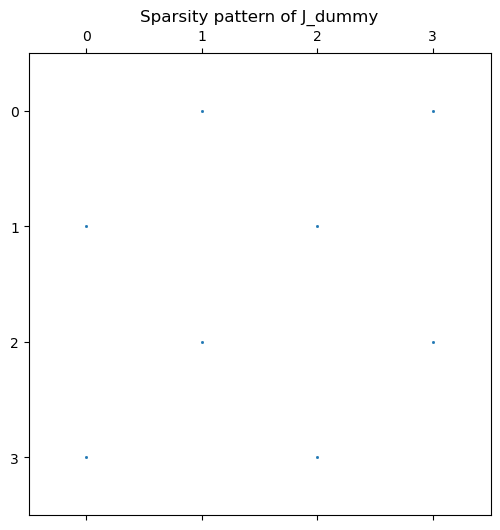

In [5]:
# ============================================================
# Cell 5 : Construct J_dummy
# ============================================================

J_dummy = sp.lil_matrix((N, N), dtype=float)

# ------------------------------------------------------------
# Construct the dummy cycle
# ------------------------------------------------------------

if N_dummy >= 2:

    for idx in range(N_dummy):

        u = dummy_nodes[idx]

        v = dummy_nodes[(idx + 1) % N_dummy]

        J_dummy[u, v] = J_min
        J_dummy[v, u] = J_min

elif N_dummy == 1:

    print(
        "Warning: Only one dummy node exists. "
        "No dummy edges created."
    )

else:

    print(
        "No dummy nodes specified."
    )

J_dummy = J_dummy.tocsr()


# ============================================================
# Diagnostics
# ============================================================

dummy_subgraph = J_dummy[dummy_nodes, :][:, dummy_nodes]

row_sparsities = np.diff(dummy_subgraph.indptr)

weighted_degrees = np.array(
    dummy_subgraph.sum(axis=1)
).flatten()

positive_entries = dummy_subgraph.data


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (J_dummy != J_dummy.T).nnz == 0, \
    "J_dummy is not symmetric."

assert np.allclose(
    J_dummy.diagonal(),
    0
), "J_dummy has non-zero diagonal entries."

# Ensure there are no real-dummy connections
assert J_dummy[real_nodes, :][:, dummy_nodes].nnz == 0, \
    "Real-to-dummy connections found."

assert J_dummy[dummy_nodes, :][:, real_nodes].nnz == 0, \
    "Dummy-to-real connections found."

if N_dummy >= 3:

    assert np.all(
        row_sparsities == 2
    ), "Dummy cycle does not have sparsity 2."

    assert np.allclose(
        weighted_degrees,
        2 * J_min
    ), (
        "Dummy weighted degrees are not equal "
        "to 2*J_min."
    )

if positive_entries.size > 0:

    assert np.allclose(
        positive_entries,
        J_min
    ), "Dummy edge weights are not equal to J_min."


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("J_dummy Construction Summary")
print("=" * 70)

print(f"Number of dummy nodes              : "
      f"{N_dummy}")

print()

print(f"Dummy node indices                 : "
      f"{dummy_nodes}")

print()

print(f"Number of undirected dummy edges   : "
      f"{dummy_subgraph.nnz // 2}")

print(f"Number of non-zero dummy entries   : "
      f"{dummy_subgraph.nnz}")

print()

if N_dummy >= 3:

    print(f"Dummy row sparsity                 : "
          f"{row_sparsities[0]}")

    print(f"Dummy weighted degree              : "
          f"{weighted_degrees[0]:.4f}")

print()

print(f"Dummy edge weight                  : "
      f"{J_min}")

print("=" * 70)

# ============================================================
# First few rows of J_dummy
# ============================================================

n_rows_to_show = min(dummy_subgraph.shape[0], 10)

print("\nFirst few rows of dummy_subgraph in J_dummy:")

for local_i in range(n_rows_to_show):

    global_i = dummy_nodes[local_i]

    row = dummy_subgraph.getrow(local_i)

    print(f"\nGlobal node {global_i}:")

    for local_j, val in zip(row.indices, row.data):

        global_j = dummy_nodes[local_j]

        print(
            f"    J[{global_i},{global_j}] = {val}"
        )


plt.figure(figsize=(6,6))
plt.spy(dummy_subgraph, markersize=1)
plt.title("Sparsity pattern of J_dummy")
plt.show()

Full Adjacency Matrix J Summary
Shape of J                          : (32, 32)

Number of real nodes                : 28
Number of dummy nodes               : 4

Specified s_J                       : 3
Maximum actual row sparsity         : 3

d_min                               : 0.5000
d_max                               : 3.0000

Specified J_min                     : 0.5000
Actual minimum positive J_ij        : 0.5000
Actual maximum positive J_ij        : 1.0000

Number of undirected edges          : 30
Number of non-zero entries          : 60

Number of connected components      : 10
Smallest component size             : 2
Largest component size              : 4

First few rows of J:

Row 0:
    J[0,12] = 1.0
    J[0,21] = 1.0

Row 1:
    J[1,13] = 1.0
    J[1,25] = 0.5

Row 2:
    J[2,4] = 1.0
    J[2,26] = 0.5

Row 3:
    J[3,9] = 0.5
    J[3,20] = 0.5

Row 4:
    J[4,2] = 1.0

Row 5:
    J[5,10] = 0.5
    J[5,24] = 1.0

Row 6:
    J[6,20] = 0.5

Row 7:
    J[7,16] = 0.5

Row 8:
 

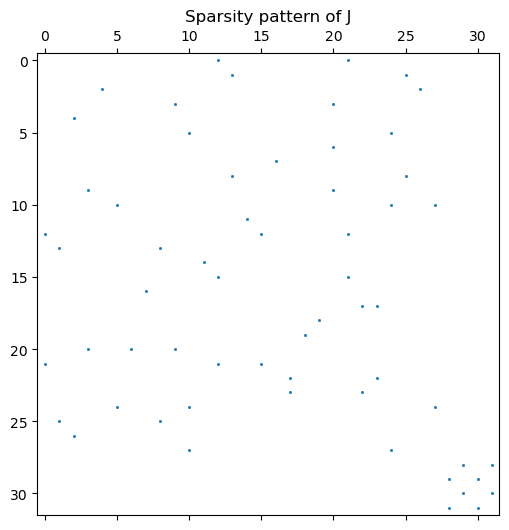

In [6]:
# ============================================================
# Cell 6 : Construct the full adjacency matrix J
# ============================================================

# ------------------------------------------------------------
# Embed J_real into an N x N matrix
# ------------------------------------------------------------

J_real_full = sp.lil_matrix((N, N), dtype=float)

J_real_full[:N_real, :N_real] = J_real

J_real_full = J_real_full.tocsr()

# ------------------------------------------------------------
# Assemble the full J matrix
# ------------------------------------------------------------

J = J_real_full + J_dummy

J = J.tocsr()

# ============================================================
# Diagnostics
# ============================================================

# ------------------------------------------------------------
# Basic structural properties
# ------------------------------------------------------------

assert J.shape == (N, N), \
    "J does not have shape (N, N)."

assert (J != J.T).nnz == 0, \
    "J is not symmetric."

assert np.allclose(
    J.diagonal(),
    0
), "J has non-zero diagonal entries."

# ------------------------------------------------------------
# Verify that real and dummy sectors are disconnected
# ------------------------------------------------------------

assert J[real_nodes, :][:, dummy_nodes].nnz == 0, \
    "Real-to-dummy connections detected."

assert J[dummy_nodes, :][:, real_nodes].nnz == 0, \
    "Dummy-to-real connections detected."

# ------------------------------------------------------------
# Sparsity diagnostics
# ------------------------------------------------------------

row_sparsities = np.diff(J.indptr)

max_row_sparsity = row_sparsities.max()

# ------------------------------------------------------------
# Weighted degree diagnostics
# ------------------------------------------------------------

weighted_degrees = np.array(
    J.sum(axis=1)
).flatten()

d_min = weighted_degrees.min()

d_max = weighted_degrees.max()

assert np.all(
    weighted_degrees > 0
), "Some nodes have zero weighted degree."

assert d_min >= J_min - 1e-12, \
    "d_min is smaller than J_min."

# ------------------------------------------------------------
# Edge-weight diagnostics
# ------------------------------------------------------------

positive_entries = J.data

assert np.all(
    positive_entries >= J_min
), "Some positive entries are smaller than J_min."

assert np.allclose(
    positive_entries / J_min,
    np.round(
        positive_entries / J_min
    )
), "Some edge weights are not multiples of J_min."

J_ij_min_actual = positive_entries.min()

J_ij_max_actual = positive_entries.max()

# ------------------------------------------------------------
# Connected component diagnostics
# ------------------------------------------------------------

n_components, component_labels = sp.csgraph.connected_components(
    J,
    directed=False
)

component_sizes = np.bincount(component_labels)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Full Adjacency Matrix J Summary")
print("=" * 70)

print(f"Shape of J                          : "
      f"{J.shape}")

print()

print(f"Number of real nodes                : "
      f"{N_real}")

print(f"Number of dummy nodes               : "
      f"{N_dummy}")

print()

print(f"Specified s_J                       : "
      f"{s_J}")

print(f"Maximum actual row sparsity         : "
      f"{max_row_sparsity}")

print()

print(f"d_min                               : "
      f"{d_min:.4f}")

print(f"d_max                               : "
      f"{d_max:.4f}")

print()

print(f"Specified J_min                     : "
      f"{J_min:.4f}")

print(f"Actual minimum positive J_ij        : "
      f"{J_ij_min_actual:.4f}")

print(f"Actual maximum positive J_ij        : "
      f"{J_ij_max_actual:.4f}")

print()

print(f"Number of undirected edges          : "
      f"{J.nnz // 2}")

print(f"Number of non-zero entries          : "
      f"{J.nnz}")

print()

print(f"Number of connected components      : "
      f"{n_components}")

print(f"Smallest component size             : "
      f"{component_sizes.min()}")

print(f"Largest component size              : "
      f"{component_sizes.max()}")

print("=" * 70)

# ============================================================
# First few rows of J
# ============================================================

n_rows_to_show = 10

print("\nFirst few rows of J:")

for i in range(n_rows_to_show):

    row = J.getrow(i)

    print(f"\nRow {i}:")

    for j, val in zip(row.indices, row.data):

        print(f"    J[{i},{j}] = {val}")


plt.figure(figsize=(6,6))
plt.spy(J, markersize=1)
plt.title("Sparsity pattern of J")
plt.show()

In [7]:
# ============================================================
# Cell 7 : Construct D, L, and A
# ============================================================

# ------------------------------------------------------------
# Degree vector and degree matrix
# ------------------------------------------------------------

degree_vector = np.array(
    J.sum(axis=1)
).flatten()

D = sp.diags(
    degree_vector,
    offsets=0,
    shape=(N, N),
    format='csr'
)

# ============================================================
# Construct the Laplacian
# ============================================================

if model == 1:

    # --------------------------------------------------------
    # Model 1:
    #
    #     L = D - J
    #
    # --------------------------------------------------------

    L = D - J

elif model == 2:

    # --------------------------------------------------------
    # Model 2:
    #
    #     L = I - D^{-1/2} J D^{-1/2}
    #
    # --------------------------------------------------------

    D_inv_sqrt = sp.diags(
        1 / np.sqrt(degree_vector),
        offsets=0,
        shape=(N, N),
        format='csr'
    )

    L = (
        sp.eye(N, format='csr')
        - D_inv_sqrt @ J @ D_inv_sqrt
    )

else:

    raise ValueError(
        f"Unknown model: {model}"
    )

# ============================================================
# Construct A
# ============================================================

A = (
    (1 - alpha) * sp.eye(N, format='csr')
    + alpha * L
)

A = A.tocsr()

# ============================================================
# Diagnostics
# ============================================================

A_row_sparsities = np.diff(A.indptr)

A_diagonal = A.diagonal()

off_diagonal = A - sp.diags(
    A_diagonal,
    format='csr'
)

positive_off_diagonal_entries = (
    off_diagonal.data[
        off_diagonal.data > 1e-12
    ]
)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (A != A.T).nnz == 0, \
    "A is not symmetric."

assert np.all(
    A_diagonal > 0
), "A does not have positive diagonal entries."

assert len(
    positive_off_diagonal_entries
) == 0, (
    "A has positive off-diagonal entries "
    "and is therefore not a Z-matrix."
)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Matrix Construction Summary")
print("=" * 70)

print(f"Model used                          : "
      f"{model}")

print()

print(f"Diffusion parameter alpha           : "
      f"{alpha:.4f}")

print()

print(f"Minimum degree d_min                : "
      f"{degree_vector.min():.4f}")

print(f"Maximum degree d_max                : "
      f"{degree_vector.max():.4f}")

print()

print(f"Maximum row sparsity of A           : "
      f"{A_row_sparsities.max()}")

print()

print(f"Minimum diagonal entry of A         : "
      f"{A_diagonal.min():.4f}")

print(f"Maximum diagonal entry of A         : "
      f"{A_diagonal.max():.4f}")

print()

print(f"Number of non-zero entries in A     : "
      f"{A.nnz}")

print()

print(f"A is symmetric                      : True")

print(f"A is a Z-matrix                     : True")

print("=" * 70)

Matrix Construction Summary
Model used                          : 2

Diffusion parameter alpha           : 0.5000

Minimum degree d_min                : 0.5000
Maximum degree d_max                : 3.0000

Maximum row sparsity of A           : 4

Minimum diagonal entry of A         : 1.0000
Maximum diagonal entry of A         : 1.0000

Number of non-zero entries in A     : 92

A is symmetric                      : True
A is a Z-matrix                     : True


In [8]:
# ============================================================
# Cell 8 : Spectral Diagnostics for A
# ============================================================

BLOCK_ENCODING_MARGIN = 1e-10

BOUND_VALIDATION_TOL = 1e-12
# (Used only when comparing exact theoretical bounds with numerically computed eigenvalues.)


# ------------------------------------------------------------
# Compute extremal eigenvalues
# ------------------------------------------------------------

print("Computing extremal eigenvalues of A...")

lambda_min = spla.eigsh(
    A,
    k=1,
    which='SA',
    return_eigenvectors=False
)[0]

lambda_max = spla.eigsh(
    A,
    k=1,
    which='LA',
    return_eigenvectors=False
)[0]

# ------------------------------------------------------------
# Exact condition number
# ------------------------------------------------------------

kappa_exact = lambda_max / lambda_min


# ============================================================
# Model-specific theoretical bounds
# ============================================================

if model == 1:

    #
    # A = (1-alpha)I + alpha(D - J)
    #
    # lambda_min >= 1 - alpha
    #
    # lambda_max <= (1-alpha) + 2 alpha d_max
    #

    lambda_min_bound = 1 - alpha

    lambda_max_bound = (
        (1 - alpha)
        + 2 * alpha * d_max
    )

    row_sum_bound = 2*(s - 1)

elif model == 2:

    #
    # A = (1-alpha)I
    #   + alpha(I - D^{-1/2} J D^{-1/2})
    #
    # spectrum(A) subseteq [1-alpha, 1+alpha]
    #

    lambda_min_bound = 1 - alpha

    lambda_max_bound = 1 + alpha

    row_sum_bound = s

else:

    raise ValueError(
        f"Unknown model: {model}"
    )


# ------------------------------------------------------------
# Theoretical condition number bound
# ------------------------------------------------------------

kappa_bound = (
    lambda_max_bound
    / lambda_min_bound
)


# ============================================================
# Positive definiteness diagnostics
# ============================================================

is_positive_definite = (
    lambda_min > 0
)

assert is_positive_definite, \
    (
        "A is not positive definite.\n"
        f"lambda_min = {lambda_min:.12f}"
    )


# ============================================================
# Validate theoretical bounds
# ============================================================

lower_bound_valid = (
    lambda_min >=
    lambda_min_bound - BOUND_VALIDATION_TOL
)

upper_bound_valid = (
    lambda_max <=
    lambda_max_bound + BOUND_VALIDATION_TOL
)

assert lower_bound_valid, \
    (
        "Theoretical lower bound violated.\n"
        f"lambda_min = {lambda_min:.12f}\n"
        f"lambda_min_bound = "
        f"{lambda_min_bound:.12f}"
    )

assert upper_bound_valid, \
    (
        "Theoretical upper bound violated.\n"
        f"lambda_max = {lambda_max:.12f}\n"
        f"lambda_max_bound = "
        f"{lambda_max_bound:.12f}"
    )


# ============================================================
# Block-encoding scaling factor
# ============================================================

# Note that alpha_A must ensure two things.
#
# 1. ||A / alpha_A||_2 <= 1,
#    so that the matrix is block-encodable.
#
# 2. For every row i,
#
#       sum_j |A_ij| / alpha_A <= 1,
#
#    so that the PREPARE amplitudes
#
#       sqrt(|A_ij| / alpha_A)
#
#    form a valid subnormalized state.
#    The remaining probability mass is assigned
#    to the |fail> state.

alpha_A = (
    max(
        lambda_max_bound,
        row_sum_bound
    )
    /
    (1 - BLOCK_ENCODING_MARGIN)
)

# ============================================================
# Encodability diagnostics
# ============================================================

scaled_lambda_min = (
    lambda_min / alpha_A
)

scaled_lambda_max = (
    lambda_max / alpha_A
)

all_eigenvalues_encodable = (
    scaled_lambda_max <= 1
)

assert all_eigenvalues_encodable, \
    (
        "Eigenvalues are not block-encodable.\n"
        f"lambda_max / alpha_A = "
        f"{scaled_lambda_max:.12f}"
    )

assert scaled_lambda_min > 0, \
    (
        "Scaled eigenvalues are not positive.\n"
        f"lambda_min / alpha_A = "
        f"{scaled_lambda_min:.12f}"
    )


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Spectral Diagnostics")
print("=" * 70)

print(f"Exact lambda_min                   : "
      f"{lambda_min:.8f}")

print(f"Exact lambda_max                   : "
      f"{lambda_max:.8f}")

print()

print(f"Exact condition number             : "
      f"{kappa_exact:.8f}")

print()

print(f"Theoretical lambda_min bound       : "
      f"{lambda_min_bound:.8f}")

print(f"Theoretical lambda_max bound       : "
      f"{lambda_max_bound:.8f}")

print()

print(f"Theoretical condition number bound : "
      f"{kappa_bound:.8f}")

print()

print(f"Row-sum bound                      : "
      f"{row_sum_bound:.8f}")

print()

print(f"Block-encoding margin              : "
      f"{BLOCK_ENCODING_MARGIN:.2e}")

print(f"Block-encoding scaling alpha_A     : "
      f"{alpha_A:.8f}")

print()

print(f"lambda_min / alpha_A               : "
      f"{scaled_lambda_min:.8f}")

print(f"lambda_max / alpha_A               : "
      f"{scaled_lambda_max:.8f}")

print(f"alpha_A / lambda_max               : "
      f"{alpha_A / lambda_max:.8f}")

print()

print(f"A is positive definite             : "
      f"{is_positive_definite}")

print(f"Lower bound validated              : "
      f"{lower_bound_valid}")

print(f"Upper bound validated              : "
      f"{upper_bound_valid}")

print(f"All eigenvalues encodable          : "
      f"{all_eigenvalues_encodable}")

print("=" * 70)

Computing extremal eigenvalues of A...

Spectral Diagnostics
Exact lambda_min                   : 0.50000000
Exact lambda_max                   : 1.50000000

Exact condition number             : 3.00000000

Theoretical lambda_min bound       : 0.50000000
Theoretical lambda_max bound       : 1.50000000

Theoretical condition number bound : 3.00000000

Row-sum bound                      : 4.00000000

Block-encoding margin              : 1.00e-10
Block-encoding scaling alpha_A     : 4.00000000

lambda_min / alpha_A               : 0.12500000
lambda_max / alpha_A               : 0.37500000
alpha_A / lambda_max               : 2.66666667

A is positive definite             : True
Lower bound validated              : True
Upper bound validated              : True
All eigenvalues encodable          : True


In [9]:
# ============================================================
# Cell 9 : Construct Sparse Oracle Tables for A
# ============================================================

A_positions = []
A_values = []

# ------------------------------------------------------------
# Extract sparse representation row by row
# ------------------------------------------------------------

for i in range(N):

    row = A.getrow(i)

    positions = row.indices.tolist()
    values = row.data.tolist()

    # --------------------------------------------------------
    # Verify sparsity assumption
    # --------------------------------------------------------

    assert len(positions) <= s, \
        (
            f"Row {i} exceeds sparsity bound.\n"
            f"Observed sparsity = {len(positions)}\n"
            f"Specified sparsity = {s}"
        )

    A_positions.append(positions)
    A_values.append(values)


# ============================================================
# Pad the rows to uniform length s
# ============================================================

#
# O_F expects a mapping
#
#     (i, ell) -> f(i, ell)
#
# where ell ∈ {0, ..., s−1}.
#
# Therefore, every row representation should have
# exactly s entries.
#
# Padding is performed using actual zero locations
# (p, 0) satisfying A[i, p] = 0.
#
# We additionally ensure that the final position list
# is sorted in ascending order.
#

A_positions_padded = []
A_values_padded = []

for i in range(N):

    positions = A_positions[i].copy()
    values = A_values[i].copy()

    # --------------------------------------------------------
    # Sort the genuine entries
    # --------------------------------------------------------

    pairs = sorted(
        zip(positions, values),
        key=lambda x: x[0]
    )

    positions = [p for p, _ in pairs]
    values = [v for _, v in pairs]

    # --------------------------------------------------------
    # Pad using actual zero locations
    # --------------------------------------------------------

    padding_needed = s - len(positions)

    if padding_needed > 0:

        used_positions = set(positions)

        available_positions = [
            j for j in range(N)
            if j not in used_positions
        ]

        padding_positions = (
            available_positions[:padding_needed]
        )

        positions.extend(padding_positions)

        values.extend(
            [0.0] * padding_needed
        )

    # --------------------------------------------------------
    # Final sorting (including padded entries)
    # --------------------------------------------------------

    pairs = sorted(
        zip(positions, values),
        key=lambda x: x[0]
    )

    positions = [p for p, _ in pairs]
    values = [v for _, v in pairs]

    # --------------------------------------------------------
    # Final checks
    # --------------------------------------------------------

    assert len(positions) == s, \
        (
            f"Row {i} does not have exactly "
            f"{s} padded entries."
        )

    assert len(values) == s, \
        (
            f"Row {i} does not have exactly "
            f"{s} padded values."
        )

    A_positions_padded.append(positions)
    A_values_padded.append(values)


# ============================================================
# Convert to NumPy arrays
# ============================================================

A_positions_padded = np.array(
    A_positions_padded,
    dtype=int
)

A_values_padded = np.array(
    A_values_padded,
    dtype=float
)


# ============================================================
# Verify consistency with A
# ============================================================

for i in range(N):

    for ell in range(s):

        j = A_positions_padded[i, ell]

        val = A_values_padded[i, ell]

        actual_val = A[i, j]

        if sp.issparse(actual_val):

            actual_val = actual_val.toarray()[0, 0]

        actual_val = float(actual_val)

        assert np.isclose(
            val,
            actual_val
        ), (
            f"Inconsistent oracle entry.\n"
            f"Row {i}, ell = {ell}\n"
            f"Position = {j}\n"
            f"Stored value = {val}\n"
            f"Actual value = {actual_val}"
        )


# ============================================================
# Diagnostics
# ============================================================

assert A_positions_padded.shape == (N, s)

assert A_values_padded.shape == (N, s)

assert np.all(
    np.diff(A_positions_padded, axis=1) >= 0
), (
    "Some rows are not sorted in ascending order."
)

assert np.all(
    np.sum(
        A_values_padded != 0,
        axis=1
    ) <= s
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Sparse Oracle Tables for A")
print("=" * 70)

print(f"A_positions_padded shape            : "
      f"{A_positions_padded.shape}")

print(f"A_values_padded shape               : "
      f"{A_values_padded.shape}")

print()

print(f"Specified sparsity s                : "
      f"{s}")

print()

print("First few rows:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow {i}:")

    for ell in range(s):

        j = A_positions_padded[i, ell]

        val = A_values_padded[i, ell]

        print(
            f"    ell = {ell}: "
            f"column = {j}, "
            f"value = {val:.6f}"
        )

print("\n" + "=" * 70)

Sparse Oracle Tables for A
A_positions_padded shape            : (32, 4)
A_values_padded shape               : (32, 4)

Specified sparsity s                : 4

First few rows:

Row 0:
    ell = 0: column = 0, value = 1.000000
    ell = 1: column = 1, value = 0.000000
    ell = 2: column = 12, value = -0.223607
    ell = 3: column = 21, value = -0.223607

Row 1:
    ell = 0: column = 0, value = 0.000000
    ell = 1: column = 1, value = 1.000000
    ell = 2: column = 13, value = -0.333333
    ell = 3: column = 25, value = -0.204124

Row 2:
    ell = 0: column = 0, value = 0.000000
    ell = 1: column = 2, value = 1.000000
    ell = 2: column = 4, value = -0.408248
    ell = 3: column = 26, value = -0.288675

Row 3:
    ell = 0: column = 0, value = 0.000000
    ell = 1: column = 3, value = 1.000000
    ell = 2: column = 9, value = -0.250000
    ell = 3: column = 20, value = -0.204124

Row 4:
    ell = 0: column = 0, value = 0.000000
    ell = 1: column = 1, value = 0.000000
    ell = 2: 

In [10]:
# ============================================================
# Cell 10 : Classical Sparse Oracles O_F and O_A
# ============================================================

# ------------------------------------------------------------
# Position oracle:
#
#     O_F(i, ell) = f(i, ell)
#
# Returns the column index corresponding to the
# ell-th accessible entry of row i.
# ------------------------------------------------------------

def O_F(i, ell):

    assert 0 <= i < N, \
        f"Row index i = {i} is out of range."

    assert 0 <= ell < s, \
        f"Sparsity index ell = {ell} is out of range."

    return int(
        A_positions_padded[i, ell]
    )


# ------------------------------------------------------------
# Value oracle:
#
#     O_A(i, ell)
#
# Returns the matrix value
#
#     A_{i, f(i, ell)}.
#
# ------------------------------------------------------------

def O_A(i, ell):

    assert 0 <= i < N, \
        f"Row index i = {i} is out of range."

    assert 0 <= ell < s, \
        f"Sparsity index ell = {ell} is out of range."

    return float(
        A_values_padded[i, ell]
    )


# ============================================================
# Exhaustive verification
# ============================================================

for i in range(N):

    for ell in range(s):

        j = O_F(i, ell)

        oracle_value = O_A(i, ell)

        actual_value = A[i, j]

        if sp.issparse(actual_value):

            actual_value = actual_value.toarray()[0, 0]

        actual_value = float(actual_value)

        assert np.isclose(
            oracle_value,
            actual_value
        ), (
            f"Oracle mismatch.\n"
            f"Row = {i}\n"
            f"ell = {ell}\n"
            f"O_F(i, ell) = {j}\n"
            f"O_A(i, ell) = {oracle_value}\n"
            f"A[i, j] = {actual_value}"
        )


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("Classical Sparse Oracle Verification")
print("=" * 70)

print(
    "Position oracle O_F verified "
    f"for all {N*s} entries."
)

print(
    "Value oracle O_A verified "
    f"for all {N*s} entries."
)

print("\nExample queries:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow {i}:")

    for ell in range(s):

        j = O_F(i, ell)

        val = O_A(i, ell)

        print(
            f"    ell = {ell}: "
            f"f(i, ell) = {j}, "
            f"A[i, f(i, ell)] = {val:.6f}"
        )

print("\n" + "=" * 70)

Classical Sparse Oracle Verification
Position oracle O_F verified for all 128 entries.
Value oracle O_A verified for all 128 entries.

Example queries:

Row 0:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 1.000000
    ell = 1: f(i, ell) = 1, A[i, f(i, ell)] = 0.000000
    ell = 2: f(i, ell) = 12, A[i, f(i, ell)] = -0.223607
    ell = 3: f(i, ell) = 21, A[i, f(i, ell)] = -0.223607

Row 1:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 0.000000
    ell = 1: f(i, ell) = 1, A[i, f(i, ell)] = 1.000000
    ell = 2: f(i, ell) = 13, A[i, f(i, ell)] = -0.333333
    ell = 3: f(i, ell) = 25, A[i, f(i, ell)] = -0.204124

Row 2:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 0.000000
    ell = 1: f(i, ell) = 2, A[i, f(i, ell)] = 1.000000
    ell = 2: f(i, ell) = 4, A[i, f(i, ell)] = -0.408248
    ell = 3: f(i, ell) = 26, A[i, f(i, ell)] = -0.288675

Row 3:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 0.000000
    ell = 1: f(i, ell) = 3, A[i, f(i, ell)] = 1.000000
    ell = 2: f(i, ell) = 9, A[i, f(

In [11]:
# ============================================================
# Cell 11 : Oracle Register Specifications
# ============================================================

# ------------------------------------------------------------
# Upper bound on d_max
# ------------------------------------------------------------

#
# Since
#
#     J_ij <= 1,
#
# and each node has at most s_J neighbors,
#
# we have
#
#     d_max <= s_J.
#
# This bound depends only on the problem
# specification and NOT on the realized graph.
#

d_max_possible = s_J


# ============================================================
# Model-1 precision requirements
# ============================================================

#
# For Model 1:
#
#     |A_ij| = alpha J_ij
#
# Therefore,
#
#     |A_ij|
#
#     >= ALPHA_THRESHOLD J_MIN_THRESHOLD.
#

A_min_possible_model_1 = (
    ALPHA_THRESHOLD
    * J_MIN_THRESHOLD
)

#
# Since
#
#     A_ii
#
#     = 1 - alpha + alpha d_i
#
# and
#
#     d_i <= d_max_possible,
#
# we obtain
#
#     A_ii <= 1 + d_max_possible.
#

A_max_possible_model_1 = (
    1
    + d_max_possible
)


# ============================================================
# Model-2 precision requirements
# ============================================================

#
# For Model 2:
#
#     |A_ij|
#
#     = alpha J_ij
#
#       / sqrt(d_i d_j)
#
# Since
#
#     sqrt(d_i d_j)
#
#     <= d_max_possible,
#
# we obtain
#
#     |A_ij|
#
#     >=
#
#     ALPHA_THRESHOLD
#
#     * J_MIN_THRESHOLD
#
#     / d_max_possible.
#

A_min_possible_model_2 = (
    ALPHA_THRESHOLD
    * J_MIN_THRESHOLD
    / d_max_possible
)

#
# Diagonal entries are exactly 1.
#

A_max_possible_model_2 = 1.0


# ============================================================
# Model-agnostic precision requirements
# ============================================================

#
# We construct ONE oracle architecture that
# works for BOTH models.
#
# Therefore, we first determine the largest
# possible matrix entry magnitude among all
# models under consideration.
#

A_max_possible = max(
    A_max_possible_model_1,
    A_max_possible_model_2
)


#
# Require
#
#     A_max_possible / 2^b
#
# to be strictly smaller than the smallest
# representable nonzero entry in each model.
#

ratio_model_1 = (
    A_max_possible
    / A_min_possible_model_1
)

ratio_model_2 = (
    A_max_possible
    / A_min_possible_model_2
)


#
# Add one extra bit to guarantee the strict
# inequality.
#

VALUE_PRECISION_BITS_MODEL_1 = int(
    np.ceil(
        np.log2(ratio_model_1)
    )
) + 1

VALUE_PRECISION_BITS_MODEL_2 = int(
    np.ceil(
        np.log2(ratio_model_2)
    )
) + 1


#
# Model-agnostic value precision.
#

VALUE_PRECISION_BITS = max(
    VALUE_PRECISION_BITS_MODEL_1,
    VALUE_PRECISION_BITS_MODEL_2
)


VALUE_RESOLUTION = (
    A_max_possible
    /
    (2 ** VALUE_PRECISION_BITS)
)


# ------------------------------------------------------------
# Verify that the chosen precision is sufficient
# ------------------------------------------------------------

assert VALUE_RESOLUTION < A_min_possible_model_1, \
    (
        "Value register precision is insufficient "
        "for Model 1.\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}\n"
        f"A_min_possible_model_1 = "
        f"{A_min_possible_model_1:.12e}"
    )

assert VALUE_RESOLUTION < A_min_possible_model_2, \
    (
        "Value register precision is insufficient "
        "for Model 2.\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}\n"
        f"A_min_possible_model_2 = "
        f"{A_min_possible_model_2:.12e}"
    )


# ============================================================
# Determine actual realized A diagnostics
# ============================================================

A_nonzero_values = A.data

A_nonzero_magnitudes = np.abs(
    A_nonzero_values[
        np.abs(A_nonzero_values) > 0
    ]
)

A_min_actual = (
    A_nonzero_magnitudes.min()
)

A_max_actual = (
    A_nonzero_magnitudes.max()
)

actual_entries_resolvable = (
    A_min_actual
    > VALUE_RESOLUTION
)

assert actual_entries_resolvable, \
    (
        "The realized matrix A contains "
        "entries below the chosen value "
        "resolution.\n"
        f"A_min_actual = "
        f"{A_min_actual:.12e}\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}"
    )


# ============================================================
# Register sizes
# ============================================================

#
# Index register
#

n_index = n


#
# Sparsity register
#

n_sparsity = int(
    np.ceil(
        np.log2(s)
    )
)


#
# Position register
#

n_position = n


#
# Sign qubit
#

n_sign = 1


#
# Value register
#

n_value = (
    VALUE_PRECISION_BITS
    + n_sign
)


# ============================================================
# Oracle logical qubit counts
# ============================================================

n_qubits_O_F = (
    n_index
    + n_sparsity
    + n_position
)

n_qubits_O_A = (
    n_index
    + n_sparsity
    + n_value
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Oracle Register Specifications")
print("=" * 70)

print(f"ALPHA_THRESHOLD                   : "
      f"{ALPHA_THRESHOLD:.2e}")

print(f"J_MIN_THRESHOLD                   : "
      f"{J_MIN_THRESHOLD:.2e}")

print()

print(f"d_max_possible                    : "
      f"{d_max_possible}")

print()

print(f"Model-1 A_min_possible            : "
      f"{A_min_possible_model_1:.12e}")

print(f"Model-1 A_max_possible            : "
      f"{A_max_possible_model_1:.12e}")

print(f"Model-1 precision bits            : "
      f"{VALUE_PRECISION_BITS_MODEL_1}")

print()

print(f"Model-2 A_min_possible            : "
      f"{A_min_possible_model_2:.12e}")

print(f"Model-2 A_max_possible            : "
      f"{A_max_possible_model_2:.12e}")

print(f"Model-2 precision bits            : "
      f"{VALUE_PRECISION_BITS_MODEL_2}")

print()

print(f"Model-agnostic A_max_possible     : "
      f"{A_max_possible:.12e}")

print(f"Model-agnostic precision bits     : "
      f"{VALUE_PRECISION_BITS}")

print(f"Model-agnostic resolution         : "
      f"{VALUE_RESOLUTION:.12e}")

print()

print(f"Actual A_min                      : "
      f"{A_min_actual:.12e}")

print(f"Actual A_max                      : "
      f"{A_max_actual:.12e}")

print()

print(f"Actual entries resolvable         : "
      f"{actual_entries_resolvable}")

print()

print(f"Index register qubits             : "
      f"{n_index}")

print(f"Sparsity register qubits          : "
      f"{n_sparsity}")

print(f"Position register qubits          : "
      f"{n_position}")

print(f"Value register qubits             : "
      f"{n_value}")

print()

print(f"O_F logical qubits                : "
      f"{n_qubits_O_F}")

print(f"O_A logical qubits                : "
      f"{n_qubits_O_A}")

print()

print("Ancilla qubits required for")
print("QROM implementation are not")
print("included in these counts.")

print("=" * 70)

Oracle Register Specifications
ALPHA_THRESHOLD                   : 1.00e-02
J_MIN_THRESHOLD                   : 1.00e-02

d_max_possible                    : 3

Model-1 A_min_possible            : 1.000000000000e-04
Model-1 A_max_possible            : 4.000000000000e+00
Model-1 precision bits            : 17

Model-2 A_min_possible            : 3.333333333333e-05
Model-2 A_max_possible            : 1.000000000000e+00
Model-2 precision bits            : 18

Model-agnostic A_max_possible     : 4.000000000000e+00
Model-agnostic precision bits     : 18
Model-agnostic resolution         : 1.525878906250e-05

Actual A_min                      : 1.000000000000e-01
Actual A_max                      : 1.000000000000e+00

Actual entries resolvable         : True

Index register qubits             : 5
Sparsity register qubits          : 2
Position register qubits          : 5
Value register qubits             : 19

O_F logical qubits                : 12
O_A logical qubits                : 26

Anc

In [12]:
# ============================================================
# Cell 12 : QROM Data Preparation
# ============================================================

# ------------------------------------------------------------
# Flatten O_F lookup table
# ------------------------------------------------------------

#
# Address convention:
#
#     address = i * s + ell
#
# where
#
#     i   = row index,
#     ell = sparsity index.
#

num_addresses = N * s

O_F_table = np.zeros(
    num_addresses,
    dtype=int
)

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        O_F_table[address] = (
            A_positions_padded[i, ell]
        )


# ------------------------------------------------------------
# Flatten O_A lookup table
# ------------------------------------------------------------

#
# We encode values using
#
#     sign bit
#
# together with a fixed-point magnitude.
#

O_A_sign_table = np.zeros(
    num_addresses,
    dtype=int
)

O_A_magnitude_table = np.zeros(
    num_addresses,
    dtype=int
)

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        value = (
            A_values_padded[i, ell]
        )

        #
        # Sign bit
        #
        #     0 -> positive
        #     1 -> negative
        #

        if value < 0:

            O_A_sign_table[address] = 1

        else:

            O_A_sign_table[address] = 0

        #
        # Fixed-point magnitude
        #

        magnitude = abs(value)

        encoded_magnitude = int(
            np.round(
                magnitude
                / VALUE_RESOLUTION
            )
        )

        O_A_magnitude_table[address] = (
            encoded_magnitude
        )


# ============================================================
# Verify fixed-point encoding
# ============================================================

maximum_encoding_error = 0.0

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        original_value = (
            A_values_padded[i, ell]
        )

        sign = (
            -1
            if O_A_sign_table[address] == 1
            else 1
        )

        decoded_value = (
            sign
            * O_A_magnitude_table[address]
            * VALUE_RESOLUTION
        )

        encoding_error = abs(
            original_value
            - decoded_value
        )

        maximum_encoding_error = max(
            maximum_encoding_error,
            encoding_error
        )

        assert (
            encoding_error
            <= VALUE_RESOLUTION
        ), (
            f"Fixed-point encoding error too large.\n"
            f"Address = {address}\n"
            f"Original value = {original_value}\n"
            f"Decoded value = {decoded_value}\n"
            f"Error = {encoding_error}"
        )


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("QROM Data Preparation")
print("=" * 70)

print(f"Number of addresses               : "
      f"{num_addresses}")

print()

print(f"O_F table size                    : "
      f"{len(O_F_table)}")

print(f"O_A sign table size               : "
      f"{len(O_A_sign_table)}")

print(f"O_A magnitude table size          : "
      f"{len(O_A_magnitude_table)}")

print()

print(f"Maximum encoding error            : "
      f"{maximum_encoding_error:.12e}")

print(f"Value resolution                  : "
      f"{VALUE_RESOLUTION:.12e}")

print()

print("Example entries:")

n_examples = min(10, num_addresses)

for address in range(n_examples):

    i = address // s

    ell = address % s

    print(
        f"\nAddress {address}: "
        f"(i={i}, ell={ell})"
    )

    print(
        f"    Position      : "
        f"{O_F_table[address]}"
    )

    original_value = (
        A_values_padded[i, ell]
    )
    
    sign = (
        -1
        if O_A_sign_table[address] == 1
        else 1
    )
    
    decoded_value = (
        sign
        * O_A_magnitude_table[address]
        * VALUE_RESOLUTION
    )
    
    encoding_error = abs(
        original_value
        - decoded_value
    )
    
    print(
        f"    Original value : "
        f"{original_value:.12f}"
    )
    
    print(
        f"    Sign bit       : "
        f"{O_A_sign_table[address]}"
    )
    
    print(
        f"    Magnitude int  : "
        f"{O_A_magnitude_table[address]}"
    )
    
    print(
        f"    Decoded value  : "
        f"{decoded_value:.12f}"
    )
    
    print(
        f"    Encoding error : "
        f"{encoding_error:.12e}"
    )

print("\n" + "=" * 70)


QROM_VALIDATION_THRESHOLD = (
    maximum_encoding_error
    + VALUE_RESOLUTION
) / 2

all_entries_verified = True

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        original_value = (
            A_values_padded[i, ell]
        )

        sign = (
            -1
            if O_A_sign_table[address] == 1
            else 1
        )

        decoded_value = (
            sign
            * O_A_magnitude_table[address]
            * VALUE_RESOLUTION
        )

        encoding_error = abs(
            original_value
            - decoded_value
        )

        if (
            encoding_error
            > QROM_VALIDATION_THRESHOLD
        ):

            all_entries_verified = False

            print(
                "\nValidation failure:"
            )

            print(
                f"Address = {address}"
            )

            print(
                f"Original value = "
                f"{original_value:.12f}"
            )

            print(
                f"Decoded value = "
                f"{decoded_value:.12f}"
            )

            print(
                f"Encoding error = "
                f"{encoding_error:.12e}"
            )

assert all_entries_verified, \
    (
        "QROM validation failed."
    )

print()

print(
    f"QROM validation threshold         : "
    f"{QROM_VALIDATION_THRESHOLD:.12e}"
)

print(
    f"All entries validated             : "
    f"{all_entries_verified}"
)

QROM Data Preparation
Number of addresses               : 128

O_F table size                    : 128
O_A sign table size               : 128
O_A magnitude table size          : 128

Maximum encoding error            : 7.323942869036e-06
Value resolution                  : 1.525878906250e-05

Example entries:

Address 0: (i=0, ell=0)
    Position      : 0
    Original value : 1.000000000000
    Sign bit       : 0
    Magnitude int  : 65536
    Decoded value  : 1.000000000000
    Encoding error : 0.000000000000e+00

Address 1: (i=0, ell=1)
    Position      : 1
    Original value : 0.000000000000
    Sign bit       : 0
    Magnitude int  : 0
    Decoded value  : 0.000000000000
    Encoding error : 0.000000000000e+00

Address 2: (i=0, ell=2)
    Position      : 12
    Original value : -0.223606797750
    Sign bit       : 1
    Magnitude int  : 14654
    Decoded value  : -0.223602294922
    Encoding error : 4.502828103964e-06

Address 3: (i=0, ell=3)
    Position      : 21
    Original v

In [13]:
# ============================================================
# Cell 13 : Logical Specification of Sparse Oracles
# ============================================================

# ------------------------------------------------------------
# Address register
# ------------------------------------------------------------

#
# Address convention:
#
#     address = i * s + ell
#
# where
#
#     i   = row index,
#     ell = sparsity index.
#

n_addresses = N * s

n_address = int(
    np.ceil(
        np.log2(n_addresses)
    )
)


# ============================================================
# Oracle interfaces
# ============================================================

#
# O_F:
#
#     |address>|0>
#
#         ->
#
#     |address>|position>
#
#
# O_A:
#
#     |address>|0>|0>
#
#         ->
#
#     |address>|sign>|magnitude>
#


# ------------------------------------------------------------
# Classical emulation of O_F
# ------------------------------------------------------------

def O_F_address(address):

    assert (
        0 <= address < n_addresses
    ), "Address out of range."

    return int(
        O_F_table[address]
    )


# ------------------------------------------------------------
# Classical emulation of O_A
# ------------------------------------------------------------

def O_A_address(address):

    assert (
        0 <= address < n_addresses
    ), "Address out of range."

    sign = int(
        O_A_sign_table[address]
    )

    magnitude = int(
        O_A_magnitude_table[address]
    )

    return sign, magnitude


# ------------------------------------------------------------
# Decode O_A output
# ------------------------------------------------------------

def decode_O_A(sign, magnitude):

    decoded_sign = (
        -1
        if sign == 1
        else 1
    )

    return (
        decoded_sign
        * magnitude
        * VALUE_RESOLUTION
    )


# ============================================================
# Verify address mapping
# ============================================================

for address in range(n_addresses):

    #
    # Recover (i, ell)
    #

    i = address // s

    ell = address % s

    #
    # Oracle outputs
    #

    position = O_F_address(address)

    sign, magnitude = (
        O_A_address(address)
    )

    decoded_value = decode_O_A(
        sign,
        magnitude
    )

    #
    # Gold-standard values
    #

    expected_position = (
        A_positions_padded[i, ell]
    )

    expected_value = (
        A[i, expected_position]
    )

    if sp.issparse(expected_value):

        expected_value = (
            expected_value.toarray()[0, 0]
        )

    expected_value = float(
        expected_value
    )

    #
    # Verify position oracle
    #

    assert (
        position
        == expected_position
    ), (
        f"Position mismatch.\n"
        f"Address = {address}\n"
        f"Expected = {expected_position}\n"
        f"Obtained = {position}"
    )

    #
    # Verify value oracle
    #

    assert (
        abs(
            decoded_value
            - expected_value
        )
        <= VALUE_RESOLUTION
    ), (
        f"Value mismatch.\n"
        f"Address = {address}\n"
        f"Expected = {expected_value}\n"
        f"Decoded = {decoded_value}"
    )


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Logical Sparse Oracle Specification")
print("=" * 70)

print(f"Number of addresses               : "
      f"{n_addresses}")

print(f"Address register qubits           : "
      f"{n_address}")

print()

print(f"Position output qubits            : "
      f"{n_position}")

print()

print(f"Sign output qubits                : "
      f"{n_sign}")

print(f"Magnitude output qubits           : "
      f"{VALUE_PRECISION_BITS}")

print(f"Value output qubits               : "
      f"{n_value}")

print()

print("Oracle interfaces:")

print()

print("O_F :")

print(
    f"    |address> |0> "
    f"-> "
    f"|address> |position>"
)

print()

print("O_A :")

print(
    f"    |address> |0> |0> "
    f"-> "
    f"|address> |sign> |magnitude>"
)

print()

print("All logical oracle checks passed.")

print("=" * 70)

Logical Sparse Oracle Specification
Number of addresses               : 128
Address register qubits           : 7

Position output qubits            : 5

Sign output qubits                : 1
Magnitude output qubits           : 18
Value output qubits               : 19

Oracle interfaces:

O_F :
    |address> |0> -> |address> |position>

O_A :
    |address> |0> |0> -> |address> |sign> |magnitude>

All logical oracle checks passed.


In [14]:
# ============================================================
# Cell 14 : PREPARE State Construction
# ============================================================

#
# Register convention used from Cell 16 onward:
#
#     |ancilla>|row>|system>
#
# PREPARE acts on the ancilla and row
# registers according to
#
#     |0>|i>
#
#         -->
#
#     |chi_i>|i>,
#
# where
#
#     |chi_i>
#
#     =
#
#     sum_ell
#
#         sqrt(
#             |A_{i,f(i,ell)}|
#             / alpha_A
#         )
#
#         |ell>
#
#     +
#
#     sqrt(
#         1
#         -
#         sum_ell
#             |A_{i,f(i,ell)}|
#             / alpha_A
#     )
#
#         |fail>.
#
# The system register is unaffected
# by PREPARE.
#

# ------------------------------------------------------------
# PREPARE register specifications
# ------------------------------------------------------------

#
# Need:
#
#     s sparsity states
#
# plus
#
#     1 failure state.
#

PREPARE_DIMENSION = s + 1

n_prepare = int(
    np.ceil(
        np.log2(PREPARE_DIMENSION)
    )
)

FAILURE_INDEX = s


# ============================================================
# Construct PREPARE states
# ============================================================

#
# prepare_states[i,:] stores the amplitudes
# of |chi_i>.
#
# These amplitudes determine the action
#
#     |0>|i> --> |chi_i>|i>,
#
# but do not themselves depend on the
# eventual ordering of registers in the
# quantum circuit.
#

prepare_states = np.zeros(
    (N, PREPARE_DIMENSION)
)

prepare_row_sums = np.zeros(N)

for i in range(N):

    #
    # Populate amplitudes
    #

    for ell in range(s):

        value = abs(
            A_values_padded[i, ell]
        )

        prepare_row_sums[i] += (
            value / alpha_A
        )

        prepare_states[i, ell] = np.sqrt(
            value / alpha_A
        )

    #
    # Failure amplitude
    #

    failure_probability = (
        1.0
        - prepare_row_sums[i]
    )

    assert failure_probability >= 0, (
        f"PREPARE normalization failed "
        f"for row {i}.\n"
        f"Failure probability = "
        f"{failure_probability}"
    )

    prepare_states[
        i,
        FAILURE_INDEX
    ] = np.sqrt(
        failure_probability
    )


# ============================================================
# Verify normalization
# ============================================================

prepare_norms = np.sum(
    prepare_states**2,
    axis=1
)

prepare_states_normalized = np.allclose(
    prepare_norms,
    1.0
)

assert prepare_states_normalized, (
    "Some PREPARE states are not normalized."
)


# ============================================================
# Diagnostics
# ============================================================

minimum_failure_probability = np.min(
    prepare_states[:, FAILURE_INDEX]**2
)

maximum_failure_probability = np.max(
    prepare_states[:, FAILURE_INDEX]**2
)

mean_failure_probability = np.mean(
    prepare_states[:, FAILURE_INDEX]**2
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("PREPARE State Construction (Ancilla-First Convention)")
print("=" * 70)

print(f"PREPARE dimension                : "
      f"{PREPARE_DIMENSION}")

print(f"PREPARE register qubits          : "
      f"{n_prepare}")

print(f"Failure-state index              : "
      f"{FAILURE_INDEX}")

print()

print(f"PREPARE states normalized        : "
      f"{prepare_states_normalized}")

print()

print(f"Minimum fail probability         : "
      f"{minimum_failure_probability:.8f}")

print(f"Mean fail probability            : "
      f"{mean_failure_probability:.8f}")

print(f"Maximum fail probability         : "
      f"{maximum_failure_probability:.8f}")

print()

print("First few PREPARE states |chi_i>:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\n|chi_{i}>:")

    for ell in range(s):

        position = A_positions_padded[i, ell]

        print(
            f"    ell = {ell:2d}, "
            f"position = {position:4d}, "
            f"amplitude = "
            f"{prepare_states[i, ell]:.8f}"
        )

    print(
        f"    fail amplitude = "
        f"{prepare_states[i, FAILURE_INDEX]:.8f}"
    )

print()

print("=" * 70)

PREPARE State Construction (Ancilla-First Convention)
PREPARE dimension                : 5
PREPARE register qubits          : 3
Failure-state index              : 4

PREPARE states normalized        : True

Minimum fail probability         : 0.57576914
Mean fail probability            : 0.62735970
Maximum fail probability         : 0.67783122

First few PREPARE states |chi_i>:

|chi_0>:
    ell =  0, position =    0, amplitude = 0.50000000
    ell =  1, position =    1, amplitude = 0.00000000
    ell =  2, position =   12, amplitude = 0.23643540
    ell =  3, position =   21, amplitude = 0.23643540
    fail amplitude = 0.79887208

|chi_1>:
    ell =  0, position =    0, amplitude = 0.00000000
    ell =  1, position =    1, amplitude = 0.50000000
    ell =  2, position =   13, amplitude = 0.28867513
    ell =  3, position =   25, amplitude = 0.22590050
    fail amplitude = 0.78462452

|chi_2>:
    ell =  0, position =    0, amplitude = 0.00000000
    ell =  1, position =    2, amplitude

In [15]:
# ============================================================
# Cell 15 : SELECT Operator Specification
# ============================================================

#
# Register convention used from Cell 16 onward:
#
#     |ancilla>|row>|system>
#
# where
#
#     |ancilla>
#
# stores
#
#     |ell>
#
# (including the |fail> state),
#
#     |row>
#
# stores
#
#     |i>,
#
# and
#
#     |system>
#
# is the register on which A/alpha_A
# is ultimately block encoded.
#
# SELECT acts according to
#
#     |ell>|i>|psi>
#
#         -->
#
#     |ell>|i>
#
#     X_{i,f(i,ell)}
#
#     |psi>,
#
# where
#
#     f(i,ell)
#
# is obtained from O_F.
#
# The sign information is stored separately
# and will eventually be incorporated into
# SELECT as a controlled ±1 phase factor
# during the sparse block-encoding
# construction.
#

# ============================================================
# Construct SELECT tables
# ============================================================

SELECT_position_table = np.copy(
    A_positions_padded
)

#
# SELECT_sign_table[i, ell]
#
# stores the sign of
#
#     A_{i,f(i,ell)}.
#
# This sign information will later be
# promoted into the quantum implementation
# of SELECT.
#

SELECT_sign_table = np.zeros(
    (N, s),
    dtype=int
)

for i in range(N):

    for ell in range(s):

        value = A_values_padded[i, ell]

        #
        # Sign convention:
        #
        #     0 --> positive
        #     1 --> negative
        #

        SELECT_sign_table[i, ell] = (
            value < 0
        )


# ============================================================
# Verify matrix symmetry
# ============================================================

symmetry_error = np.max(
    np.abs(
        (A - A.T).data
    )
) if (A != A.T).nnz > 0 else 0.0

symmetry_consistent = (
    symmetry_error < 1e-12
)

assert symmetry_consistent, (
    "SELECT requires A to be symmetric.\n"
    f"Maximum symmetry violation = "
    f"{symmetry_error:.12e}"
)


# ============================================================
# Verify SELECT positions
# ============================================================

valid_positions = np.all(
    (
        SELECT_position_table >= 0
    )
    &
    (
        SELECT_position_table < N
    )
)

assert valid_positions, (
    "SELECT contains invalid positions."
)


# ============================================================
# Verify consistency with O_A
# ============================================================

maximum_value_mismatch = 0.0

for i in range(N):

    for ell in range(s):

        j = SELECT_position_table[i, ell]

        oracle_value = (
            A_values_padded[i, ell]
        )

        actual_value = A[i, j]

        mismatch = abs(
            oracle_value
            - actual_value
        )

        maximum_value_mismatch = max(
            maximum_value_mismatch,
            mismatch
        )


value_consistent = (
    maximum_value_mismatch
    <= VALUE_RESOLUTION
)

assert value_consistent, (
    "SELECT and O_A are inconsistent.\n"
    f"Maximum mismatch = "
    f"{maximum_value_mismatch:.12e}"
)


# ============================================================
# Diagnostics
# ============================================================

num_positive_terms = np.sum(
    SELECT_sign_table == 0
)

num_negative_terms = np.sum(
    SELECT_sign_table == 1
)

num_zero_terms = np.sum(
    A_values_padded == 0
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("SELECT Operator Specification")
print("=" * 70)

print(f"System register qubits           : "
      f"{n}")

print(f"Sparsity register qubits         : "
      f"{n_sparsity}")

print()

print(f"Positive entries                 : "
      f"{num_positive_terms}")

print(f"Negative entries                 : "
      f"{num_negative_terms}")

print(f"Zero (padded) entries            : "
      f"{num_zero_terms}")

print()

print(f"Matrix symmetry verified         : "
      f"{symmetry_consistent}")

print(f"Maximum symmetry violation       : "
      f"{symmetry_error:.12e}")

print()

print(f"SELECT positions valid           : "
      f"{valid_positions}")

print()

print(f"SELECT/O_A consistency           : "
      f"{value_consistent}")

print(f"Maximum value mismatch           : "
      f"{maximum_value_mismatch:.12e}")

print()

print("First few SELECT specifications:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow register state |{i}>:")

    for ell in range(s):

        j = SELECT_position_table[
            i,
            ell
        ]

        value = A_values_padded[
            i,
            ell
        ]

        sign_string = (
            "+"
            if value >= 0
            else "-"
        )

        print(
            f"    ell = {ell:2d} : "
            f"f({i},{ell}) = {j:4d}, "
            f"value = {value:+.8f}, "
            f"sign = {sign_string}"
        )

print()

print("=" * 70)

SELECT Operator Specification
System register qubits           : 5
Sparsity register qubits         : 2

Positive entries                 : 68
Negative entries                 : 60
Zero (padded) entries            : 36

Matrix symmetry verified         : True
Maximum symmetry violation       : 0.000000000000e+00

SELECT positions valid           : True

SELECT/O_A consistency           : True
Maximum value mismatch           : 0.000000000000e+00

First few SELECT specifications:

Row register state |0>:
    ell =  0 : f(0,0) =    0, value = +1.00000000, sign = +
    ell =  1 : f(0,1) =    1, value = +0.00000000, sign = +
    ell =  2 : f(0,2) =   12, value = -0.22360680, sign = -
    ell =  3 : f(0,3) =   21, value = -0.22360680, sign = -

Row register state |1>:
    ell =  0 : f(1,0) =    0, value = +0.00000000, sign = +
    ell =  1 : f(1,1) =    1, value = +1.00000000, sign = +
    ell =  2 : f(1,2) =   13, value = -0.33333333, sign = -
    ell =  3 : f(1,3) =   25, value = -0.20412

In [16]:
# ============================================================
# Cell 16 : Verify the Block Encoding
# ============================================================

#
# Register convention:
#
#     |ancilla>|row>|system>
#
# PREPARE acts as
#
#     |0>|i>
#
#         -->
#
#     |chi_i>|i>,
#
# where
#
#     |chi_i>
#
#     =
#
#     sum_ell
#
#         sqrt(
#             |A_{i,f(i,ell)}|
#             / alpha_A
#         )
#
#         |ell>
#
#     + ...
#
#
# SELECT acts as
#
#     |ell>|i>|psi>
#
#         -->
#
#     sign(A_{i,f(i,ell)})
#
#     |ell>|i>
#
#     X_{i,f(i,ell)}
#
#     |psi>.
#
#
# This cell verifies that
#
#     (⟨0| ⊗ I ⊗ I)
#
#         U
#
#     (|0⟩ ⊗ I ⊗ I)
#
#     = A / alpha_A,
#
# where
#
#     U
#
#     = PREPARE† SELECT PREPARE.
#

# ============================================================
# Construct the encoded matrix block
# ============================================================

A_block_encoded = sp.lil_matrix(
    (N, N),
    dtype=float
)

for i in range(N):

    for ell in range(s):

        j = A_positions_padded[i, ell]

        value = A_values_padded[i, ell]

        #
        # Skip padded entries.
        #

        if value == 0:

            continue

        #
        # PREPARE contributes
        #
        #     sqrt(|A_ij| / alpha_A)
        #
        # twice.
        #

        amplitude = np.sqrt(
            abs(value) / alpha_A
        )

        #
        # SELECT contributes the sign.
        #

        sign = np.sign(value)

        contribution = (
            sign
            * amplitude
            * amplitude
        )

        #
        # Add contribution to the
        # encoded block.
        #

        A_block_encoded[
            i,
            j
        ] += contribution


A_block_encoded = (
    A_block_encoded.tocsr()
)


# ============================================================
# Compare against A / alpha_A
# ============================================================

A_scaled = (
    A / alpha_A
).tocsr()

difference = (
    A_block_encoded
    - A_scaled
).tocsr()


# ============================================================
# Diagnostics
# ============================================================

max_abs_error = np.max(
    np.abs(difference.data)
) if difference.nnz > 0 else 0.0


frobenius_error = np.linalg.norm(
    difference.data
)

block_encoding_correct = (
    max_abs_error
    <= VALUE_RESOLUTION
)


assert block_encoding_correct, (
    "Block encoding verification failed.\n"
    f"Maximum error = "
    f"{max_abs_error:.12e}"
)


# ============================================================
# Verify sparsity structure
# ============================================================

pattern_difference = (
    (
        A_block_encoded != 0
    )
    !=
    (
        A_scaled != 0
    )
)

sparsity_consistent = (
    pattern_difference.nnz == 0
)

assert sparsity_consistent, (
    "Block encoding altered the "
    "sparsity pattern."
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Block Encoding Verification")
print("=" * 70)

print("Verified that")

print()

print(
    "(<0| ⊗ I ⊗ I)"
)

print(
    "    PREPARE† SELECT PREPARE"
)

print(
    "(|0> ⊗ I ⊗ I)"
)

print(
    "= A / alpha_A"
)

print()

print(f"alpha_A                           : "
      f"{alpha_A:.12f}")

print()

print(f"Maximum absolute error            : "
      f"{max_abs_error:.12e}")

print(f"Frobenius error                   : "
      f"{frobenius_error:.12e}")

print()

print(f"Block encoding verified           : "
      f"{block_encoding_correct}")

print(f"Sparsity pattern preserved        : "
      f"{sparsity_consistent}")

print()

print(f"Nonzeros in A                     : "
      f"{A.nnz}")

print(f"Nonzeros in encoded block         : "
      f"{A_block_encoded.nnz}")

print()

print("=" * 70)

Block Encoding Verification
Verified that

(<0| ⊗ I ⊗ I)
    PREPARE† SELECT PREPARE
(|0> ⊗ I ⊗ I)
= A / alpha_A

alpha_A                           : 4.000000000400

Maximum absolute error            : 1.387778780781e-17
Frobenius error                   : 5.397192826725e-17

Block encoding verified           : True
Sparsity pattern preserved        : True

Nonzeros in A                     : 92
Nonzeros in encoded block         : 92



In [17]:
# ============================================================
# Cell 17 : Qubitized Walk Operator Specification
# ============================================================

#
# Register convention:
#
#     |ancilla>|row>|system>
#
# where
#
#     |ancilla>
#
# stores the PREPARE state labels
# (including the |fail> state),
#
#     |row>
#
# stores the sparse-row index,
#
# and
#
#     |system>
#
# is the register on which
#
#     A / alpha_A
#
# is block encoded.
#
#
# The block encoding is
#
#     U
#
#     =
#
#     PREPARE†
#
#     SELECT
#
#     PREPARE.
#
#
# The qubitized walk operator is
#
#     W
#
#     =
#
#     R U,
#
# where
#
#     R
#
#     =
#
#     2 |0><0| ⊗ I ⊗ I
#
#     - I.
#
#
# QPE is later applied to W.
#

# ============================================================
# Compute exact eigenvalues of A
# ============================================================

print("Computing exact eigenvalues of A...")

A_dense = A.toarray()

lambda_exact = np.linalg.eigvalsh(
    A_dense
)

lambda_exact = np.sort(
    lambda_exact
)


# ============================================================
# Compute qubitization phases
# ============================================================

#
# Since
#
#     |lambda_k / alpha_A| <= 1,
#
# the qubitization angles satisfy
#
#     theta_k
#
#     =
#
#     arccos(lambda_k / alpha_A).
#

scaled_lambda_exact = (
    lambda_exact
    / alpha_A
)

theta_exact = np.arccos(
    scaled_lambda_exact
)


# ============================================================
# Validate encodability
# ============================================================

encodable_spectrum = np.all(
    np.abs(scaled_lambda_exact)
    <= 1
)

assert encodable_spectrum, \
    (
        "Some eigenvalues are not "
        "block encodable."
    )


# ============================================================
# W-resource accounting
# ============================================================

#
# One application of W consists of
#
#     PREPARE
#
#     SELECT
#
#     PREPARE†
#
#     R.
#

num_prepare_per_W = 1

num_prepare_dagger_per_W = 1

num_select_per_W = 1

num_reflections_per_W = 1


# ============================================================
# Qubit counts
# ============================================================

n_ancilla_W = n_prepare

n_row_W = n

n_system_W = n

n_total_W = (
    n_ancilla_W
    + n_row_W
    + n_system_W
)


# ============================================================
# Logical specification of W
# ============================================================

W_specification = {

    "ancilla_qubits": n_ancilla_W,

    "row_qubits": n_row_W,

    "system_qubits": n_system_W,

    "total_qubits": n_total_W,

    "prepare_calls_per_W":
        num_prepare_per_W,

    "prepare_dagger_calls_per_W":
        num_prepare_dagger_per_W,

    "select_calls_per_W":
        num_select_per_W,

    "reflection_calls_per_W":
        num_reflections_per_W,

    "supports_controlled_W":
        True,

    "supports_W_powers":
        True,
}


# ============================================================
# Additional W specification
# ============================================================

W_specification[
    "phase_qubits_defined"
] = False


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Qubitized Walk Operator Specification")
print("=" * 70)

print("Walk operator:")

print()

print(
    "    W = R PREPARE† SELECT PREPARE"
)

print()

print("Reflection operator:")

print()

print(
    "    R = 2|0><0| ⊗ I ⊗ I - I"
)

print()

print(f"Ancilla qubits                  : "
      f"{n_ancilla_W}")

print(f"Row qubits                       : "
      f"{n_row_W}")

print(f"System qubits                    : "
      f"{n_system_W}")

print(f"Total W qubits                   : "
      f"{n_total_W}")

print()

print("Per application of W:")

print()

print(f"PREPARE calls                    : "
      f"{num_prepare_per_W}")

print(f"PREPARE† calls                   : "
      f"{num_prepare_dagger_per_W}")

print(f"SELECT calls                     : "
      f"{num_select_per_W}")

print(f"Reflection calls                 : "
      f"{num_reflections_per_W}")

print()

print(f"Spectrum encodable               : "
      f"{encodable_spectrum}")

print(f"QPE precision specified          : "
      f"{W_specification['phase_qubits_defined']}")

print()


# ------------------------------------------------------------
# Smallest eigenvalues
# ------------------------------------------------------------

print("Smallest eigenvalues and phases:")

n_to_show = min(
    5,
    len(lambda_exact)
)

for k in range(n_to_show):

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Largest eigenvalues
# ------------------------------------------------------------

print("Largest eigenvalues and phases:")

for k in range(
    len(lambda_exact) - n_to_show,
    len(lambda_exact)
):

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Random sample of eigenvalues
# ------------------------------------------------------------

NUM_RANDOM_EIGENVALUES_TO_SHOW = min(
    20,
    len(lambda_exact)
)

rng = np.random.default_rng(
    SEED
)

sample_indices = np.sort(
    rng.choice(
        len(lambda_exact),
        size=NUM_RANDOM_EIGENVALUES_TO_SHOW,
        replace=False
    )
)

print("Random sample of eigenvalues and phases:")

for k in sample_indices:

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Extremal diagnostics
# ------------------------------------------------------------

print("Largest eigenvalue:")

print(
    f"  lambda_max = "
    f"{lambda_exact[-1]:.8f}"
)

print(
    f"  theta_max = "
    f"{theta_exact[-1]:.8f}"
)

print()

print("Smallest eigenvalue:")

print(
    f"  lambda_min = "
    f"{lambda_exact[0]:.8f}"
)

print(
    f"  theta_min = "
    f"{theta_exact[0]:.8f}"
)

print()

print("=" * 70)

Computing exact eigenvalues of A...

Qubitized Walk Operator Specification
Walk operator:

    W = R PREPARE† SELECT PREPARE

Reflection operator:

    R = 2|0><0| ⊗ I ⊗ I - I

Ancilla qubits                  : 3
Row qubits                       : 5
System qubits                    : 5
Total W qubits                   : 13

Per application of W:

PREPARE calls                    : 1
PREPARE† calls                   : 1
SELECT calls                     : 1
Reflection calls                 : 1

Spectrum encodable               : True
QPE precision specified          : False

Smallest eigenvalues and phases:
  k =    0 : lambda =  0.50000000, lambda/alpha_A =  0.12500000, theta =  1.44546850
  k =    1 : lambda =  0.50000000, lambda/alpha_A =  0.12500000, theta =  1.44546850
  k =    2 : lambda =  0.50000000, lambda/alpha_A =  0.12500000, theta =  1.44546850
  k =    3 : lambda =  0.50000000, lambda/alpha_A =  0.12500000, theta =  1.44546850
  k =    4 : lambda =  0.50000000, lambda/alpha

In [18]:
# ============================================================
# Cell 18 : PREPARE Circuit Specification
# ============================================================

#
# PREPARE acts as
#
#     |0>|i>
#
#         -->
#
#     |chi_i>|i>,
#
# where
#
#     |chi_i>
#
# are the normalized states constructed
# in Cell 14.
#
#
# We assume that an exact state-preparation
# routine (e.g. Mottonen-style decomposition)
# will be used internally by a future circuit
# implementation.
#
#
# We do NOT explicitly synthesize the gate
# sequence here.
#
#
# Instead, we:
#
#     1. Store the amplitude vectors
#        prepare_states[i]
#        as QROM payloads.
#
#     2. Estimate the classical and quantum
#        complexities associated with
#        PREPARE and PREPARE†.
#


# ============================================================
# QROM payload specification
# ============================================================

#
# Each row i stores
#
#     prepare_states[i]
#
# consisting of
#
#     PREPARE_DIMENSION = s + 1
#
# amplitudes.
#

QROM_prepare_payloads = np.copy(
    prepare_states
)

num_prepare_payloads = (
    QROM_prepare_payloads.shape[0]
)

payload_dimension = (
    QROM_prepare_payloads.shape[1]
)


# ============================================================
# Verify payload normalization
# ============================================================

payload_norms = np.linalg.norm(
    QROM_prepare_payloads,
    axis=1
)

payloads_normalized = np.allclose(
    payload_norms,
    1.0
)

assert payloads_normalized, (
    "Some QROM PREPARE payloads "
    "are not normalized."
)


# ============================================================
# State-preparation specifications
# ============================================================

#
# PREPARE register size.
#

prepare_register_qubits = (
    n_prepare
)


#
# Number of nonzero amplitudes.
#

maximum_nonzero_amplitudes = np.max(
    np.sum(
        np.abs(QROM_prepare_payloads) > 0,
        axis=1
    )
)


#
# Dimension of prepared states.
#

prepare_state_dimension = (
    PREPARE_DIMENSION
)


# ============================================================
# Complexity estimates
# ============================================================

#
# Classical preprocessing:
#
# Constructing the PREPARE payloads
# requires O(N s) work.
#

prepare_classical_preprocessing_complexity = (
    "O(N s)"
)


#
# QROM lookup:
#
# Access one of N payloads using
# log2(N) address qubits.
#

prepare_QROM_complexity = (
    "O(log N)"
)


#
# Mottonen state preparation:
#
# Exact preparation of a state of
# dimension s+1 costs O(s).
#

prepare_state_preparation_complexity = (
    "O(s)"
)


#
# Total PREPARE complexity.
#

prepare_total_complexity = (
    "O(s + log N)"
)


#
# PREPARE† complexity.
#

prepare_dagger_complexity = (
    "O(s + log N)"
)


# ============================================================
# Update W specification
# ============================================================

W_specification[
    "prepare_implementation"
] = (
    "QROM + Mottonen-style exact "
    "state preparation"
)

W_specification[
    "prepare_complexity"
] = (
    prepare_total_complexity
)

W_specification[
    "prepare_dagger_complexity"
] = (
    prepare_dagger_complexity
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("PREPARE Circuit Specification")
print("=" * 70)

print(f"PREPARE register qubits          : "
      f"{prepare_register_qubits}")

print(f"PREPARE state dimension          : "
      f"{prepare_state_dimension}")

print()

print(f"Number of QROM payloads          : "
      f"{num_prepare_payloads}")

print(f"Payload dimension                : "
      f"{payload_dimension}")

print()

print(f"Payloads normalized              : "
      f"{payloads_normalized}")

print()

print(f"Maximum nonzero amplitudes       : "
      f"{maximum_nonzero_amplitudes}")

print()

print("Complexity estimates:")

print()

print(f"Classical preprocessing          : "
      f"{prepare_classical_preprocessing_complexity}")

print(f"QROM lookup                      : "
      f"{prepare_QROM_complexity}")

print(f"Mottonen preparation             : "
      f"{prepare_state_preparation_complexity}")

print(f"PREPARE complexity               : "
      f"{prepare_total_complexity}")

print(f"PREPARE† complexity              : "
      f"{prepare_dagger_complexity}")

print()

print("First few PREPARE payloads:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow {i}:")

    for k in range(
        PREPARE_DIMENSION
    ):

        if k < s:

            label = (
                f"ell = {k}"
            )

        elif k == FAILURE_INDEX:

            label = "fail"

        else:

            label = f"state {k}"

        print(
            f"    {label:8s} : "
            f"{QROM_prepare_payloads[i, k]:.8f}"
        )

print()

print("Implementation note:")

print(
    "Future circuit implementations "
    "may use built-in exact "
    "state-preparation routines "
    "(e.g. Mottonen-style methods) "
    "acting on these QROM payloads."
)

print()

print("=" * 70)

PREPARE Circuit Specification
PREPARE register qubits          : 3
PREPARE state dimension          : 5

Number of QROM payloads          : 32
Payload dimension                : 5

Payloads normalized              : True

Maximum nonzero amplitudes       : 5

Complexity estimates:

Classical preprocessing          : O(N s)
QROM lookup                      : O(log N)
Mottonen preparation             : O(s)
PREPARE complexity               : O(s + log N)
PREPARE† complexity              : O(s + log N)

First few PREPARE payloads:

Row 0:
    ell = 0  : 0.50000000
    ell = 1  : 0.00000000
    ell = 2  : 0.23643540
    ell = 3  : 0.23643540
    fail     : 0.79887208

Row 1:
    ell = 0  : 0.00000000
    ell = 1  : 0.50000000
    ell = 2  : 0.28867513
    ell = 3  : 0.22590050
    fail     : 0.78462452

Row 2:
    ell = 0  : 0.00000000
    ell = 1  : 0.50000000
    ell = 2  : 0.31947155
    ell = 3  : 0.26864248
    fail     : 0.75879453

Row 3:
    ell = 0  : 0.00000000
    ell = 1  : 0.5

In [19]:
# ============================================================
# Cell 19 : Qubitization Phase Validation
# ============================================================

#
# The qubitization theorem implies that
# each eigenvalue
#
#     lambda_k
#
# of A induces a two-dimensional invariant
# subspace of W on which W acts as
#
#         [  lambda_k / alpha_A
#            -sqrt(1-lambda_k^2/alpha_A^2) ]
#
#     W_k =
#
#         [  sqrt(1-lambda_k^2/alpha_A^2)
#             lambda_k / alpha_A          ]
#
# whose eigenvalues are
#
#     exp(± i theta_k),
#
# where
#
#     theta_k
#
#     = arccos(lambda_k / alpha_A).
#
# This cell validates that relationship.
#


# ============================================================
# Construct the 2 x 2 invariant blocks
# ============================================================

W_block_eigenvalue_errors = []

W_blocks_valid = True

for k in range(len(lambda_exact)):

    scaled_lambda = (
        scaled_lambda_exact[k]
    )

    theta = (
        theta_exact[k]
    )

    #
    # Construct the corresponding
    # 2 x 2 walk block.
    #

    W_k = np.array(
        [
            [
                scaled_lambda,
                -np.sqrt(
                    1.0
                    - scaled_lambda**2
                )
            ],

            [
                np.sqrt(
                    1.0
                    - scaled_lambda**2
                ),
                scaled_lambda
            ]
        ]
    )

    #
    # Compute eigenvalues.
    #

    W_k_eigenvalues = np.linalg.eigvals(
        W_k
    )

    #
    # Expected eigenvalues.
    #

    expected_eigenvalues = np.array(
        [
            np.exp(1j * theta),
            np.exp(-1j * theta)
        ]
    )

    #
    # Sort by phase.
    #

    W_k_eigenvalues = W_k_eigenvalues[
        np.argsort(
            np.angle(
                W_k_eigenvalues
            )
        )
    ]

    expected_eigenvalues = expected_eigenvalues[
        np.argsort(
            np.angle(
                expected_eigenvalues
            )
        )
    ]

    #
    # Compute maximum mismatch.
    #

    error = np.max(
        np.abs(
            W_k_eigenvalues
            - expected_eigenvalues
        )
    )

    W_block_eigenvalue_errors.append(
        error
    )

    if error > 1e-12:

        W_blocks_valid = False


# ============================================================
# Diagnostics
# ============================================================

W_block_eigenvalue_errors = np.array(
    W_block_eigenvalue_errors
)

maximum_W_block_error = np.max(
    W_block_eigenvalue_errors
)

mean_W_block_error = np.mean(
    W_block_eigenvalue_errors
)

median_W_block_error = np.median(
    W_block_eigenvalue_errors
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Qubitization Phase Validation")
print("=" * 70)

print(
    "Verified that each eigenvalue "
    "of A induces the expected "
    "qubitization phases."
)

print()

print(f"Number of eigenvalues validated  : "
      f"{len(lambda_exact)}")

print()

print(f"All W blocks validated           : "
      f"{W_blocks_valid}")

print()

print(f"Maximum eigenvalue error         : "
      f"{maximum_W_block_error:.12e}")

print(f"Mean eigenvalue error            : "
      f"{mean_W_block_error:.12e}")

print(f"Median eigenvalue error          : "
      f"{median_W_block_error:.12e}")

print()


# ------------------------------------------------------------
# Random examples
# ------------------------------------------------------------

NUM_EXAMPLES = min(
    10,
    len(lambda_exact)
)

rng = np.random.default_rng(
    SEED
)

example_indices = np.sort(
    rng.choice(
        len(lambda_exact),
        size=NUM_EXAMPLES,
        replace=False
    )
)

print("Random examples:")

for k in example_indices:

    scaled_lambda = (
        scaled_lambda_exact[k]
    )

    theta = (
        theta_exact[k]
    )

    print()

    print(
        f"Eigenpair index {k}:"
    )

    print(
        f"    lambda_k              : "
        f"{lambda_exact[k]:.8f}"
    )

    print(
        f"    lambda_k / alpha_A    : "
        f"{scaled_lambda:.8f}"
    )

    print(
        f"    theta_k               : "
        f"{theta:.8f}"
    )

    print(
        f"    exp(+i theta_k)       : "
        f"{np.exp(1j * theta)}"
    )

    print(
        f"    exp(-i theta_k)       : "
        f"{np.exp(-1j * theta)}"
    )

    print(
        f"    validation error      : "
        f"{W_block_eigenvalue_errors[k]:.12e}"
    )

print()

print(
    "This validates the phase "
    "relationship expected by "
    "qubitization prior to QPE."
)

print()

print("=" * 70)


# ============================================================
# Final assertion
# ============================================================

assert W_blocks_valid, (
    "The qubitization phase "
    "relationship failed."
)

Qubitization Phase Validation
Verified that each eigenvalue of A induces the expected qubitization phases.

Number of eigenvalues validated  : 32

All W blocks validated           : True

Maximum eigenvalue error         : 2.482534153247e-16
Mean eigenvalue error            : 1.039686312726e-16
Median eigenvalue error          : 1.185718710067e-16

Random examples:

Eigenpair index 2:
    lambda_k              : 0.50000000
    lambda_k / alpha_A    : 0.12500000
    theta_k               : 1.44546850
    exp(+i theta_k)       : (0.1249999999874999+0.9921567416507964j)
    exp(-i theta_k)       : (0.1249999999874999-0.9921567416507964j)
    validation error      : 1.185718710067e-16

Eigenpair index 3:
    lambda_k              : 0.50000000
    lambda_k / alpha_A    : 0.12500000
    theta_k               : 1.44546850
    exp(+i theta_k)       : (0.1249999999874999+0.9921567416507964j)
    exp(-i theta_k)       : (0.1249999999874999-0.9921567416507964j)
    validation error      : 1.18571

In [20]:
# ============================================================
# Cell 20 : HHL Parameter Specification
# ============================================================

#
# QPE is performed on the qubitized walk
# operator W.
#
# Its eigenvalues are
#
#     exp(± i theta_j),
#
# where
#
#     theta_j
#
#     =
#
#     arccos(lambda_j / alpha_A).
#
#
#
# QPE estimates signed phases
#
#     phi_j
#
# in
#
#     [-1/2, 1/2),
#
# using the signed fixed-point convention
#
#     phi
#
#     = -s/2
#
#       + b1/4
#
#       + b2/8
#
#       + ...
#
# where s denotes the sign bit.
#
# The walk angle satisfies
#
#     theta_j
#
#     = 2 pi |phi_j|.
#

# ============================================================
# Spectral bounds
# ============================================================

LAMBDA_BOUND_LOWER = (
    lambda_min_bound
)

LAMBDA_BOUND_UPPER = (
    lambda_max_bound
)

assert (
    LAMBDA_BOUND_LOWER > 0
), (
    "HHL requires positive definiteness."
)


# ============================================================
# HHL success parameter
# ============================================================

#
# Choose a conservative margin so that
#
#     C_HHL / lambda_j < 1
#
# throughout the spectrum.
#

C_HHL_MARGIN = 0.10

C_HHL = (
    (1.0 - C_HHL_MARGIN)
    * LAMBDA_BOUND_LOWER
)


# ============================================================
# Condition number bounds
# ============================================================

KAPPA_BOUND = (
    LAMBDA_BOUND_UPPER
    /
    LAMBDA_BOUND_LOWER
)

KAPPA_HHL = (
    2 ** int(
        np.ceil(
            np.log2(
                KAPPA_BOUND
            )
        )
    )
)

#KAPPA_HHL = KAPPA_BOUND


# ============================================================
# Walk-angle bounds
# ============================================================

THETA_BOUND_LOWER = (
    np.arccos(
        LAMBDA_BOUND_UPPER
        /
        alpha_A
    )
)

THETA_BOUND_UPPER = (
    np.arccos(
        LAMBDA_BOUND_LOWER
        /
        alpha_A
    )
)


# ============================================================
# Signed phase bounds
# ============================================================

PHASE_POSITIVE_LOWER = (
    THETA_BOUND_LOWER
    /
    (2 * np.pi)
)

PHASE_POSITIVE_UPPER = (
    THETA_BOUND_UPPER
    /
    (2 * np.pi)
)

PHASE_NEGATIVE_LOWER = (
    -PHASE_POSITIVE_UPPER
)

PHASE_NEGATIVE_UPPER = (
    -PHASE_POSITIVE_LOWER
)


# ============================================================
# Required theta precision
# ============================================================

#
# Since
#
#     lambda
#
#     = alpha_A cos(theta),
#
# and
#
#     Delta(1/lambda)
#
#     <=
#
#     alpha_A Delta(theta)
#
#     / lambda_min^2,
#
# requiring
#
#     Delta(1/lambda)
#
#     << 1/lambda_max
#
# yields
#
#     Delta(theta)
#
#     <<
#
#     lambda_min
#
#     / (alpha_A kappa).
#

THETA_ERROR_TARGET = (
    LAMBDA_BOUND_LOWER
    /
    (
        2 * alpha_A * KAPPA_HHL
    )
)


# ============================================================
# Required phase precision
# ============================================================

#
# theta = 2 pi |phi|
#

PHASE_ERROR_TARGET = (
    THETA_ERROR_TARGET
    /
    (2 * np.pi)
)


# ============================================================
# QPE precision specification
# ============================================================
#
# Choose the largest power of ten
# not exceeding the required phase
# precision.
#

EPSILON_QPE_PHASE = (
    10.0 ** (
        np.floor(
            np.log10(
                PHASE_ERROR_TARGET
            )
        )
    )
)

#
# This precision guarantees that the
# estimated phase supplied to the
# subsequent Chebyshev approximation
#
#     omega = p(phi)
#
# is sufficiently accurate for the
# desired HHL solution accuracy.
#

QPE_SAFETY_FACTOR = (
    PHASE_ERROR_TARGET
    /
    EPSILON_QPE_PHASE
)

m_HHL = int(
    np.ceil(
        np.log2(
            1.0
            /
            EPSILON_QPE_PHASE
        )
    )
)


# ============================================================
# Achieved resolutions
# ============================================================

QPE_PHASE_RESOLUTION = (
    1.0
    /
    (2 ** m_HHL)
)

QPE_THETA_RESOLUTION = (
    2
    * np.pi
    * QPE_PHASE_RESOLUTION
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("HHL Parameter Specification")
print("=" * 70)

print(f"Lambda lower bound               : "
      f"{LAMBDA_BOUND_LOWER:.12f}")

print(f"Lambda upper bound               : "
      f"{LAMBDA_BOUND_UPPER:.12f}")

print()

print(f"C_HHL margin                     : "
      f"{C_HHL_MARGIN:.4f}")

print(f"C_HHL                            : "
      f"{C_HHL:.12f}")

print()

print(f"Condition number bound           : "
      f"{KAPPA_BOUND:.8f}")

print(f"Power-of-two condition bound     : "
      f"{KAPPA_HHL}")

print(f"Alpha_A                          : "
      f"{alpha_A:.12f}")


print()

print(f"Theta lower bound                : "
      f"{THETA_BOUND_LOWER:.12f}")

print(f"Theta upper bound                : "
      f"{THETA_BOUND_UPPER:.12f}")

print()

print(f"Negative phase lower bound       : "
      f"{PHASE_NEGATIVE_LOWER:.12f}")

print(f"Negative phase upper bound       : "
      f"{PHASE_NEGATIVE_UPPER:.12f}")

print()

print(f"Positive phase lower bound       : "
      f"{PHASE_POSITIVE_LOWER:.12f}")

print(f"Positive phase upper bound       : "
      f"{PHASE_POSITIVE_UPPER:.12f}")

print()

print(f"Theta error target               : "
      f"{THETA_ERROR_TARGET:.12e}")

print(f"Phase error target               : "
      f"{PHASE_ERROR_TARGET:.12e}")

print()

print(f"Chosen epsilon_QPE_phase         : "
      f"{EPSILON_QPE_PHASE:.12e}")

print(f"QPE safety factor                : "
      f"{QPE_SAFETY_FACTOR:.3f}")

print()

print(f"QPE precision qubits             : "
      f"{m_HHL}")

print()

print(f"QPE phase resolution             : "
      f"{QPE_PHASE_RESOLUTION:.12e}")

print(f"QPE theta resolution             : "
      f"{QPE_THETA_RESOLUTION:.12e}")

print()

print("=" * 70)

HHL Parameter Specification
Lambda lower bound               : 0.500000000000
Lambda upper bound               : 1.500000000000

C_HHL margin                     : 0.1000
C_HHL                            : 0.450000000000

Condition number bound           : 3.00000000
Power-of-two condition bound     : 4
Alpha_A                          : 4.000000000400

Theta lower bound                : 1.186399552340
Theta upper bound                : 1.445468495639

Negative phase lower bound       : -0.230053456165
Negative phase upper bound       : -0.188821353237

Positive phase lower bound       : 0.188821353237
Positive phase upper bound       : 0.230053456165

Theta error target               : 1.562499999844e-02
Phase error target               : 2.486795985562e-03

Chosen epsilon_QPE_phase         : 1.000000000000e-03
QPE safety factor                : 2.487

QPE precision qubits             : 10

QPE phase resolution             : 9.765625000000e-04
QPE theta resolution             : 6.1359

In [24]:
# ============================================================
# Cell 21 : Chebyshev Approximation Architecture
# ============================================================

#
# We approximate the HHL rotation angle
#
#     omega(phi)
#
#     =
#
#     arcsin(
#         C_HHL
#         /
#         (
#             alpha_A
#             cos(2*pi*phi)
#         )
#     )
#
# where phi is the signed QPE phase:
#
#     phi in (-1/2, 1/2].
#
#
#
# IMPORTANT:
#
# The signed QPE phase is represented in
#
#     [-1/2, 1/2),
#
# using the signed fixed-point convention.
#
# Since
#
#     cos(-x) = cos(x),
#
# the target function is even.
#
# Therefore the Chebyshev approximation is
# constructed directly on the symmetric
# interval
#
#     [-phi_cheb_max, +phi_cheb_max],
#
# without introducing a separate |phi|
# register or taking absolute values.
#
# The resulting polynomial will later be
# converted directly into a controlled-
# rotation circuit, eliminating the need
# for a polynomial output register.
#

from numpy.polynomial.chebyshev import Chebyshev


# ============================================================
# Approximation error target
# ============================================================

#
# Earlier analysis established
#
#     Delta(1/lambda)
#
#         <=
#
#     epsilon_cheb / C_HHL.
#
#
# For the financial models considered
# here,
#
#     EPSILON_CHEB = 1e-2
#
# guarantees the required approximation
# accuracy for all values of alpha up to
# approximately 0.88.
#
# For
#
#     alpha in (0.88, 0.90],
#
# a slightly tighter choice
#
#     EPSILON_CHEB = 9e-3
#
# guarantees
#
#     Delta(1/lambda) < 1e-1.
#

#EPSILON_CHEB = 9e-3
EPSILON_CHEB = 1e-2


# ============================================================
# Approximation interval
# ============================================================

phi_min = PHASE_POSITIVE_LOWER

phi_max = PHASE_POSITIVE_UPPER


#
# Largest phase for which
#
#     omega(phi)
#
# remains well-defined.
#

PHASE_ADMISSIBLE_MAX = (
    np.arccos(
        C_HHL / alpha_A
    )
    /
    (2 * np.pi)
)


#
# Smooth interval expansion.
#
# Lower endpoint:
#
#     halfway between 0 and phi_min.
#
# Upper endpoint:
#
#     halfway between phi_max
#     and PHASE_ADMISSIBLE_MAX.
#

phi_cheb_min = (
    phi_min / 2
)

phi_cheb_max = (
    phi_max
    + PHASE_ADMISSIBLE_MAX
) / 2


assert (
    phi_max
    < phi_cheb_max
    < PHASE_ADMISSIBLE_MAX
), (
    "Invalid Chebyshev interval."
)


#
# Approximation interval.
#

cheb_domain = (
    -phi_cheb_max,
    +phi_cheb_max
)


# ============================================================
# Target function
# ============================================================

def hhl_rotation_function(phi):

    return np.arcsin(
        C_HHL
        /
        (
            alpha_A
            *
            np.cos(
                2 * np.pi * phi
            )
        )
    )


# ============================================================
# Sample target function
# ============================================================

sample_points = np.linspace(
    cheb_domain[0],
    cheb_domain[1],
    5000
)

target_values = hhl_rotation_function(
    sample_points
)


# ============================================================
# Diagnostics
# ============================================================

arcsin_argument = (
    C_HHL
    /
    (
        alpha_A
        *
        np.cos(
            2 * np.pi * sample_points
        )
    )
)

print("\n" + "=" * 70)
print("Chebyshev Diagnostics")
print("=" * 70)

print(f"phi_min                         : "
      f"{phi_min:.12f}")

print(f"phi_max                         : "
      f"{phi_max:.12f}")

print()

print(f"PHASE_ADMISSIBLE_MAX            : "
      f"{PHASE_ADMISSIBLE_MAX:.12f}")

print()

print(f"phi_cheb_min                    : "
      f"{phi_cheb_min:.12f}")

print(f"phi_cheb_max                    : "
      f"{phi_cheb_max:.12f}")

print()

print(f"alpha_A                         : "
      f"{alpha_A:.12f}")

print(f"C_HHL                           : "
      f"{C_HHL:.12f}")

print()

print(f"Minimum arcsin argument         : "
      f"{np.min(arcsin_argument):.12f}")

print(f"Maximum arcsin argument         : "
      f"{np.max(arcsin_argument):.12f}")

print()

print(f"Minimum rotation angle          : "
      f"{np.min(target_values):.12f}")

print(f"Maximum rotation angle          : "
      f"{np.max(target_values):.12f}")

print()

print("=" * 70)


# ============================================================
# Sanity checks
# ============================================================

assert np.all(
    np.isfinite(
        target_values
    )
), (
    "Target function contains "
    "NaN or Inf values."
)

assert (
    np.max(
        np.abs(
            arcsin_argument
        )
    )
    < 1
), (
    "arcsin argument exceeds 1."
)


# ============================================================
# Degree search
# ============================================================

MAX_CHEB_DEGREE = 100

chebyshev_degree = None

achieved_cheb_error = None

for degree in range(
    2,
    MAX_CHEB_DEGREE + 1,
    2
):

    poly = Chebyshev.fit(
        sample_points,
        target_values,
        degree,
        domain=cheb_domain
    )

    approx_values = poly(
        sample_points
    )

    error = np.max(
        np.abs(
            approx_values
            - target_values
        )
    )

    if error <= EPSILON_CHEB:

        chebyshev_degree = degree

        achieved_cheb_error = error

        break


"""
print("\nDegree search diagnostics:")

for degree in [2,4,8,16,32,64,96,100]:

    poly = Chebyshev.fit(
        sample_points,
        target_values,
        degree,
        domain=cheb_domain
    )

    error = np.max(
        np.abs(
            poly(sample_points)
            - target_values
        )
    )

    print(
        f"Degree {degree:3d}: "
        f"{error:.6e}"
    )
"""

if chebyshev_degree is None:

    chebyshev_degree = MAX_CHEB_DEGREE

    achieved_cheb_error = error

    print(
        "\nWarning:"
    )

    print(
        "Target EPSILON_CHEB not reached."
    )

    print(
        f"Best achieved error = "
        f"{achieved_cheb_error:.6e}"
    )


# ============================================================
# Rotation angle diagnostics
# ============================================================

rotation_angle_max = np.max(
    target_values
)

rotation_angle_min = np.min(
    target_values
)

omega_min_theory = np.arcsin(
    C_HHL / lambda_max
)

omega_max_theory = np.arcsin(
    C_HHL / lambda_min
)

assert (
    rotation_angle_min
    <=
    omega_min_theory
)

assert (
    rotation_angle_max
    >=
    omega_max_theory
)

rotation_angle_range = (
    rotation_angle_max
    - rotation_angle_min
)

# ============================================================
# Universal coefficient bound
# ============================================================

#
# Every Boolean Fourier coefficient c_S used
# in the angle-encoding implementation satisfies
#
#     |c_S|
#
# <=
#
#     sup |omega(phi)|.
#
# Since
#
#     alpha_A >= 2
#
# for our graph models,
#
#     sup |omega(phi)|
#
# <=
#
#     arcsin(1/2)
#
#     = pi/6.
#
# Therefore every controlled R_y gate angle is
# guaranteed to lie comfortably inside the
# physical interval (-pi, pi].
#

UNIVERSAL_COEFFICIENT_BOUND = np.arcsin(0.5)

# ============================================================
# Specification dictionary
# ============================================================

CHEBYSHEV_SPEC = {

    "epsilon_cheb":
        EPSILON_CHEB,

    "degree":
        chebyshev_degree,

    "domain":
        cheb_domain,

    "architecture":
        "angle_encoding",

    "output":
        "controlled_rotations",
    
    "universal_coefficient_bound":
        UNIVERSAL_COEFFICIENT_BOUND

}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Chebyshev Approximation Architecture")
print("=" * 70)

print("Target rotation function:")

print()

print(
    "omega(phi) = "
    "arcsin("
    "C_HHL / "
    "(alpha_A cos(2*pi*phi))"
    ")"
)

print()

print(f"Signed phase interval            : "
      f"[{-0.5:.1f}, {0.5:.1f})")

print()

print(f"Phase lower bound                : "
      f"{phi_min:.8f}")

print(f"Phase upper bound                : "
      f"{phi_max:.8f}")

print()

print(f"Chebyshev interval lower         : "
      f"{cheb_domain[0]:.8f}")

print(f"Chebyshev interval upper         : "
      f"{cheb_domain[1]:.8f}")

print()

print(f"Target approximation error       : "
      f"{EPSILON_CHEB:.2e}")

print(f"Achieved approximation error     : "
      f"{achieved_cheb_error:.6e}")

print(f"Target achieved                  : "
      f"{achieved_cheb_error <= EPSILON_CHEB}")

print()

print(f"Chebyshev degree                 : "
      f"{chebyshev_degree}")

print()

print(f"Approximation architecture       : "
      f"Angle Encoding")

print(f"Output representation            : "
      f"Controlled R_y rotations")

print()

print(
    f"Universal coefficient bound      : "
    f"{UNIVERSAL_COEFFICIENT_BOUND:.12f} rad"
)

print()

print(f"Minimum rotation angle           : "
      f"{rotation_angle_min:.8f}")

print(f"Maximum rotation angle           : "
      f"{rotation_angle_max:.8f}")

print(f"Minimum rotation angle (THEORY)  : "
      f"{omega_min_theory:.8f}")

print(f"Maximum rotation angle (THEORY)  : "
      f"{omega_max_theory:.8f}")

print()

print("=" * 70)


Chebyshev Diagnostics
phi_min                         : 0.188821353237
phi_max                         : 0.230053456165

PHASE_ADMISSIBLE_MAX            : 0.232057083954

phi_cheb_min                    : 0.094410676618
phi_cheb_max                    : 0.231055270059

alpha_A                         : 4.000000000400
C_HHL                           : 0.450000000000

Minimum arcsin argument         : 0.112500004733
Maximum arcsin argument         : 0.947349652909

Minimum rotation angle          : 0.112738671245
Maximum rotation angle          : 1.244854750846


Chebyshev Approximation Architecture
Target rotation function:

omega(phi) = arcsin(C_HHL / (alpha_A cos(2*pi*phi)))

Signed phase interval            : [-0.5, 0.5)

Phase lower bound                : 0.18882135
Phase upper bound                : 0.23005346

Chebyshev interval lower         : -0.23105527
Chebyshev interval upper         : 0.23105527

Target approximation error       : 1.00e-02
Achieved approximation error     :

In [26]:
# ============================================================
# Cell 22 : Full HHL Register Architecture
# ============================================================

#
# Goal:
#
#     Solve
#
#         A x = b
#
# using
#
#     Qubitization
#         +
#     QPE
#         +
#     Chebyshev-based
#     angle encoding.
#
#
# Register convention:
#
#     |index>
#
#         Temporary register used by
#         sparse shock-state preparation.
#
#         The register is disentangled
#         after U_b but remains physically
#         allocated throughout the circuit.
#
#
#     |prepare>
#
#         Ancilla register used by
#         PREPARE / PREPARE†.
#
#
#     |row>
#
#         Row index register for
#         sparse block encoding.
#
#
#     |system>
#
#         Stores |b> and eventually
#         the solution state |x>.
#
#
#     |phase>
#
#         QPE output register.
#
#
#         Represents
#
#             phi in [-1/2, 1/2)
#
#         using signed fixed-point
#         convention.
#
#
#     The Chebyshev approximation
#
#         omega(phi)
#
#         =
#
#         arcsin(
#             C_HHL
#             /
#             (
#                 alpha_A
#                 cos(2*pi*phi)
#             )
#         )
#
#     is implemented directly using
#     multi-controlled R_y rotations.
#
#     No polynomial output register
#     or arithmetic workspace is
#     required.
#
#
#     |rotation>
#
#         Rotation ancilla used
#         for reciprocal encoding.
#


# ============================================================
# Register sizes
# ============================================================

n_index_reg = int(
    np.log2(gamma)
)

n_prepare_reg = n_prepare

n_row_reg = n

n_system_reg = n

n_phase_reg = m_HHL

n_rotation_reg = 1


# ============================================================
# Total qubit count
# ============================================================

TOTAL_HHL_QUBITS = (

    n_index_reg

    + n_prepare_reg

    + n_row_reg

    + n_system_reg

    + n_phase_reg

    + n_rotation_reg

)


# ============================================================
# Logical HHL pipeline
# ============================================================

HHL_PIPELINE = [

    "Apply U_b",

    "QPE on W",

    "Chebyshev rotation synthesis",

    "Controlled rotation",

    "Inverse QPE",

    "Measure rotation ancilla",

    "Recover |x>"
]


# ============================================================
# Physical registers present at end
# ============================================================

PHYSICAL_REGISTERS_AT_END = [

    "index",

    "prepare",

    "row",

    "system",

    "rotation"
]


# ============================================================
# Logical output registers
# ============================================================

LOGICAL_OUTPUT_REGISTERS = [

    "system",

    "rotation"
]


# ============================================================
# Specification dictionary
# ============================================================

HHL_ARCHITECTURE = {

    "index_qubits":
        n_index_reg,

    "prepare_qubits":
        n_prepare_reg,

    "row_qubits":
        n_row_reg,

    "system_qubits":
        n_system_reg,

    "phase_qubits":
        n_phase_reg,

    "rotation_qubits":
        n_rotation_reg,

    "total_qubits":
        TOTAL_HHL_QUBITS,

    "chebyshev_degree":
        chebyshev_degree,

    "epsilon_cheb":
        EPSILON_CHEB,

    "phase_precision":
        EPSILON_QPE_PHASE,

    "implementation":
        "Angle Encoding"

}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Full HHL Register Architecture")
print("=" * 70)

print()

print("Register ordering:")

print()

print(
    "index | prepare | row | system | "
    "phase | rotation"
)

print()

print("Registers:")

print()

print(f"Index register                  : "
      f"{n_index_reg}")

print(f"PREPARE register                : "
      f"{n_prepare_reg}")

print(f"Row register                    : "
      f"{n_row_reg}")

print(f"System register                 : "
      f"{n_system_reg}")

print(f"Phase register                  : "
      f"{n_phase_reg}")

print(f"Rotation ancilla                : "
      f"{n_rotation_reg}")

print()

print(f"Total physical qubits           : "
      f"{TOTAL_HHL_QUBITS}")

print()

print("Chebyshev implementation:")

print()

print("  Direct angle encoding")

print("  (multi-controlled R_y rotations)")

print()

print("Pipeline:")

for k, step in enumerate(
    HHL_PIPELINE,
    start=1
):

    print(
        f"  {k}. {step}"
    )

print()

print("Physical registers at end:")

for register in PHYSICAL_REGISTERS_AT_END:

    print(
        f"  - {register}"
    )

print()

print("Logical output registers:")

for register in LOGICAL_OUTPUT_REGISTERS:

    print(
        f"  - {register}"
    )

print()

print(f"QPE precision qubits            : "
      f"{m_HHL}")

print(f"Chebyshev degree                : "
      f"{chebyshev_degree}")

print(f"Chebyshev error target          : "
      f"{EPSILON_CHEB:.2e}")

print(f"Phase precision target          : "
      f"{EPSILON_QPE_PHASE:.2e}")

print()

print("=" * 70)


Full HHL Register Architecture

Register ordering:

index | prepare | row | system | phase | rotation

Registers:

Index register                  : 3
PREPARE register                : 3
Row register                    : 5
System register                 : 5
Phase register                  : 10
Rotation ancilla                : 1

Total physical qubits           : 27

Chebyshev implementation:

  Direct angle encoding
  (multi-controlled R_y rotations)

Pipeline:
  1. Apply U_b
  2. QPE on W
  3. Chebyshev rotation synthesis
  4. Controlled rotation
  5. Inverse QPE
  6. Measure rotation ancilla
  7. Recover |x>

Physical registers at end:
  - index
  - prepare
  - row
  - system
  - rotation

Logical output registers:
  - system
  - rotation

QPE precision qubits            : 10
Chebyshev degree                : 26
Chebyshev error target          : 1.00e-02
Phase precision target          : 1.00e-03




Shock-State Integration

Raw support size                : 3
Actual support size             : 4
Number of dummies               : 1

Final support:
[1, 3, 21, 28]

|b> = (1/sqrt(4)) sum_(i in S) |i>

Verification:
  Support verified              : True
  Uniform amplitudes verified   : True
  Index disentangled            : True

Resources:
  Circuit depth                 : 30
  Exact MCX count               : 13
  MCX upper bound               : 32

Exported objects:
  STATE_PREP_CIRCUIT
  STATE_PREP_METADATA
  B_STATE_SUPPORT
  B_STATE_RHO
  B_STATE_DELTA



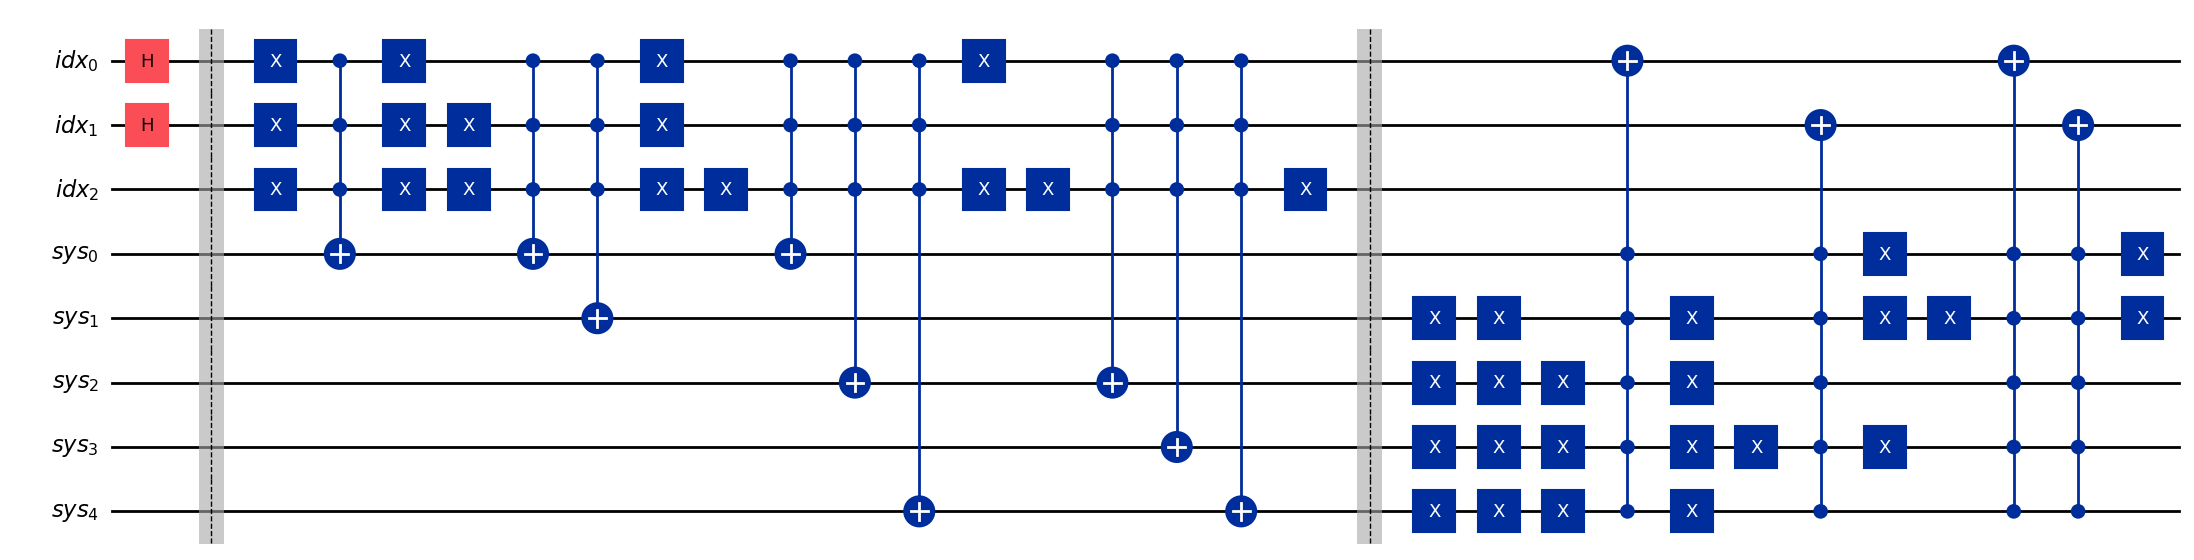

In [27]:
# ============================================================
# Cell 23 : Shock-State Integration
# ============================================================

#
# This cell constructs the sparse
# shock-state preparation circuit
# U_b used as the input stage of
# the HHL pipeline.
#
# Goal:
#
#     |0>^n
#
#         -->
#
#     |b>
#
# where
#
#     |b>
#
# is a sparse uniform superposition over the
# shock support.
#
#
# Future extension:
#
#     Read support from CSV.
#
# Current version:
#
#     Hard-coded support list.
#

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector


# ============================================================
# Shock support specification
# ============================================================

USE_SHOCK_CSV = False

SHOCK_CSV_FILE = "shock_support.csv"

#
# Example shock support.
#
# Replace later by CSV loading.
#

SHOCK_SUPPORT = [
    1,
    3,
    21
]

SHOCK_SUPPORT = sorted(
    SHOCK_SUPPORT
)


# ============================================================
# Basic checks
# ============================================================

rho = len(
    SHOCK_SUPPORT
)

assert rho > 0

assert len(
    set(SHOCK_SUPPORT)
) == rho

assert all(
    x in real_node_set
    for x in SHOCK_SUPPORT
), (
    "Shock support must contain "
    "only real bank nodes."
)


# ============================================================
# Support preprocessing
# ============================================================

delta = int(
    2**np.ceil(
        np.log2(rho)
    )
)

assert delta <= gamma, (
    "Increase gamma.\n"
    f"delta = {delta}, "
    f"gamma = {gamma}"
)

t = int(
    np.log2(delta)
)

INDEX_REGISTER_QUBITS = int(
    np.log2(gamma)
)

assert INDEX_REGISTER_QUBITS == n_index_reg, (
    "n_index_reg does not equal gamma. Please verify definition of n_index_reg in code."
)

#
# Dummy nodes already exist in the
# finance graph construction.
#

available_dummies = (
    dummy_nodes.astype(int)
    .tolist()
)

num_dummies = (
    delta - rho
)

assert (
    num_dummies
    <= len(available_dummies)
), (
    "Not enough dummy nodes "
    "available."
)

dummies = (
    available_dummies[:num_dummies]
)

#
# Final support.
#

S = sorted(
    SHOCK_SUPPORT
    + list(dummies)
)

assert len(S) == delta

assert len(set(S)) == delta


# ============================================================
# Helper functions
# ============================================================

def prepare_controls(
    qc,
    register,
    bitstring
):

    for qubit, bit in enumerate(
        reversed(bitstring)
    ):

        if bit == "0":

            qc.x(
                register[qubit]
            )


def unprepare_controls(
    qc,
    register,
    bitstring
):

    for qubit, bit in enumerate(
        reversed(bitstring)
    ):

        if bit == "0":

            qc.x(
                register[qubit]
            )


# ============================================================
# State-preparation circuit builder
# ============================================================

def build_sparse_shock_preparation_circuit(
    support,
    n,
    gamma
):

    rho_local = len(
        support
    )

    delta_local = int(
        2**np.ceil(
            np.log2(rho_local)
        )
    )

    t_local = int(
        np.log2(delta_local)
    )

    p_local = int(
        np.log2(gamma)
    )

    idx = QuantumRegister(
        p_local,
        name="idx"
    )

    sys = QuantumRegister(
        n,
        name="sys"
    )

    qc = QuantumCircuit(
        idx,
        sys,
        name="U_b"
    )

    # --------------------------------------------------------
    # Stage 1
    # --------------------------------------------------------

    for q in range(t_local):

        qc.h(
            idx[q]
        )

    qc.barrier()

    # --------------------------------------------------------
    # Stage 2
    # --------------------------------------------------------

    for j, i_j in enumerate(
        support
    ):

        j_bits = format(
            j,
            f"0{p_local}b"
        )

        i_bits = format(
            i_j,
            f"0{n}b"
        )

        prepare_controls(
            qc,
            idx,
            j_bits
        )

        for sys_qubit, bit in enumerate(
            reversed(i_bits)
        ):

            if bit == "1":

                qc.mcx(
                    list(idx),
                    sys[sys_qubit]
                )

        unprepare_controls(
            qc,
            idx,
            j_bits
        )

    qc.barrier()

    # --------------------------------------------------------
    # Stage 3
    # --------------------------------------------------------

    for j, i_j in enumerate(
        support
    ):

        j_bits = format(
            j,
            f"0{p_local}b"
        )

        i_bits = format(
            i_j,
            f"0{n}b"
        )

        prepare_controls(
            qc,
            sys,
            i_bits
        )

        for idx_qubit, bit in enumerate(
            reversed(j_bits)
        ):

            if bit == "1":

                qc.mcx(
                    list(sys),
                    idx[idx_qubit]
                )

        unprepare_controls(
            qc,
            sys,
            i_bits
        )

    return qc


# ============================================================
# Build shock-state circuit
# ============================================================

STATE_PREP_CIRCUIT = (
    build_sparse_shock_preparation_circuit(
        S,
        n,
        gamma
    )
)


# ============================================================
# Verification
# ============================================================

sv = Statevector.from_instruction(
    STATE_PREP_CIRCUIT
)

state_dict = sv.to_dict()

expected_index = (
    "0" * INDEX_REGISTER_QUBITS
)

expected_amplitude = (
    1 / np.sqrt(delta)
)

observed_support = set()

nonzero_count = 0

for basis_state, amplitude in (
    state_dict.items()
):

    if abs(amplitude) < 1e-10:

        continue

    nonzero_count += 1

    system_bits = (
        basis_state[:-INDEX_REGISTER_QUBITS]
    )

    index_bits = (
        basis_state[-INDEX_REGISTER_QUBITS:]
    )

    system_index = int(
        system_bits,
        2
    )

    observed_support.add(
        system_index
    )

    assert (
        index_bits
        == expected_index
    )

    assert (
        system_index
        in S
    )

    assert np.isclose(
        abs(amplitude),
        expected_amplitude,
        atol=1e-10
    )

assert (
    nonzero_count
    == delta
)

assert (
    observed_support
    == set(S)
)


# ============================================================
# Resource summary
# ============================================================

gate_counts = (
    STATE_PREP_CIRCUIT.count_ops()
)

mcx_count = gate_counts.get(
    "mcx",
    0
)

#
# Exact MCX count implied by the
# circuit construction.
#

exact_mcx_count = (

    sum(
        bin(i).count("1")
        for i in S
    )

    +

    sum(
        bin(j).count("1")
        for j in range(delta)
    )
)

assert (
    exact_mcx_count
    == mcx_count
)

#
# Theoretical upper bound.
#

mcx_upper_bound = (
    delta * n
    +
    delta * INDEX_REGISTER_QUBITS
)


# ============================================================
# Metadata
# ============================================================

STATE_PREP_METADATA = {

    "rho":
        rho,

    "delta":
        delta,

    "gamma":
        gamma,

    "num_dummies":
        num_dummies,

    "support":
        S,

    "depth":
        STATE_PREP_CIRCUIT.depth(),

    "mcx_count":
        mcx_count,

    "mcx_upper_bound":
        mcx_upper_bound
}

B_STATE_SUPPORT = S

B_STATE_RHO = rho

B_STATE_DELTA = delta


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Shock-State Integration")
print("=" * 70)

print()

print(f"Raw support size                : "
      f"{rho}")

print(f"Actual support size             : "
      f"{delta}")

print(f"Number of dummies               : "
      f"{num_dummies}")

print()

print("Final support:")

print(S)

print()

print(
    f"|b> = "
    f"(1/sqrt({delta})) "
    f"sum_(i in S) |i>"
)

print()

print("Verification:")

print(
    f"  Support verified              : True"
)

print(
    f"  Uniform amplitudes verified   : True"
)

print(
    f"  Index disentangled            : True"
)

print()

print("Resources:")

print(
    f"  Circuit depth                 : "
    f"{STATE_PREP_CIRCUIT.depth()}"
)

print(
    f"  Exact MCX count               : "
    f"{mcx_count}"
)

print(
    f"  MCX upper bound               : "
    f"{mcx_upper_bound}"
)

print()

print(
    "Exported objects:"
)

print(
    "  STATE_PREP_CIRCUIT"
)

print(
    "  STATE_PREP_METADATA"
)

print(
    "  B_STATE_SUPPORT"
)

print(
    "  B_STATE_RHO"
)

print(
    "  B_STATE_DELTA"
)

print()

print("=" * 70)

#
# Optional visualization.
#

display(
    STATE_PREP_CIRCUIT.draw(
        "mpl",
        fold=-1
    )
)

In [28]:
# ============================================================
# Cell 24 : State-Preparation Abstraction Layer
# ============================================================

#
# This cell packages the verified sparse
# shock-state preparation circuit into
# the reusable HHL primitive U_b.
#
#
# Logical action:
#
#     U_b :
#
#         |0>_idx |0>_sys
#
#             -->
#
#         |0>_idx |b>_sys
#
#
# The index register is disentangled at
# the output but remains physically
# allocated throughout the HHL circuit.
#
#
#
# Cell 23 established correctness.
#
# This cell simply converts the circuit
# into reusable gate objects for the
# remainder of the HHL pipeline.
#

from qiskit.circuit import Gate


# ============================================================
# Remove barriers for gate conversion
# ============================================================

#
# Keep the original circuit untouched.
#

STATE_PREP_CIRCUIT_NO_BARRIERS = (
    STATE_PREP_CIRCUIT.copy()
)

STATE_PREP_CIRCUIT_NO_BARRIERS.data = [

    instruction

    for instruction
    in STATE_PREP_CIRCUIT_NO_BARRIERS.data

    if instruction.operation.name
    != "barrier"
]


# ============================================================
# Create reusable gates
# ============================================================

UB_GATE = (
    STATE_PREP_CIRCUIT_NO_BARRIERS
    .to_gate(
        label="U_b"
    )
)

UB_DAGGER_GATE = (
    UB_GATE.inverse()
)


# ============================================================
# Register requirements
# ============================================================

UB_INDEX_QUBITS = (
    INDEX_REGISTER_QUBITS
)

UB_SYSTEM_QUBITS = (
    n
)

UB_TOTAL_QUBITS = (

    UB_INDEX_QUBITS

    +

    UB_SYSTEM_QUBITS
)


# ============================================================
# Resource accounting
# ============================================================

#
# Resource counts are taken from the
# original circuit (including barriers
# in depth accounting exactly as built).
#

UB_DEPTH = (
    STATE_PREP_CIRCUIT.depth()
)

UB_GATE_COUNTS = (
    STATE_PREP_CIRCUIT.count_ops()
)

UB_MCX_COUNT = (
    UB_GATE_COUNTS.get(
        "mcx",
        0
    )
)

UB_H_COUNT = (
    UB_GATE_COUNTS.get(
        "h",
        0
    )
)

UB_X_COUNT = (
    UB_GATE_COUNTS.get(
        "x",
        0
    )
)


# ============================================================
# Consistency checks
# ============================================================

assert (
    UB_TOTAL_QUBITS
    ==
    STATE_PREP_CIRCUIT.num_qubits
), (
    "U_b qubit count mismatch."
)

assert (
    B_STATE_DELTA
    <= gamma
)

assert (
    len(B_STATE_SUPPORT)
    == B_STATE_DELTA
)


# ============================================================
# Specification dictionary
# ============================================================

UB_SPECIFICATION = {

    "index_qubits":
        UB_INDEX_QUBITS,

    "system_qubits":
        UB_SYSTEM_QUBITS,

    "total_qubits":
        UB_TOTAL_QUBITS,

    "support_size":
        B_STATE_RHO,

    "padded_support_size":
        B_STATE_DELTA,

    "support":
        B_STATE_SUPPORT,

    "depth":
        UB_DEPTH,

    "mcx_count":
        UB_MCX_COUNT,

    "h_count":
        UB_H_COUNT,

    "x_count":
        UB_X_COUNT,

    "implements_inverse":
        True,

    "output_state":
        "|b>"
}


# ============================================================
# Export objects
# ============================================================

STATE_PREPARATION_SPEC = (
    UB_SPECIFICATION
)

#
# Main exported primitives:
#
#     UB_GATE
#     UB_DAGGER_GATE
#     STATE_PREPARATION_SPEC
#


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("State-Preparation Abstraction Layer")
print("=" * 70)

print()

print("Logical action:")

print()

print(
    "|0>_idx |0>_sys"
)

print(
    "    -->"
)

print(
    "|0>_idx |b>_sys"
)

print()

print("Register requirements:")

print()

print(
    f"Index qubits                   : "
    f"{UB_INDEX_QUBITS}"
)

print(
    f"System qubits                  : "
    f"{UB_SYSTEM_QUBITS}"
)

print(
    f"Total qubits                   : "
    f"{UB_TOTAL_QUBITS}"
)

print()

print("Shock-state information:")

print()

print(
    f"Raw support size               : "
    f"{B_STATE_RHO}"
)

print(
    f"Padded support size            : "
    f"{B_STATE_DELTA}"
)

print()

print("Resources:")

print()

print(
    f"Circuit depth                  : "
    f"{UB_DEPTH}"
)

print(
    f"Hadamards                      : "
    f"{UB_H_COUNT}"
)

print(
    f"X gates                        : "
    f"{UB_X_COUNT}"
)

print(
    f"MCX gates                      : "
    f"{UB_MCX_COUNT}"
)

print()

print(
    "Inverse available              : True"
)

print()

print("Exported objects:")

print(
    "  UB_GATE"
)

print(
    "  UB_DAGGER_GATE"
)

print(
    "  STATE_PREPARATION_SPEC"
)

print()

print("=" * 70)


State-Preparation Abstraction Layer

Logical action:

|0>_idx |0>_sys
    -->
|0>_idx |b>_sys

Register requirements:

Index qubits                   : 3
System qubits                  : 5
Total qubits                   : 8

Shock-state information:

Raw support size               : 3
Padded support size            : 4

Resources:

Circuit depth                  : 30
Hadamards                      : 2
X gates                        : 38
MCX gates                      : 13

Inverse available              : True

Exported objects:
  UB_GATE
  UB_DAGGER_GATE
  STATE_PREPARATION_SPEC



In [31]:
# ============================================================
# Cell 25 : QPE Specification for Qubitization-HHL
# ============================================================

#
# Goal:
#
#     Define the Quantum Phase Estimation
#     architecture used by qubitization-based HHL.
#
#
# QPE is applied to:
#
#     W
#
# whose eigenvalues are
#
#     exp(+i theta_j)
#
# and
#
#     exp(-i theta_j)
#
# with
#
#     cos(theta_j)
#
#         =
#
#     lambda_j / alpha_A.
#
#
# QPE estimates:
#
#     phi_j
#
#         =
#
#     theta_j / (2*pi)
#
#
# where
#
#     phi_j in [-1/2, 1/2).
#
#
# The phase register therefore stores
# a signed fixed-point approximation
# to phi_j.
#

# ============================================================
# Signed phase convention
# ============================================================

QPE_PHASE_INTERVAL = (
    -0.5,
    +0.5
)

#
# Positive spectral phases
# already computed in Cell 20.
#

QPE_POSITIVE_PHASE_LOWER = (
    PHASE_POSITIVE_LOWER
)

QPE_POSITIVE_PHASE_UPPER = (
    PHASE_POSITIVE_UPPER
)

QPE_NEGATIVE_PHASE_LOWER = (
    -PHASE_POSITIVE_UPPER
)

QPE_NEGATIVE_PHASE_UPPER = (
    -PHASE_POSITIVE_LOWER
)


# ============================================================
# QPE precision
# ============================================================

QPE_PHASE_PRECISION = (
    EPSILON_QPE_PHASE
)

QPE_PHASE_QUBITS = (
    m_HHL
)


# ============================================================
# Powers of W required by QPE
# ============================================================

QPE_POWER_LIST = [

    2**k

    for k in range(
        QPE_PHASE_QUBITS
    )
]


# ============================================================
# Total W applications
# ============================================================

#
# QPE applies
#
#     W^(2^0)
#     W^(2^1)
#     ...
#     W^(2^(m-1))
#
# where m = m_HHL
# 
# Therefore:
#
#     total W calls
#
#         =
#
#     1 + 2 + ... + 2^(m-1)
#
#         =
#
#     2^m - 1
#

TOTAL_W_CALLS_QPE = (

    2**QPE_PHASE_QUBITS

    - 1
)


# ============================================================
# Oracle accounting
# ============================================================

#
# One W invocation uses:
#
#     PREPARE
#     SELECT
#     PREPARE†
#     R
#
# Therefore:
#
#     PREPARE calls
#         = 2 per W
#
#     SELECT calls
#         = 1 per W
#
#     R calls
#         = 1 per W
#

TOTAL_PREPARE_CALLS_QPE = (

    2
    *
    TOTAL_W_CALLS_QPE
)

TOTAL_SELECT_CALLS_QPE = (

    TOTAL_W_CALLS_QPE
)

TOTAL_REFLECTION_CALLS_QPE = (

    TOTAL_W_CALLS_QPE
)


# ============================================================
# Complexity model
# ============================================================

#
# Under the sparse-oracle assumptions:
#
#     Cost(PREPARE)
#         = polylog(N)
#
#     Cost(SELECT)
#         = polylog(N)
#
#     Cost(R)
#         = polylog(N)
#
# Therefore:
#
#     Cost(W)
#         = polylog(N)
#
# and
#
#     Cost(QPE)
#
#         =
#
#     (2^m - 1)
#     polylog(N)
#

QPE_COMPLEXITY_MODEL = {

    "cost_W":
        "polylog(N)",

    "cost_QPE":
    (
        "(2^m_HHL - 1) * polylog(N) "
        "= O((1/EPSILON_QPE_PHASE) * polylog(N)) "
        "= O(kappa^2 * polylog(N)) "
        "\n              [for the phase-precision rule used in this notebook]"
    )
}


# ============================================================
# Specification dictionary
# ============================================================

QPE_SPECIFICATION = {

    "phase_interval":
        QPE_PHASE_INTERVAL,

    "positive_phase_lower":
        QPE_POSITIVE_PHASE_LOWER,

    "positive_phase_upper":
        QPE_POSITIVE_PHASE_UPPER,

    "negative_phase_lower":
        QPE_NEGATIVE_PHASE_LOWER,

    "negative_phase_upper":
        QPE_NEGATIVE_PHASE_UPPER,

    "phase_precision":
        QPE_PHASE_PRECISION,

    "phase_qubits":
        QPE_PHASE_QUBITS,

    "powers":
        QPE_POWER_LIST,

    "total_W_calls":
        TOTAL_W_CALLS_QPE,

    "total_prepare_calls":
        TOTAL_PREPARE_CALLS_QPE,

    "total_select_calls":
        TOTAL_SELECT_CALLS_QPE,

    "total_reflection_calls":
        TOTAL_REFLECTION_CALLS_QPE
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("QPE Specification for Qubitization-HHL")
print("=" * 70)

print()

print("Phase convention:")

print()

print(
    f"phi = ± theta / (2*pi), "
    f"(sign encoded by two's-complement interpretation)"
)

print()

print(
    f"Signed phase interval           : "
    f"[{QPE_PHASE_INTERVAL[0]}, "
    f"{QPE_PHASE_INTERVAL[1]})"
)

print()

print(
    f"Positive phase lower bound      : "
    f"{QPE_POSITIVE_PHASE_LOWER:.12f}"
)

print(
    f"Positive phase upper bound      : "
    f"{QPE_POSITIVE_PHASE_UPPER:.12f}"
)

print()

print(
    f"Negative phase lower bound      : "
    f"{QPE_NEGATIVE_PHASE_LOWER:.12f}"
)

print(
    f"Negative phase upper bound      : "
    f"{QPE_NEGATIVE_PHASE_UPPER:.12f}"
)

print()

print(
    f"Phase precision target          : "
    f"{QPE_PHASE_PRECISION:.2e}"
)

print()

print(
    f"Phase register qubits           : "
    f"{QPE_PHASE_QUBITS}"
)

print()

print(
    f"Total W calls                   : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"Total PREPARE calls             : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"Total SELECT calls              : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print(
    f"Total reflection calls          : "
    f"{TOTAL_REFLECTION_CALLS_QPE}"
)

print()

print(
    "Complexity model:"
)

print(
    f"  Cost(W)   = "
    f"{QPE_COMPLEXITY_MODEL['cost_W']}"
)

print(
    f"  Cost(QPE) = "
    f"{QPE_COMPLEXITY_MODEL['cost_QPE']}"
)

print()

print("Exported objects:")

print(
    "  QPE_POWER_LIST"
)

print(
    "  QPE_SPECIFICATION"
)

print(
    "  TOTAL_W_CALLS_QPE"
)

print()

print("=" * 70)


QPE Specification for Qubitization-HHL

Phase convention:

phi = ± theta / (2*pi), (sign encoded by two's-complement interpretation)

Signed phase interval           : [-0.5, 0.5)

Positive phase lower bound      : 0.188821353237
Positive phase upper bound      : 0.230053456165

Negative phase lower bound      : -0.230053456165
Negative phase upper bound      : -0.188821353237

Phase precision target          : 1.00e-03

Phase register qubits           : 10

Total W calls                   : 1023
Total PREPARE calls             : 2046
Total SELECT calls              : 1023
Total reflection calls          : 1023

Complexity model:
  Cost(W)   = polylog(N)
  Cost(QPE) = (2^m_HHL - 1) * polylog(N) = O((1/EPSILON_QPE_PHASE) * polylog(N)) = O(kappa^2 * polylog(N)) 
              [for the phase-precision rule used in this notebook]

Exported objects:
  QPE_POWER_LIST
  QPE_SPECIFICATION
  TOTAL_W_CALLS_QPE



In [32]:
# ============================================================
# Cell 26 : QPE Circuit Architecture
# ============================================================

from qiskit import QuantumCircuit


# ============================================================
# Controlled-W specification
# ============================================================

#
# These are logical placeholders.
#
# The executable implementation
# repeatedly invokes the qubitized
# walk operator W through the
# PREPARE–SELECT–PREPARE†
# construction.
#

CONTROLLED_W_POWERS = [

    {
        "power": power,
        "label": f"CW^{power}"
    }

    for power in QPE_POWER_LIST
]


# ============================================================
# QPE architecture
# ============================================================

#
# The phase register stores a signed
# fixed-point approximation to
#
#     phi ∈ [-1/2, 1/2),
#
# using the two's-complement
# interpretation established in
# Cell 20.
#

QPE_ARCHITECTURE = {

    "phase_register":
        "phase",

    "target_registers": [
        "prepare",
        "row",
        "system"
    ],

    "steps": [

        "Hadamards on phase register",

        "Controlled-W powers",

        "Inverse QFT"
    ],

    "controlled_powers":
        CONTROLLED_W_POWERS
}


# ============================================================
# IQPE architecture
# ============================================================

IQPE_ARCHITECTURE = {

    "steps": [

        "QFT",

        "Inverse controlled-W powers",

        "Hadamards on phase register"
    ]
}


# ============================================================
# Resource accounting
# ============================================================

QPE_RESOURCE_SUMMARY = {

    "phase_qubits":
        m_HHL,

    "controlled_W_blocks":
        len(QPE_POWER_LIST),

    "total_W_calls":
        TOTAL_W_CALLS_QPE,

    "total_prepare_calls":
        TOTAL_PREPARE_CALLS_QPE,

    "total_select_calls":
        TOTAL_SELECT_CALLS_QPE
}


# ============================================================
# Debug helper
# ============================================================

def show_top_amplitudes(
    statevector,
    k=10
):

    amplitudes = []

    for index, amp in enumerate(
        statevector
    ):

        if abs(amp) > 1e-12:

            amplitudes.append(
                (abs(amp), index, amp)
            )

    amplitudes.sort(
        reverse=True
    )

    print(
        f"\nTop {k} amplitudes:\n"
    )

    for magnitude, index, amp in amplitudes[:k]:

        print(
            f"{index:>8d}   "
            f"{amp}"
        )


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("QPE Circuit Architecture")
print("=" * 70)

print()

print(
    "Target operator:"
)

print()

print(
    "    W"
)

print()

print(
    "Estimated quantity:"
)

print()

print(
    "    signed phase phi in [-1/2, 1/2)"
)

print()

print(
    "QPE stages:"
)

for step in QPE_ARCHITECTURE["steps"]:

    print(
        f"  - {step}"
    )

print()

print(
    "Controlled powers:"
)

for power in QPE_POWER_LIST:

    print(
        f"  W^{power}"
    )

print()

print(
    f"Phase qubits                : "
    f"{m_HHL}"
)

print()

print(
    f"Total W calls               : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"Total PREPARE calls         : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"Total SELECT calls          : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print()

print(
    "Exported objects:"
)

print(
    "  QPE_ARCHITECTURE"
)

print(
    "  IQPE_ARCHITECTURE"
)

print(
    "  QPE_RESOURCE_SUMMARY"
)

print()

print("=" * 70)


QPE Circuit Architecture

Target operator:

    W

Estimated quantity:

    signed phase phi in [-1/2, 1/2)

QPE stages:
  - Hadamards on phase register
  - Controlled-W powers
  - Inverse QFT

Controlled powers:
  W^1
  W^2
  W^4
  W^8
  W^16
  W^32
  W^64
  W^128
  W^256
  W^512

Phase qubits                : 10

Total W calls               : 1023
Total PREPARE calls         : 2046
Total SELECT calls          : 1023

Exported objects:
  QPE_ARCHITECTURE
  IQPE_ARCHITECTURE
  QPE_RESOURCE_SUMMARY



In [33]:
# ============================================================
# Cell 27 : Chebyshev Rotation Synthesis Architecture
# ============================================================

#
# Goal:
#
#     Approximate
#
#         omega(phi)
#
#     =
#
#         arcsin(
#             C_HHL
#             /
#             (
#                 alpha_A
#                 cos(2*pi*phi)
#             )
#         )
#
# directly by a polynomial in the
# phase-register bits, and synthesize
# the required HHL rotation without
# constructing an explicit |omega>
# register.
#
#
# The signed QPE phase
#
#     phi
#
# is represented by the phase register
#
#     b_(m-1) ... b_1 b_0
#
# using the signed fixed-point
# convention established in Cell 20.
#
#
# The Chebyshev approximation is first
# converted into an equivalent Boolean
# polynomial
#
#     P_d(b)
#
# whose coefficients become rotation
# angles for controlled R_y gates.
#
#
# The resulting circuit acts directly on
# the rotation ancilla.
#

# ============================================================
# Function specification
# ============================================================

CHEBYSHEV_FUNCTION_SPEC = {

    "function_name":
        "omega(phi)",

    "definition":
        (
            "arcsin("
            "C_HHL / "
            "(alpha_A*cos(2*pi*phi))"
            ")"
        ),

    "input_variable":
        "phi",

    "input_interval":
        (-0.5, 0.5),

    "approximation_domain":
        cheb_domain,

    "degree":
        chebyshev_degree,

    "epsilon_cheb":
        EPSILON_CHEB
}


# ============================================================
# Rotation synthesis registers
# ============================================================

ROTATION_SYNTHESIS_REGISTERS = {

    "phase_register":
        "phase",

    "rotation_register":
        "rotation",

    "phase_qubits":
        m_HHL,

    "rotation_qubits":
        1
}


# ============================================================
# Logical transformation
# ============================================================

ROTATION_SYNTHESIS_ARCHITECTURE = {

    "input_state":

        "|phi>|0>",

    "output_state":

        (
            "|phi>"
            "("
            "cos(omega(phi))|0>"
            "+"
            "sin(omega(phi))|1>"
            ")"
        ),

    "requires_poly_register":

        False,

    "requires_workspace":

        False,

    "requires_uncomputation":

        False,

    "uses_signed_phase_directly":

        True
}


# ============================================================
# Rotation synthesis block
# ============================================================

#
# The Boolean polynomial
#
#     P_d(b)
#
# is synthesized directly using
# multi-controlled R_y rotations.
#
# Each coefficient
#
#     c_S
#
# becomes the angle of one
# controlled rotation.
#

ROTATION_SYNTHESIS_BLOCK = {

    "name":

        "Chebyshev Rotation Synthesis",

    "input":

        "phase register",

    "output":

        "rotation ancilla",

    "implements":

        "|phi>|0> -> |phi> Ry(2*P_d(phi))|0>",

    "coefficient_encoding":

        "Rotation angles"
}


# ============================================================
# Complexity model
# ============================================================

CHEBYSHEV_COMPLEXITY = {

    "degree":

        chebyshev_degree,

    "epsilon_cheb":

        EPSILON_CHEB,

    "degree_scaling":

        "O(log(1/EPSILON_CHEB))",

    "rotation_count":

        "O(2^phase_qubits) exact, O(phase_qubits^degree) truncated",

    "ancilla_qubits":

        1,

    "dominates_HHL_runtime":

        False
}


# ============================================================
# Coefficient bound
# ============================================================

#
# Cell 21 established the universal
# coefficient bound
#
#     |c_S|
#
#         <=
#
#     arcsin(1/2)
#
# for all Boolean polynomial
# coefficients appearing in the
# rotation synthesis.
#

ROTATION_COEFFICIENT_BOUND = {

    "bound":

        UNIVERSAL_COEFFICIENT_BOUND,

    "expression":

        "arcsin(1/2)",

    "radians":

        np.pi / 6
}


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     CHEBYSHEV_FUNCTION_SPEC
#
#     ROTATION_SYNTHESIS_REGISTERS
#
#     ROTATION_SYNTHESIS_ARCHITECTURE
#
#     ROTATION_SYNTHESIS_BLOCK
#
#     ROTATION_COEFFICIENT_BOUND
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Chebyshev Rotation Synthesis Architecture")
print("=" * 70)

print()

print("Target function:")

print()

print(
    "omega(phi)"
)

print(
    "    ="
)

print(
    "arcsin("
    "C_HHL / "
    "(alpha_A*cos(2*pi*phi))"
    ")"
)

print()

print("Registers:")

print()

print(
    f"Phase register                 : "
    f"{m_HHL} qubits"
)

print(
    f"Rotation ancilla               : "
    f"{1} qubit"
)

print()

print("Approximation:")

print()

print(
    f"Chebyshev degree               : "
    f"{chebyshev_degree}"
)

print(
    f"Target error                   : "
    f"{EPSILON_CHEB:.2e}"
)

print()

print(
    f"Domain lower bound             : "
    f"{cheb_domain[0]:.12f}"
)

print(
    f"Domain upper bound             : "
    f"{cheb_domain[1]:.12f}"
)

print()

print("Logical map:")

print()

print(
    "|phi>|0>"
)

print()

print(
    "    -->"
)

print()

print(
    "|phi>"
    "("
    "cos(omega)|0>"
    "+"
    "sin(omega)|1>"
    ")"
)

print()

print(
    "Polynomial register required   : False"
)

print(
    "Workspace required             : False"
)

print(
    "Uncomputation required         : False"
)

print(
    "Signed phase used directly     : True"
)

print()

print("Complexity:")

print()

print(
    f"Degree scaling                 : "
    f"{CHEBYSHEV_COMPLEXITY['degree_scaling']}"
)

print(
    f"Rotation synthesis cost        : "
    f"{CHEBYSHEV_COMPLEXITY['rotation_count']}"
)

print()

print(
    "Universal coefficient bound:"
)

print()

print(
    f"|c_S| <= "
    f"{UNIVERSAL_COEFFICIENT_BOUND:.12f}"
    " (= arcsin(1/2))"
)

print()

print("Exported objects:")

print()

print(
    "  CHEBYSHEV_FUNCTION_SPEC"
)

print(
    "  ROTATION_SYNTHESIS_REGISTERS"
)

print(
    "  ROTATION_SYNTHESIS_ARCHITECTURE"
)

print(
    "  ROTATION_SYNTHESIS_BLOCK"
)

print(
    "  ROTATION_COEFFICIENT_BOUND"
)

print()

print("=" * 70)


Chebyshev Rotation Synthesis Architecture

Target function:

omega(phi)
    =
arcsin(C_HHL / (alpha_A*cos(2*pi*phi)))

Registers:

Phase register                 : 10 qubits
Rotation ancilla               : 1 qubit

Approximation:

Chebyshev degree               : 26
Target error                   : 1.00e-02

Domain lower bound             : -0.231055270059
Domain upper bound             : 0.231055270059

Logical map:

|phi>|0>

    -->

|phi>(cos(omega)|0>+sin(omega)|1>)

Polynomial register required   : False
Workspace required             : False
Uncomputation required         : False
Signed phase used directly     : True

Complexity:

Degree scaling                 : O(log(1/EPSILON_CHEB))
Rotation synthesis cost        : O(2^phase_qubits) exact, O(phase_qubits^degree) truncated

Universal coefficient bound:

|c_S| <= 0.523598775598 (= arcsin(1/2))

Exported objects:

  CHEBYSHEV_FUNCTION_SPEC
  ROTATION_SYNTHESIS_REGISTERS
  ROTATION_SYNTHESIS_ARCHITECTURE
  ROTATION_SYNTHESIS_BL

In [36]:
# ============================================================
# Cell 28 : HHL Reciprocal Rotation Architecture
# ============================================================

#
# Goal:
#
#     Directly synthesize the HHL
#     reciprocal rotation using the
#     Boolean polynomial obtained from
#     the Chebyshev approximation.
#
#
# No explicit |omega> register is
# constructed.
#
# Instead, the phase-register bits
# directly control a network of
# single-, double-, and higher-order
# controlled R_y rotations acting on
# the rotation ancilla.
#
#
# The synthesized rotation angle
#
#     omega(phi)
#
# approximates
#
#     arcsin(
#         C_HHL
#         /
#         (
#             alpha_A
#             cos(2*pi*phi)
#         )
#     )
#
#
# Therefore
#
#     sin(omega)
#
#         ≈
#
#     C_HHL / lambda,
#
# giving the reciprocal amplitude
# required by HHL.
#

# ============================================================
# Rotation ancilla specification
# ============================================================

ROTATION_ANCILLA_SPEC = {

    "register_name":
        "rotation",

    "qubits":
        1,

    "initial_state":
        "|0>",

    "final_state":

        (
            "cos(omega)|0>"
            "+"
            "sin(omega)|1>"
        )
}


# ============================================================
# Rotation synthesis block
# ============================================================

ROTATION_SYNTHESIS_BLOCK = {

    "name":

        "Angle-Encoded Chebyshev Rotation",

    "input":

        "|phi>|0>",

    "output":

        (
            "|phi>"
            "("
            "cos(omega)|0>"
            "+"
            "sin(omega)|1>"
            ")"
        ),

    "implemented_by":

        (
            "Network of controlled "
            "R_y rotations"
        ),

    "control_register":

        "phase",

    "target_register":

        "rotation",

    "explicit_angle_register":

        False
}


# ============================================================
# Supported rotation orders
# ============================================================

#
# Degree-d Boolean polynomials produce
# rotations controlled by subsets of
# at most d phase qubits.
#

ROTATION_GATE_FAMILY = {

    "single_control":

        "CR_y",

    "double_control":

        "CCR_y",

    "higher_order":

        "Multi-controlled R_y",

    "maximum_order":

        chebyshev_degree
}


# ============================================================
# Success probability
# ============================================================

ROTATION_SUCCESS_PROBABILITY = {

    "formula":

        "(C_HHL / lambda)^2",

    "minimum":

        (
            C_HHL
            /
            LAMBDA_BOUND_UPPER
        )**2,

    "maximum":

        (
            C_HHL
            /
            LAMBDA_BOUND_LOWER
        )**2
}


# ============================================================
# Resource model
# ============================================================

ROTATION_RESOURCE_SUMMARY = {

    "phase_qubits":

        m_HHL,

    "rotation_qubits":

        1,

    "additional_registers":

        0,

    "rotation_count":
        (
            "O(2^phase_qubits) for the full "
            "Boolean expansion, "
            "O(phase_qubits^degree) "
            "when restricted to monomials "
            "of degree at most the Chebyshev degree"
        ),

    "dominates_HHL_runtime":

        False
}


# ============================================================
# Logical transformation
# ============================================================

ROTATION_LOGICAL_MAP = {

    "before":

        "|phi>|0>",

    "after":

        (
            "|phi>"
            "("
            "cos(omega(phi))|0>"
            "+"
            "sin(omega(phi))|1>"
            ")"
        )
}


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     ROTATION_ANCILLA_SPEC
#
#     ROTATION_SYNTHESIS_BLOCK
#
#     ROTATION_GATE_FAMILY
#
#     ROTATION_SUCCESS_PROBABILITY
#
#     ROTATION_RESOURCE_SUMMARY
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Reciprocal Rotation Architecture")
print("=" * 70)

print()

print("Target rotation:")

print()

print(
    "omega(phi)"
)

print()

print(
    "≈ arcsin("
    "C_HHL / "
    "(alpha_A*cos(2*pi*phi))"
    ")"
)

print()

print("Logical map:")

print()

print(
    "|phi>|0>"
)

print()

print(
    "    -->"
)

print()

print(
    "|phi>"
    "("
    "cos(omega)|0>"
    "+"
    "sin(omega)|1>"
    ")"
)

print()

print(
    "Explicit angle register        : False"
)

print()

print(
    "Implemented using              :"
)

print()

print(
    "  • CR_y"
)

print(
    "  • CCR_y"
)

print(
    "  • Higher-order controlled R_y"
)

print()

print(
    "Reciprocal encoding:"
)

print()

print(
    "sin(omega)"
)

print(
    "    ≈"
)

print(
    "C_HHL / lambda"
)

print()

print(
    f"Minimum success probability    : "
    f"{ROTATION_SUCCESS_PROBABILITY['minimum']:.8f}"
)

print(
    f"Maximum success probability    : "
    f"{ROTATION_SUCCESS_PROBABILITY['maximum']:.8f}"
)

print()

print("Resources:")

print()

print(
    f"Phase qubits                  : "
    f"{m_HHL}"
)

print(
    f"Rotation ancilla              : "
    f"{1}"
)

print(
    f"Additional registers          : "
    f"{ROTATION_RESOURCE_SUMMARY['additional_registers']}"
)

print()

print(
    f"Rotation synthesis cost       : "
    f"{ROTATION_RESOURCE_SUMMARY['rotation_count']}"
)

print()

print(
    "Exported objects:"
)

print()

print(
    "  ROTATION_ANCILLA_SPEC"
)

print(
    "  ROTATION_SYNTHESIS_BLOCK"
)

print(
    "  ROTATION_GATE_FAMILY"
)

print(
    "  ROTATION_SUCCESS_PROBABILITY"
)

print(
    "  ROTATION_RESOURCE_SUMMARY"
)

print()

print("=" * 70)


HHL Reciprocal Rotation Architecture

Target rotation:

omega(phi)

≈ arcsin(C_HHL / (alpha_A*cos(2*pi*phi)))

Logical map:

|phi>|0>

    -->

|phi>(cos(omega)|0>+sin(omega)|1>)

Explicit angle register        : False

Implemented using              :

  • CR_y
  • CCR_y
  • Higher-order controlled R_y

Reciprocal encoding:

sin(omega)
    ≈
C_HHL / lambda

Minimum success probability    : 0.09000000
Maximum success probability    : 0.81000000

Resources:

Phase qubits                  : 10
Rotation ancilla              : 1
Additional registers          : 0

Rotation synthesis cost       : O(2^phase_qubits) for the full Boolean expansion, O(phase_qubits^degree) when restricted to monomials of degree at most degree

Exported objects:

  ROTATION_ANCILLA_SPEC
  ROTATION_SYNTHESIS_BLOCK
  ROTATION_GATE_FAMILY
  ROTATION_SUCCESS_PROBABILITY
  ROTATION_RESOURCE_SUMMARY



In [37]:
# ============================================================
# Cell 29 : Placeholder
# ============================================================

;

''

In [39]:
# ============================================================
# Cell 30 : Inverse QPE Architecture
# ============================================================

#
# Goal:
#
#     Remove the phase register by applying
#     the inverse of the QPE block defined
#     in Cells 25-26.
#
#
# Before IQPE:
#
#     system
#     phase
#     rotation
#
# are still entangled through the
# reciprocal encoding.
#
#
# Applying:
#
#     QPE†
#
# removes the phase information and
# restores the phase register to |0>.
#
#
# This is the final major uncomputation step
# of the HHL pipeline.
#
# The Chebyshev rotation synthesis has already
# been fully uncomputed before this stage,
# so IQPE only removes the phase register.
#

# ============================================================
# IQPE block
# ============================================================

INVERSE_QPE_BLOCK = {

    "name":

        "QPE†",

    "inverse_of":

        "QPE",

    "acts_on":

        [
            "prepare",
            "row",
            "system",
            "phase"
        ],

    "leaves_unchanged":

        [
            "index",
            "rotation"
        ]
}


# ============================================================
# Logical map
# ============================================================

IQPE_LOGICAL_MAP = {

    "before":

        (
            "|u_j>"
            "|phi_j>"
            "|rot>"
        ),

    "after":

        (
            "|u_j>"
            "|0>"
            "|rot>"
        )
}


# ============================================================
# Resource accounting
# ============================================================

IQPE_RESOURCE_SUMMARY = {

    "phase_qubits":

        m_HHL,

    "inverse_of":

        "Cell 26 QPE",

    "total_W_calls":

        TOTAL_W_CALLS_QPE,

    "cost":

        QPE_COMPLEXITY_MODEL[
            "cost_QPE"
        ]
}


# ============================================================
# Registers remaining after IQPE
# ============================================================

POST_IQPE_INFORMATION_REGISTERS = [

    "system",
    "rotation"
]

POST_IQPE_RESET_REGISTERS = [

    "index",
    "prepare",
    "row",
    "phase"
]

# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     INVERSE_QPE_BLOCK
#     IQPE_LOGICAL_MAP
#     IQPE_RESOURCE_SUMMARY
#     POST_IQPE_INFORMATION_REGISTERS
#     POST_IQPE_RESET_REGISTERS
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Inverse QPE Architecture")
print("=" * 70)

print()

print("Operation:")

print()

print(
    "Apply QPE†"
)

print()

print("Logical map:")

print()

print(
    "|u_j>|phi_j>|rot>"
)

print(
    "    -->"
)

print(
    "|u_j>|0>|rot>"
)

print()

print(
    f"Phase register qubits          : "
    f"{m_HHL}"
)

print()

print(
    f"Total W calls                  : "
    f"{TOTAL_W_CALLS_QPE}"
)

print()

print(
    "Information registers remaining:"
)

print()

for reg in POST_IQPE_INFORMATION_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print(
    "Reset registers:"
)

print()

for reg in POST_IQPE_RESET_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print("Phase register reset           : True")

print()

print("Exported objects:")

print()

print(
    "  INVERSE_QPE_BLOCK"
)

print(
    "  IQPE_LOGICAL_MAP"
)

print(
    "  IQPE_RESOURCE_SUMMARY"
)

print(
    "  POST_IQPE_REGISTERS"
)

print()

print("=" * 70)


Inverse QPE Architecture

Operation:

Apply QPE†

Logical map:

|u_j>|phi_j>|rot>
    -->
|u_j>|0>|rot>

Phase register qubits          : 10

Total W calls                  : 1023

Information registers remaining:

  - system
  - rotation

Reset registers:

  - index
  - prepare
  - row
  - phase

Phase register reset           : True

Exported objects:

  INVERSE_QPE_BLOCK
  IQPE_LOGICAL_MAP
  IQPE_RESOURCE_SUMMARY
  POST_IQPE_REGISTERS



In [40]:
# ============================================================
# Cell 31 : Post-Selection and Success Probability
# ============================================================

#
# After Cell 30:
#
#     QPE†
#
# has reset the phase register and
# removed the entanglement associated
# with phase estimation.
#
#
# Remaining information-bearing registers:
#
#     system
#     rotation
#
#
# The rotation ancilla stores the
# reciprocal encoding required by HHL.
#
#
# Measuring
#
#     |rot> = |1>
#
# projects the system register onto the
# normalized HHL solution state
#
#     |x>
#
# proportional to
#
#     A^{-1}|b>.
#

# ============================================================
# Success probability model
# ============================================================

#
# Exact HHL success probability:
#
#     P_success
#
#         =
#
#     Σ |β_j|²
#
#       (C_HHL/λ_j)²
#
#
# Since β_j are generally unknown,
# we use the standard worst-case bound.
#

SUCCESS_PROBABILITY_MODEL = {

    "exact_expression":

        (
            "sum_j |beta_j|^2 "
            "(C_HHL/lambda_j)^2"
        ),

    "worst_case_lower_bound":

        (
            "(C_HHL/lambda_max)^2"
        ),

    "using_C_equals_0.9_lambda_min":

        (
            "0.81 / kappa^2"
        )
}


# ============================================================
# Worst-case success probability
# ============================================================

#
# Use the condition number already
# computed for the selected model.
#

SUCCESS_PROBABILITY_LOWER_BOUND = (

    (C_HHL / lambda_max) ** 2
)

#
# Equivalent kappa form.
#

SUCCESS_PROBABILITY_KAPPA_BOUND = (

    0.81
    /
    (KAPPA_BOUND ** 2)
)


# ============================================================
# Solution-state specification
# ============================================================

HHL_SOLUTION_STATE = {

    "target_state":

        "|x> proportional to A^{-1}|b>",

    "postselection_condition":

        "rotation ancilla = |1>",

    "global_scaling":

        "C_HHL"
}


# ============================================================
# Amplitude amplification policy
# ============================================================

#
# Amplitude amplification is NOT
# implemented in this prototype.
#
# Reason:
#
#     Simplicity and transparency of
#     the end-to-end HHL pipeline.
#
# However:
#
#     Success probability decreases
#     approximately as 1/kappa^2.
#
# Therefore:
#
#     Smaller success probabilities occur
#     for more poorly conditioned linear
#     systems (larger κ).
#
# Amplitude amplification would
# improve:
#
#     O(1/P_success)
#
# into
#
#     O(1/sqrt(P_success))
#
# yielding the familiar
#
#     O(kappa)
#
# dependence in HHL complexity.
#

AMPLITUDE_AMPLIFICATION_POLICY = {

    "implemented":

        False,

    "reason":

        (
            "Prototype notebook. "
            "Post-selection only."
        ),

    "benefit":

        (
            "Improves success scaling "
            "from O(1/P_success) "
            "to O(1/sqrt(P_success))."
        ),

    "most_useful_when":

        (
            "alpha is large and "
            "kappa is correspondingly large."
        )
}


# ============================================================
# Final information-bearing registers
# ============================================================

FINAL_INFORMATION_REGISTERS = [

    "system",

    "rotation"
]


# ============================================================
# Registers reset by uncomputation
# ============================================================

RESET_REGISTERS = [

    "index",

    "prepare",

    "row",

    "phase"
]

# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     SUCCESS_PROBABILITY_MODEL
#     HHL_SOLUTION_STATE
#     AMPLITUDE_AMPLIFICATION_POLICY
#     FINAL_INFORMATION_REGISTERS
#     RESET_REGISTERS
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Post-Selection and Success Probability")
print("=" * 70)

print()

print("HHL output:")

print()

print(
    "|x> ∝ A^{-1}|b>"
)

print()

print(
    "Condition for success:"
)

print()

print(
    "rotation ancilla = |1>"
)

print()

print("Success probability:")

print()

print(
    "P_success = "
    "Σ |beta_j|² (C_HHL/lambda_j)²"
)

print()

print(
    "Worst-case bound:"
)

print()

print(
    "P_success >= "
    "(C_HHL/lambda_max)^2"
)

print()

print(
    "Using C_HHL = 0.9 lambda_min:"
)

print()

print(
    "P_success >= 0.81 / kappa^2"
)

print()

print(
    f"Current model's kappa upper bound  : "
    f"{KAPPA_BOUND:.6f}"
)

print()

print(
    f"Worst-case success probability  : "
    f"{SUCCESS_PROBABILITY_LOWER_BOUND:.6e}"
)

print()

print("Registers containing information:")

print()

for reg in FINAL_INFORMATION_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print("Registers reset to |0>:")

print()

for reg in RESET_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print("Amplitude amplification:")

print()

print(
    "  Implemented                   : False"
)

print()

print(
    "  Reason:"
)

print(
    "    Prototype notebook uses"
)

print(
    "    straightforward post-selection."
)

print()

print(
    "  Observation:"
)

print(
    "    Larger alpha generally"
)

print(
    "    implies larger kappa,"
)

print(
    "    reducing success probability."
)

print()

print(
    "  Potential improvement:"
)

print(
    "    Amplitude amplification"
)

print(
    "    can improve scaling from"
)

print(
    "    O(1/P_success)"
)

print(
    "    to"
)

print(
    "    O(1/sqrt(P_success))."
)

print()

print("Exported objects:")

print()

print(
    "  SUCCESS_PROBABILITY_MODEL"
)

print(
    "  HHL_SOLUTION_STATE"
)

print(
    "  AMPLITUDE_AMPLIFICATION_POLICY"
)

print(
    "  FINAL_INFORMATION_REGISTERS"
)

print(
    "  RESET_REGISTERS"
)

print()

print("=" * 70)


Post-Selection and Success Probability

HHL output:

|x> ∝ A^{-1}|b>

Condition for success:

rotation ancilla = |1>

Success probability:

P_success = Σ |beta_j|² (C_HHL/lambda_j)²

Worst-case bound:

P_success >= (C_HHL/lambda_max)^2

Using C_HHL = 0.9 lambda_min:

P_success >= 0.81 / kappa^2

Current model's kappa upper bound  : 3.000000

Worst-case success probability  : 9.000000e-02

Registers containing information:

  - system
  - rotation

Registers reset to |0>:

  - index
  - prepare
  - row
  - phase

Amplitude amplification:

  Implemented                   : False

  Reason:
    Prototype notebook uses
    straightforward post-selection.

  Observation:
    Larger alpha generally
    implies larger kappa,
    reducing success probability.

  Potential improvement:
    Amplitude amplification
    can improve scaling from
    O(1/P_success)
    to
    O(1/sqrt(P_success)).

Exported objects:

  SUCCESS_PROBABILITY_MODEL
  HHL_SOLUTION_STATE
  AMPLITUDE_AMPLIFICATION_POLICY


In [41]:
# ============================================================
# Cell 32 : Complete HHL Architecture Summary
# ============================================================

#
# This cell freezes the final architecture
# of the finance-oriented HHL pipeline.
#
#
# Output:
#
#     |x>
#
#         ∝
#
#     A^{-1}|b>
#
#
# Readout procedures
# (top-k extraction, node queries, etc.)
# are intentionally separated from
# the HHL solver itself.
#

# ============================================================
# High-level pipeline
# ============================================================

HHL_PIPELINE_FINAL = [

    "Prepare shock state |b> (U_b)",

    "Quantum Phase Estimation on W",

    "Chebyshev rotation synthesis",

    "Inverse QPE",

    "Post-selection on rotation ancilla",

    "Recover |x> proportional to A^{-1}|b>"
]


# ============================================================
# Register summary
# ============================================================

REGISTER_SUMMARY = {

    "index":
        n_index_reg,

    "prepare":
        n_prepare_reg,

    "row":
        n_row_reg,

    "system":
        n_system_reg,

    "phase":
        n_phase_reg,

    "rotation":
        n_rotation_reg
}

# ============================================================
# Precision summary
# ============================================================

PRECISION_SUMMARY = {

    "phase_precision":
        EPSILON_QPE_PHASE,

    "phase_qubits":
        m_HHL,

    "chebyshev_error":
        EPSILON_CHEB,

    "chebyshev_degree":
        chebyshev_degree,

    "coefficient_bound":
        UNIVERSAL_COEFFICIENT_BOUND
}


# ============================================================
# Condition-number summary
# ============================================================

CONDITIONING_SUMMARY = {

    "kappa_bound":
        KAPPA_BOUND,

    "kappa_hhl":
        KAPPA_HHL,

    "lambda_min":
        lambda_min,

    "lambda_max":
        lambda_max,

    "C_HHL":
        C_HHL
}


# ============================================================
# Success probability summary
# ============================================================

SUCCESS_SUMMARY = {

    "worst_case_bound":

        SUCCESS_PROBABILITY_LOWER_BOUND,

    "formula":

        "0.81 / kappa^2",

    "amplitude_amplification":

        False
}


# ============================================================
# Complexity summary
# ============================================================

COMPLEXITY_SUMMARY = {

    "state_preparation":

        "O(log^2 N)",

    "qpe":

        QPE_COMPLEXITY_MODEL[
            "cost_QPE"
        ],

    "rotation_synthesis":

        (
            "O(2^phase_qubits) for the full "
            "Boolean expansion; "
            "O(phase_qubits^degree) "
            "when restricted to monomials "
            "of degree at most the "
            "Chebyshev degree."
        ),

    "dominant_cost":

        "QPE"
}


# ============================================================
# Final architecture object
# ============================================================

FINAL_HHL_ARCHITECTURE = {

    "pipeline":
        HHL_PIPELINE_FINAL,

    "registers":
        REGISTER_SUMMARY,

    "precision":
        PRECISION_SUMMARY,

    "conditioning":
        CONDITIONING_SUMMARY,

    "success":
        SUCCESS_SUMMARY,

    "complexity":
        COMPLEXITY_SUMMARY
}


# ============================================================
# Implementation status
# ============================================================

IMPLEMENTATION_STATUS = {

    "architecture_complete":
        True,

    "circuit_assembly_complete":
        False,

    "simulation_complete":
        False,

    "readout_complete":
        False
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Complete HHL Architecture Summary")
print("=" * 70)

print()

print("Pipeline:")

print()

for k, step in enumerate(
    HHL_PIPELINE_FINAL,
    start=1
):

    print(
        f"  {k}. {step}"
    )

print()

print("Registers:")

print()

for reg, size in REGISTER_SUMMARY.items():

    print(
        f"  {reg:<12s}: {size}"
    )

print()

print(
    f"Total qubits                   : "
    f"{TOTAL_HHL_QUBITS}"
)

print()

print("Precision:")

print()

print(
    f"Phase precision                : "
    f"{EPSILON_QPE_PHASE:.2e}"
)

print(
    f"Phase qubits                   : "
    f"{m_HHL}"
)

print()

print(
    f"Chebyshev error                : "
    f"{EPSILON_CHEB:.2e}"
)

print(
    f"Chebyshev degree               : "
    f"{chebyshev_degree}"
)

print(
    f"Coefficient bound              : "
    f"{UNIVERSAL_COEFFICIENT_BOUND:.6f}"
)

print()

print("Conditioning:")

print()

print(
    f"lambda_min                     : "
    f"{lambda_min:.6f}"
)

print(
    f"lambda_max                     : "
    f"{lambda_max:.6f}"
)

print()

print(
    f"Kappa bound                    : "
    f"{KAPPA_BOUND:.6f}"
)

print(
    f"Kappa HHL                      : "
    f"{KAPPA_HHL:.6f}"
)

print()

print("Success probability:")

print()

print(
    f"Worst-case lower bound         : "
    f"{SUCCESS_PROBABILITY_LOWER_BOUND:.6e}"
)

print()

print(
    "Amplitude amplification        : "
    "Not included"
)

print()

print("Complexity:")

print()

for key, value in COMPLEXITY_SUMMARY.items():

    print(
        f"  {key:<20s}: {value}"
    )

print()

print("Status:")

print()

print(
    "  Architecture design complete."
)

print(
    "  Next stage: Full circuit assembly."
)

print()

print("Exported object:")

print()

print(
    "  FINAL_HHL_ARCHITECTURE"
)

print()

print("=" * 70)


Complete HHL Architecture Summary

Pipeline:

  1. Prepare shock state |b> (U_b)
  2. Quantum Phase Estimation on W
  3. Chebyshev rotation synthesis
  4. Inverse QPE
  5. Post-selection on rotation ancilla
  6. Recover |x> proportional to A^{-1}|b>

Registers:

  index       : 3
  prepare     : 3
  row         : 5
  system      : 5
  phase       : 10
  rotation    : 1

Total qubits                   : 27

Precision:

Phase precision                : 1.00e-03
Phase qubits                   : 10

Chebyshev error                : 1.00e-02
Chebyshev degree               : 26
Coefficient bound              : 0.523599

Conditioning:

lambda_min                     : 0.500000
lambda_max                     : 1.500000

Kappa bound                    : 3.000000
Kappa HHL                      : 4.000000

Success probability:

Worst-case lower bound         : 9.000000e-02

Amplitude amplification        : Not included

Complexity:

  state_preparation   : O(log^2 N)
  qpe                 : (2^m


Master HHL Circuit Initialization

Register allocation:

index       : 3
prepare     : 3
row         : 5
system      : 5
phase       : 10
rotation    : 1

Total qubits                   : 27

Circuit depth                  : 0

No HHL operations have been applied yet.

Next step:
  Attach U_b state preparation

Exported objects:

  HHL_CIRCUIT
  HHL_REGISTERS
  HHL_REGISTER_SIZES



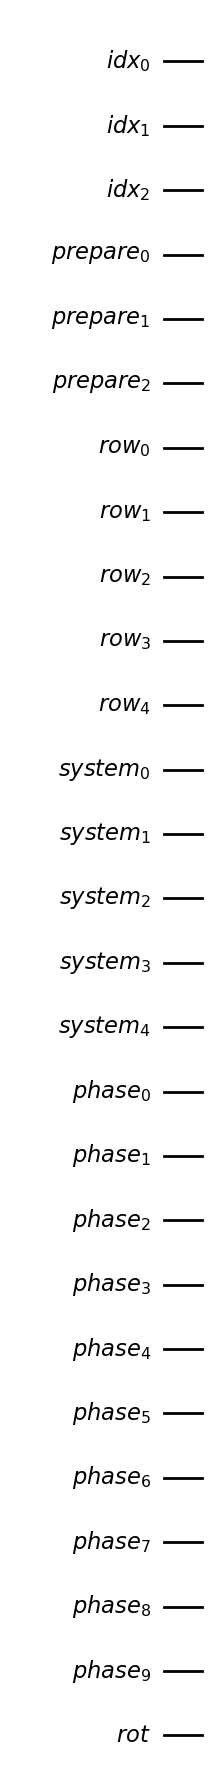

In [42]:
# ============================================================
# Cell 33 : Master HHL Circuit Initialization
# ============================================================

#
# This cell creates the master HHL circuit
# and allocates all registers required by
# the architecture frozen in Cell 22.
#
#
# Register order:
#
#     index
#     prepare
#     row
#     system
#     phase
#     rotation
#
#
# No HHL operations are applied yet.
#
# This cell only creates the circuit
# skeleton that later cells will populate.
#

from qiskit import QuantumCircuit
from qiskit import QuantumRegister


# ============================================================
# Register allocation
# ============================================================

idx_reg = QuantumRegister(
    n_index_reg,
    name="idx"
)

prepare_reg = QuantumRegister(
    n_prepare_reg,
    name="prepare"
)

row_reg = QuantumRegister(
    n_row_reg,
    name="row"
)

system_reg = QuantumRegister(
    n_system_reg,
    name="system"
)

phase_reg = QuantumRegister(
    n_phase_reg,
    name="phase"
)

rotation_reg = QuantumRegister(
    n_rotation_reg,
    name="rot"
)


# ============================================================
# Master circuit
# ============================================================

HHL_CIRCUIT = QuantumCircuit(

    idx_reg,

    prepare_reg,

    row_reg,

    system_reg,

    phase_reg,

    rotation_reg,

    name="HHL_Finance"

)


# ============================================================
# Register dictionary
# ============================================================

HHL_REGISTERS = {

    "index":
        idx_reg,

    "prepare":
        prepare_reg,

    "row":
        row_reg,

    "system":
        system_reg,

    "phase":
        phase_reg,

    "rotation":
        rotation_reg
}


# ============================================================
# Register size summary
# ============================================================

HHL_REGISTER_SIZES = {

    "index":
        n_index_reg,

    "prepare":
        n_prepare_reg,

    "row":
        n_row_reg,

    "system":
        n_system_reg,

    "phase":
        n_phase_reg,

    "rotation":
        n_rotation_reg
}


# ============================================================
# Consistency checks
# ============================================================

assert (
    HHL_CIRCUIT.num_qubits
    ==
    TOTAL_HHL_QUBITS
), (
    "Master circuit qubit count "
    "does not match architecture."
)

assert (
    sum(
        HHL_REGISTER_SIZES.values()
    )
    ==
    TOTAL_HHL_QUBITS
)


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     HHL_CIRCUIT
#
#     idx_reg
#     prepare_reg
#     row_reg
#     system_reg
#     phase_reg
#     rotation_reg
#
#     HHL_REGISTERS
#     HHL_REGISTER_SIZES
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Master HHL Circuit Initialization")
print("=" * 70)

print()

print("Register allocation:")

print()

for register_name, size in (
    HHL_REGISTER_SIZES.items()
):

    print(
        f"{register_name:<12s}: "
        f"{size}"
    )

print()

print(
    f"Total qubits                   : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    f"Circuit depth                  : "
    f"{HHL_CIRCUIT.depth()}"
)

print()

print(
    "No HHL operations have been "
    "applied yet."
)

print()

print(
    "Next step:"
)

print(
    "  Attach U_b state preparation"
)

print()

print(
    "Exported objects:"
)

print()

print(
    "  HHL_CIRCUIT"
)

print(
    "  HHL_REGISTERS"
)

print(
    "  HHL_REGISTER_SIZES"
)

print()

print("=" * 70)


# ============================================================
# Optional circuit display
# ============================================================

display(
    HHL_CIRCUIT.draw(
        "mpl",
        fold=-1
    )
)


HHL Assembly : State Preparation

Applied block:

  U_b

Logical effect:

|0>_idx |0>_system
    -->
|0>_idx |b>_system

Depth information:

Logical depth                : 1
Expanded depth               : 30

Total qubits                 : 27

Support size (rho)           : 3
Padded support size (delta)  : 4

MCX count                    : 13

State preparation complete.

Next step:
  Attach the QPE(W) block


Displaying only the registers relevant to U_b:



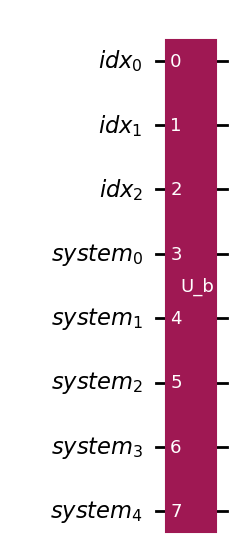

In [43]:
# ============================================================
# Cell 34 : Attach Shock-State Preparation
# ============================================================

#
# This cell applies
#
#     U_b
#
# to the master HHL circuit.
#
#
# Logical action:
#
#     |0>_idx |0>_system
#
#         -->
#
#     |0>_idx |b>_system
#
#
# The index register is internally used
# during state preparation and is returned
# to |0> by the end of U_b.
#

from qiskit import QuantumCircuit


# ============================================================
# Apply U_b
# ============================================================

HHL_CIRCUIT.append(

    UB_GATE,

    list(idx_reg)
    +
    list(system_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

#
# Logical depth:
#
# Treats U_b as a single opaque block.
#

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

#
# Expanded depth:
#
# Uses the verified implementation
# from Cell 23.
#

CURRENT_EXPANDED_DEPTH = (
    STATE_PREP_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "State Preparation Complete"
)

CURRENT_HHL_STATE = (
    "|0>_idx |b>_system"
)


# ============================================================
# Progress object
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

#
# Show only the registers relevant
# to the state-preparation block.
#

UB_VIEW = QuantumCircuit(

    idx_reg,

    system_reg,

    name="U_b_View"

)

UB_VIEW.append(

    UB_GATE,

    list(idx_reg)
    +
    list(system_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : State Preparation")
print("=" * 70)

print()

print("Applied block:")

print()

print("  U_b")

print()

print("Logical effect:")

print()

print(
    "|0>_idx |0>_system"
)

print(
    "    -->"
)

print(
    "|0>_idx |b>_system"
)

print()

print("Depth information:")

print()

print(
    f"Logical depth                : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print(
    f"Expanded depth               : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    f"Total qubits                 : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    f"Support size (rho)           : "
    f"{B_STATE_RHO}"
)

print(
    f"Padded support size (delta)  : "
    f"{B_STATE_DELTA}"
)

print()

print(
    f"MCX count                    : "
    f"{STATE_PREP_METADATA['mcx_count']}"
)

print()

print(
    "State preparation complete."
)

print()

print("Next step:")

print(
    "  Attach the QPE(W) block"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only the registers "
    "relevant to U_b:\n"
)

display(
    UB_VIEW.draw(
        "mpl",
        fold=-1
    )
)


Abstract QPE(W) / IQPE(W) Blocks

Registers:

PREPARE register             : 3
Row register                 : 5
System register              : 5
Phase register               : 10

QPE powers:

[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

Phase precision              : 1.00e-03

Oracle resources:

W calls                      : 1023
PREPARE calls                : 2046
SELECT calls                 : 1023
Reflection calls             : 1023

Exported objects:

  QPE_BLOCK_GATE
  IQPE_BLOCK_GATE
  QPE_POWER_LIST
  QPE_BLOCK_SPECIFICATION
  QPE_RESOURCE_ESTIMATE


Displaying only registers relevant to QPE:



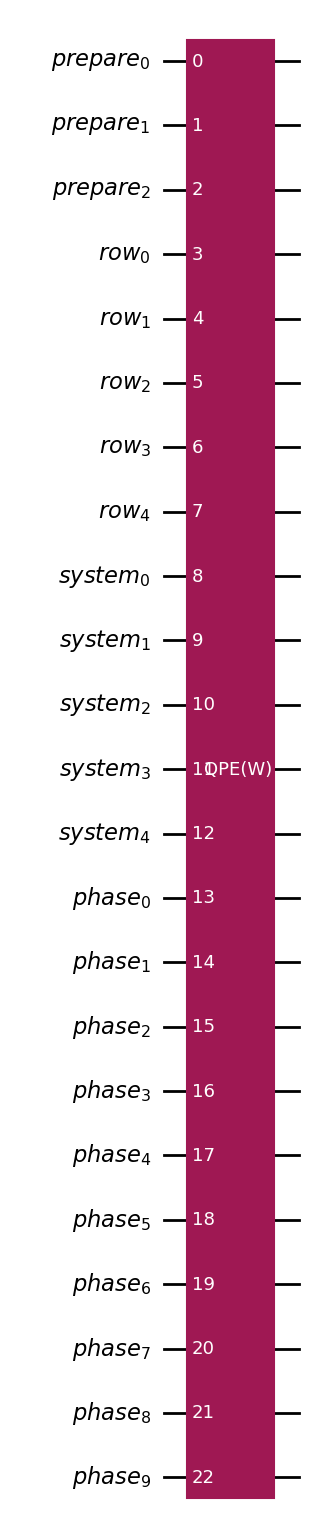

In [45]:
# ============================================================
# Cell 35 : Build Abstract QPE(W) Block
# ============================================================

#
# This cell constructs the abstract
# qubitization-based QPE block.
#
#
# Registers:
#
#     phase
#     prepare
#     row
#     system
#
#
# The walk operator
#
#     W
#
# remains an oracle-level abstraction.
#
#
# This cell DOES NOT attach QPE
# to the master HHL circuit.
#
# It merely constructs the reusable
# QPE block.
#

from qiskit import QuantumCircuit
from qiskit import QuantumRegister
from qiskit.circuit import Gate
from qiskit.circuit.library import QFT


# ============================================================
# Local QPE registers
# ============================================================

phase_qpe = QuantumRegister(
    n_phase_reg,
    name="phase"
)

prepare_qpe = QuantumRegister(
    n_prepare_reg,
    name="prepare"
)

row_qpe = QuantumRegister(
    n_row_reg,
    name="row"
)

system_qpe = QuantumRegister(
    n_system_reg,
    name="system"
)


QPE_BLOCK_CIRCUIT = QuantumCircuit(

    prepare_qpe,

    row_qpe,

    system_qpe,

    phase_qpe,

    name="QPE_W"
)





# ============================================================
# Placeholder W gate
# ============================================================

#
# W acts on:
#
#     prepare
#     row
#     system
#
# registers.
#
# We intentionally keep W abstract.
#

W_QUBITS = (

    n_prepare_reg
    +
    n_row_reg
    +
    n_system_reg
)

W_ORACLE_GATE = Gate(

    name="W",

    num_qubits=W_QUBITS,

    params=[]
)


# ============================================================
# Hadamards
# ============================================================

for q in range(
    n_phase_reg
):

    QPE_BLOCK_CIRCUIT.h(
        phase_qpe[q]
    )


QPE_BLOCK_CIRCUIT.barrier()


# ============================================================
# Controlled powers of W
# ============================================================

#
# Same convention used in the
# pedagogical notebook:
#
#     phase[m-1-k]
#
# controls
#
#     W^(2^k)
#
# so that displayed bitstrings
# appear naturally in MSB-left order.
#

for k in range(
    m_HHL
):

    power = (
        2**k
    )

    controlled_W_power = Gate(

        name=f"CW^{power}",

        num_qubits=
        1 + W_QUBITS,

        params=[]
    )

    QPE_BLOCK_CIRCUIT.append(

        controlled_W_power,

        [phase_qpe[
            n_phase_reg - 1 - k
        ]]
        +
        list(prepare_qpe)
        +
        list(row_qpe)
        +
        list(system_qpe)

    )


QPE_BLOCK_CIRCUIT.barrier()


# ============================================================
# IQFT
# ============================================================

IQFT_GATE = (

    QFT(

        num_qubits=n_phase_reg,

        inverse=True,

        do_swaps=False

    )

    .to_gate(

        label="IQFT"

    )
)

QPE_BLOCK_CIRCUIT.append(

    IQFT_GATE,

    phase_qpe

)


# ============================================================
# Convert QPE to reusable gate
# ============================================================

#
# Remove barriers before conversion.
#

QPE_BLOCK_NO_BARRIERS = (
    QPE_BLOCK_CIRCUIT
    .copy()
)

QPE_BLOCK_NO_BARRIERS.data = [

    inst

    for inst in
    QPE_BLOCK_NO_BARRIERS.data

    if inst.operation.name
    != "barrier"
]


QPE_BLOCK_GATE = (

    QPE_BLOCK_NO_BARRIERS

    .to_gate(

        label="QPE(W)"

    )
)


# ============================================================
# Explicit IQPE construction
# ============================================================

#
# IMPORTANT:
#
# We do NOT use
#
#     QPE_BLOCK_GATE.inverse()
#
# because the placeholder
#
#     CW^(2^k)
#
# gates do not possess a defined
# inverse implementation.
#
# Instead we explicitly construct
# the inverse-QPE architecture.
#

IQPE_BLOCK_CIRCUIT = QuantumCircuit(

    prepare_qpe,

    row_qpe,

    system_qpe,

    phase_qpe,

    name="IQPE_W"

)


# ------------------------------------------------------------
# Step 1:
# QFT
#
# (inverse of IQFT)
# ------------------------------------------------------------

QFT_GATE = (

    QFT(

        num_qubits=n_phase_reg,

        inverse=False,

        do_swaps=False

    )

    .to_gate(

        label="QFT"

    )
)

IQPE_BLOCK_CIRCUIT.append(

    QFT_GATE,

    phase_qpe

)


# ------------------------------------------------------------
# Step 2:
# Controlled W-dagger powers
#
# Reverse order relative to QPE.
# ------------------------------------------------------------

for k in reversed(
    range(m_HHL)
):

    power = (
        2**k
    )

    controlled_W_dagger_power = Gate(

        name=f"CWdg^{power}",

        num_qubits=
        1 + W_QUBITS,

        params=[]
    )

    IQPE_BLOCK_CIRCUIT.append(

        controlled_W_dagger_power,

        [phase_qpe[
            n_phase_reg - 1 - k
        ]]
        +
        list(prepare_qpe)
        +
        list(row_qpe)
        +
        list(system_qpe)

    )


# ------------------------------------------------------------
# Step 3:
# Hadamards
#
# (inverse of initial QPE Hadamards)
# ------------------------------------------------------------

for q in range(
    n_phase_reg
):

    IQPE_BLOCK_CIRCUIT.h(
        phase_qpe[q]
    )


# ------------------------------------------------------------
# Remove barriers and convert
# ------------------------------------------------------------

IQPE_BLOCK_NO_BARRIERS = (
    IQPE_BLOCK_CIRCUIT
    .copy()
)

IQPE_BLOCK_NO_BARRIERS.data = [

    inst

    for inst in
    IQPE_BLOCK_NO_BARRIERS.data

    if inst.operation.name
    != "barrier"
]


IQPE_BLOCK_GATE = (

    IQPE_BLOCK_NO_BARRIERS

    .to_gate(

        label="IQPE(W)"

    )
)

# ============================================================
# Resource estimates
# ============================================================

QPE_RESOURCE_ESTIMATE = {

    "phase_qubits":

        n_phase_reg,

    "w_calls":

        TOTAL_W_CALLS_QPE,

    "prepare_calls":

        TOTAL_PREPARE_CALLS_QPE,

    "select_calls":

        TOTAL_SELECT_CALLS_QPE,

    "reflection_calls":

        TOTAL_REFLECTION_CALLS_QPE,

    "power_list":

        QPE_POWER_LIST
}


# ============================================================
# Specification
# ============================================================

QPE_BLOCK_SPECIFICATION = {

    "operator":

        "W",

    "phase_qubits":

        n_phase_reg,

    "signed_phase_interval":

        "[-1/2, 1/2)",

    "phase_precision":

        EPSILON_QPE_PHASE,

    "power_list":

        QPE_POWER_LIST,

    "do_swaps":

        False,

    "control_convention":

        "phase[m-1-k]"
}


# ============================================================
# Visualization circuit
# ============================================================

QPE_VIEW = QuantumCircuit(

    prepare_qpe,

    row_qpe,

    system_qpe,

    phase_qpe

)

QPE_VIEW.append(

    QPE_BLOCK_GATE,

    list(prepare_qpe)
    +
    list(row_qpe)
    +
    list(system_qpe)
    +
    list(phase_qpe)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Abstract QPE(W) / IQPE(W) Blocks")
print("=" * 70)

print()

print("Registers:")

print()

print(
    f"PREPARE register             : "
    f"{n_prepare_reg}"
)

print(
    f"Row register                 : "
    f"{n_row_reg}"
)

print(
    f"System register              : "
    f"{n_system_reg}"
)

print(
    f"Phase register               : "
    f"{n_phase_reg}"
)

print()

print("QPE powers:")

print()

print(QPE_POWER_LIST)

print()

print(
    f"Phase precision              : "
    f"{EPSILON_QPE_PHASE:.2e}"
)

print()

print("Oracle resources:")

print()

print(
    f"W calls                      : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"PREPARE calls                : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"SELECT calls                 : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print(
    f"Reflection calls             : "
    f"{TOTAL_REFLECTION_CALLS_QPE}"
)

print()

print("Exported objects:")

print()

print(
    "  QPE_BLOCK_GATE"
)

print(
    "  IQPE_BLOCK_GATE"
)

print(
    "  QPE_POWER_LIST"
)

print(
    "  QPE_BLOCK_SPECIFICATION"
)

print(
    "  QPE_RESOURCE_ESTIMATE"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to QPE:\n"
)

display(
    QPE_VIEW.draw(
        "mpl",
        fold=-1
    )
)


HHL Assembly : QPE(W)

Applied block:

  QPE(W)

Logical action:

|0>_phase
    ⊗
Σ beta_j |u_j>

        -->

Σ beta_j |phi_j> |u_j>

Phase qubits                 : 10

Phase precision             : 1.00e-03

Oracle resources used:

W calls                     : 1023
PREPARE calls               : 2046
SELECT calls                : 1023
Reflection calls            : 1023

Current logical depth       : 2

Current expanded depth      : 1055

Current total qubits        : 27

Phase estimation complete.

Next step:
  Attach Chebyshev rotation synthesis


Displaying only registers relevant to QPE:



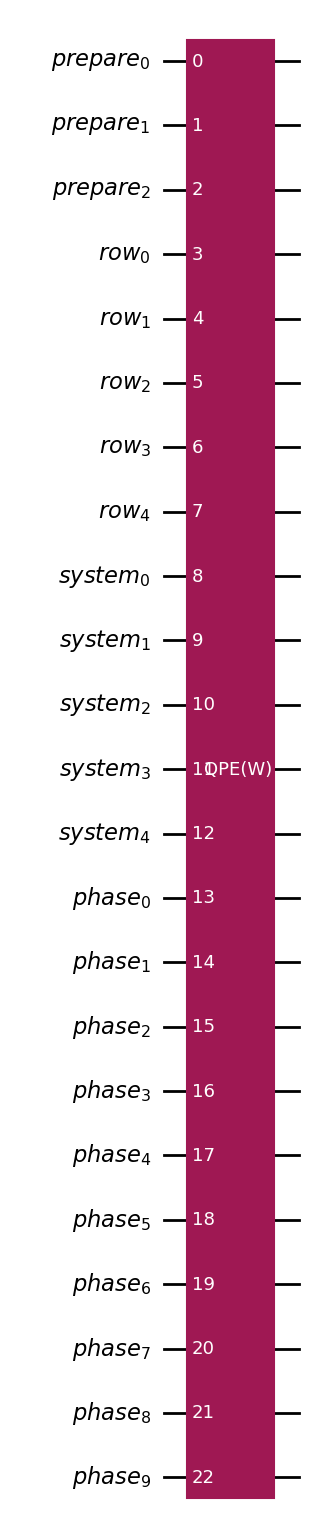

In [46]:
# ============================================================
# Cell 36 : Attach QPE(W) Block
# ============================================================

#
# This cell attaches the abstract
#
#     QPE(W)
#
# block to the master HHL circuit.
#
#
# Logical action:
#
#     |0>_phase
#         ⊗
#     Σ β_j |u_j>
#
#             -->
#
#     Σ β_j
#         |phi_j>
#         |u_j>
#
#
# where:
#
#     phi_j
#
# is the m_HHL-bit estimate of the
# eigenphase associated with the
# qubitized walk operator W.
#
#
# This is still an architecture-level
# circuit:
#
#     W
#
# remains abstract.
#

# ============================================================
# Attach QPE block
# ============================================================

HHL_CIRCUIT.append(

    QPE_BLOCK_GATE,
    

    list(prepare_reg)

    +

    list(row_reg)

    +

    list(system_reg)

    +

    list(phase_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

#
# Since QPE(W) is currently represented
# as a single composite gate, Qiskit
# underestimates the true depth.
#
# We therefore maintain a separate
# architecture-level estimate.
#

QPE_LOGICAL_DEPTH = 1

QPE_EXPANDED_DEPTH_ESTIMATE = (

    1                       # Hadamard layer

    +

    TOTAL_W_CALLS_QPE       # controlled powers

    +

    1                       # IQFT block

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (

    PREVIOUS_EXPANDED_DEPTH

    +

    QPE_EXPANDED_DEPTH_ESTIMATE

)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "QPE Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j "
    "|phi_j> |u_j>"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# QPE summary dictionary
# ============================================================

QPE_ATTACHMENT_SUMMARY = {

    "phase_qubits":
        n_phase_reg,

    "phase_precision":
        EPSILON_QPE_PHASE,

    "w_calls":
        TOTAL_W_CALLS_QPE,

    "prepare_calls":
        TOTAL_PREPARE_CALLS_QPE,

    "select_calls":
        TOTAL_SELECT_CALLS_QPE,

    "reflection_calls":
        TOTAL_REFLECTION_CALLS_QPE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

#
# Show only registers relevant
# to the QPE stage.
#

QPE_STAGE_VIEW = QuantumCircuit(

    prepare_reg,

    row_reg,

    system_reg,

    phase_reg

)

QPE_STAGE_VIEW.append(

    QPE_BLOCK_GATE,

    
    list(prepare_reg)

    +

    list(row_reg)

    +

    list(system_reg)

    +

    list(phase_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : QPE(W)")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  QPE(W)"
)

print()

print("Logical action:")

print()

print(
    "|0>_phase"
)

print(
    "    ⊗"
)

print(
    "Σ beta_j |u_j>"
)

print()

print(
    "        -->"
)

print()

print(
    "Σ beta_j |phi_j> |u_j>"
)

print()

print(
    f"Phase qubits                 : "
    f"{n_phase_reg}"
)

print()

print(
    f"Phase precision             : "
    f"{EPSILON_QPE_PHASE:.2e}"
)

print()

print("Oracle resources used:")

print()

print(
    f"W calls                     : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"PREPARE calls               : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"SELECT calls                : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print(
    f"Reflection calls            : "
    f"{TOTAL_REFLECTION_CALLS_QPE}"
)

print()

print(
    f"Current logical depth       : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current expanded depth      : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    f"Current total qubits        : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Phase estimation complete."
)

print()

print(
    "Next step:"
)

print(
    "  Attach Chebyshev rotation synthesis"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to QPE:\n"
)

display(
    QPE_STAGE_VIEW.draw(
        "mpl",
        fold=-1
    )
)


HHL Assembly : Chebyshev Rotation Synthesis

Applied block:

  R_HHL

Logical action:

|phi>|0>_rot

    -->

|phi>
(cos(omega(phi))|0> + sin(omega(phi))|1>)

Architecture:

  Direct angle encoding

  No polynomial register

  No workspace register

  Multi-controlled R_y synthesis

Phase register qubits          : 10
Rotation ancilla               : 1

Chebyshev degree               : 26
Target approximation error     : 1.00e-02

Universal coefficient bound    : 0.523599

Circuit implementation         : Deferred to Notebook B

Current logical depth          : 3

Current total qubits           : 27

Rotation synthesis attached.

Next step:
  Attach IQPE(W)


Displaying only registers relevant to rotation synthesis:



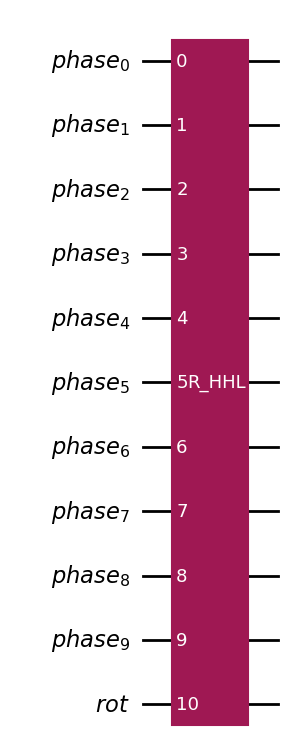

In [47]:
# ============================================================
# Cell 37 : Attach Chebyshev Rotation Synthesis
# ============================================================

#
# This cell attaches the abstract
#
#     R_HHL
#
# Chebyshev rotation-synthesis block
# to the master HHL circuit.
#
#
# Logical action:
#
#     |phi>|0>_rot
#
#         -->
#
#     |phi>
#
#     (
#         cos(omega(phi))|0>
#         +
#         sin(omega(phi))|1>
#     )
#
#
# where
#
#     omega(phi)
#
#     =
#
#     arcsin(
#         C_HHL
#         /
#         (
#             alpha_A
#             cos(2*pi*phi)
#         )
#     )
#
#
# IMPORTANT:
#
# This notebook remains purely
# architectural.
#
# The actual synthesis of the
# multi-controlled R_y network
# from the Chebyshev polynomial
# coefficients is deferred to
# Notebook B.
#

from qiskit import QuantumCircuit
from qiskit.circuit import Gate


# ============================================================
# Abstract rotation-synthesis gate
# ============================================================

ROTATION_SYNTHESIS_QUBITS = (

    n_phase_reg

    +

    n_rotation_reg

)

ROTATION_SYNTHESIS_GATE = Gate(

    name="R_HHL",

    num_qubits=ROTATION_SYNTHESIS_QUBITS,

    params=[]

)


# ============================================================
# Attach rotation-synthesis block
# ============================================================

HHL_CIRCUIT.append(

    ROTATION_SYNTHESIS_GATE,

    list(phase_reg)

    +

    list(rotation_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

#
# Architecture-level estimate.
#
# Notebook B will synthesize
# this block into a network of
#
#     R_y,
#     CR_y,
#     CCR_y,
#     ...
#
# gates.
#

ROTATION_SYNTHESIS_DEPTH_ESTIMATE = (

    f"O(2^{n_phase_reg}) exact, "
    f"O({n_phase_reg}^{chebyshev_degree}) "
    "degree-truncated"

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (
    PREVIOUS_EXPANDED_DEPTH
)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "Rotation Synthesis Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j "
    "|phi_j>|u_j>"
    "(cos(omega_j)|0>"
    " + sin(omega_j)|1>)"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Rotation synthesis summary
# ============================================================

ROTATION_SYNTHESIS_ATTACHMENT_SUMMARY = {

    "phase_qubits":
        n_phase_reg,

    "rotation_qubits":
        n_rotation_reg,

    "chebyshev_degree":
        chebyshev_degree,

    "epsilon_cheb":
        EPSILON_CHEB,

    "coefficient_bound":
        UNIVERSAL_COEFFICIENT_BOUND,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

ROTATION_SYNTHESIS_VIEW = QuantumCircuit(

    phase_reg,

    rotation_reg

)

ROTATION_SYNTHESIS_VIEW.append(

    ROTATION_SYNTHESIS_GATE,

    list(phase_reg)

    +

    list(rotation_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : Chebyshev Rotation Synthesis")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  R_HHL"
)

print()

print("Logical action:")

print()

print(
    "|phi>|0>_rot"
)

print()

print(
    "    -->"
)

print()

print(
    "|phi>"
)

print(
    "("
    "cos(omega(phi))|0>"
    " + "
    "sin(omega(phi))|1>"
    ")"
)

print()

print(
    "Architecture:"
)

print()

print(
    "  Direct angle encoding"
)

print()

print(
    "  No polynomial register"
)

print()

print(
    "  No workspace register"
)

print()

print(
    "  Multi-controlled R_y synthesis"
)

print()

print(
    f"Phase register qubits          : "
    f"{n_phase_reg}"
)

print(
    f"Rotation ancilla               : "
    f"{n_rotation_reg}"
)

print()

print(
    f"Chebyshev degree               : "
    f"{chebyshev_degree}"
)

print(
    f"Target approximation error     : "
    f"{EPSILON_CHEB:.2e}"
)

print()

print(
    f"Universal coefficient bound    : "
    f"{UNIVERSAL_COEFFICIENT_BOUND:.6f}"
)

print()

print(
    "Circuit implementation         : "
    "Deferred to Notebook B"
)

print()

print(
    f"Current logical depth          : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current total qubits           : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Rotation synthesis attached."
)

print()

print(
    "Next step:"
)

print(
    "  Attach IQPE(W)"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to rotation synthesis:\n"
)

display(

    ROTATION_SYNTHESIS_VIEW.draw(

        "mpl",

        fold=-1

    )

)

In [50]:
# ============================================================
# Cell 38 : (Reserved)
# ============================================================

#
# Reserved for compatibility with
# Version 1 of Notebook A.
#
# In Version 2, the controlled rotation
# is incorporated directly into the
# Chebyshev Rotation Synthesis block
# (Cell 37).
#
;

''

In [52]:
# ============================================================
# Cell 39 : (Reserved)
# ============================================================

#
# Reserved for compatibility with
# Version 1 of Notebook A.
#
# In Version 2, no polynomial register
# or workspace register exists, so no
# polynomial uncomputation is required.
#
;

''


HHL Assembly : IQPE(W)

Applied block:

  IQPE(W)

Logical effect:

Phase register returned to |0> (Phase information has been uncomputed).

The reciprocal amplitudes produced by the Chebyshev rotation synthesis
remain encoded in the rotation ancilla.

W calls                     : 1023

Current logical depth       : 4

Current expanded depth      : 2080

Registers logically reset:

  - phase

Current total qubits        : 27

Inverse phase estimation complete.

Next step:
  Analyze success probability


Displaying only registers relevant to IQPE:



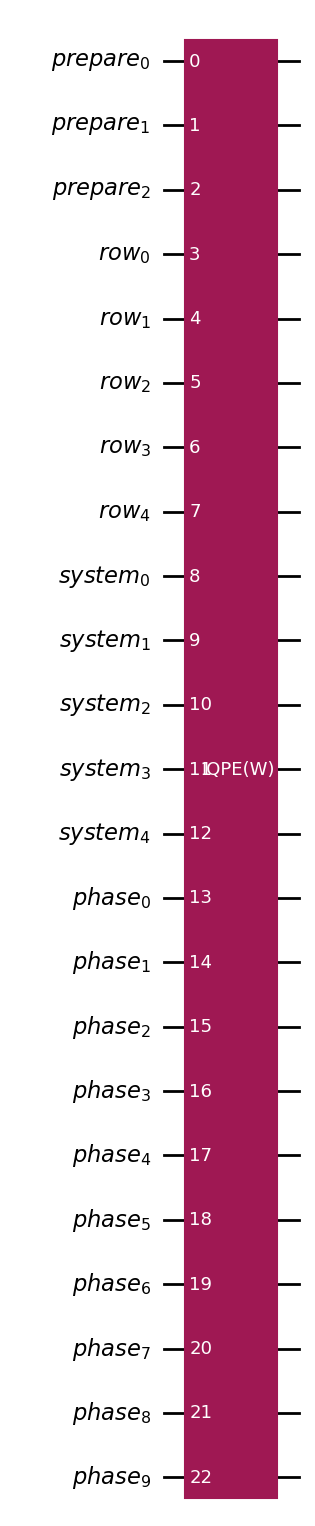

In [53]:
# ============================================================
# Cell 40 : Attach IQPE(W)
# ============================================================

#
# This cell attaches
#
#     IQPE(W)
#
# to the master HHL circuit.
#
#
# Logical action:
#
#     Σ beta_j
#         |phi_j>
#         |u_j>
#
#         (
#             cos(omega_j)|0>
#             +
#             sin(omega_j)|1>
#         )
#
#
#             -->
#
#
#     |0>_phase
#
#         ⊗
#
#     Σ beta_j
#         |u_j>
#
#         (
#             cos(omega_j)|0>
#             +
#             sin(omega_j)|1>
#         )
#
#
# Thus:
#
#     phase register
#
# is uncomputed.
#
# After Chebyshev rotation synthesis,
# the phase register remains entangled
# with the system register.
# 
# IQPE removes this phase information,
# returning the phase register to |0>,
# while leaving the rotation ancilla
# unchanged.
#


# ============================================================
# Attach IQPE block
# ============================================================

HHL_CIRCUIT.append(

    IQPE_BLOCK_GATE,

    list(prepare_reg)
    + list(row_reg)
    + list(system_reg)
    + list(phase_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

IQPE_EXPANDED_DEPTH_ESTIMATE = (

    1                       # QFT

    +

    TOTAL_W_CALLS_QPE       # controlled W† powers

    +

    1                       # Hadamard layer

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (

    PREVIOUS_EXPANDED_DEPTH

    +

    IQPE_EXPANDED_DEPTH_ESTIMATE

)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "IQPE Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j |u_j> "
    "(cos(omega_j)|0> + "
    "sin(omega_j)|1>)"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# IQPE summary
# ============================================================

IQPE_ATTACHMENT_SUMMARY = {

    "phase_qubits":
        n_phase_reg,

    "w_calls":

        TOTAL_W_CALLS_QPE,

    "prepare_calls":

        TOTAL_PREPARE_CALLS_QPE,

    "select_calls":

        TOTAL_SELECT_CALLS_QPE,

    "reflection_calls":

        TOTAL_REFLECTION_CALLS_QPE,

    "logical_depth":

        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":

        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Registers now reset
# ============================================================

RESET_REGISTERS = [

    "phase"

]

# ============================================================
# Visualization circuit
# ============================================================

IQPE_STAGE_VIEW = QuantumCircuit(

    prepare_reg,

    row_reg,

    system_reg,

    phase_reg

)

IQPE_STAGE_VIEW.append(

    IQPE_BLOCK_GATE,

    
    list(prepare_reg)

    +

    list(row_reg)

    +

    list(system_reg)

    +

    list(phase_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : IQPE(W)")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  IQPE(W)"
)

print()

print("Logical effect:")

print()

print(
    "Phase register returned to |0> (Phase information has been uncomputed)."
)

print()

print(
    "The reciprocal amplitudes produced by the Chebyshev rotation synthesis"
)

print(
    "remain encoded in the rotation ancilla."
)

print()

print(
    f"W calls                     : "
    f"{TOTAL_W_CALLS_QPE}"
)

print()

print(
    f"Current logical depth       : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current expanded depth      : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    "Registers logically reset:"
)

print()

for register in RESET_REGISTERS:

    print(
        f"  - {register}"
    )

print()

print(
    f"Current total qubits        : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Inverse phase estimation complete."
)

print()

print(
    "Next step:"
)

print(
    "  Analyze success probability"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to IQPE:\n"
)

display(
    IQPE_STAGE_VIEW.draw(
        "mpl",
        fold=-1
    )
)


Full HHL Architecture Summary

Pipeline:

U_b
 -> QPE(W)
 -> Chebyshev Rotation Synthesis
 -> IQPE(W)


Register Summary

index          3
prepare        3
row            5
system         5
phase          10
rotation       1

TOTAL          27


Complexity Summary

U_b            O(log^2(N))
QPE(W)         O((1/EPSILON_QPE_PHASE) polylog(N)) = O(kappa^2 polylog(N))
R_HHL          O(2^m_HHL) for the full Boolean expansion, O(m_HHL^degree) when restricted to monomials of degree at most degree
IQPE(W)        O((1/EPSILON_QPE_PHASE) polylog(N)) = O(kappa^2 polylog(N))
OVERALL        Dominated by QPE/IQPE: O(kappa^2 polylog(N)) for the chosen parameter regime.


Success Probability


KAPPA_BOUND                : 3.0000

Worst-case lower bound      : 0.090000

Amplitude amplification not included in this prototype.


Registers Explicitly Reset


  phase

prepare and row registers
are expected to return to |0>
through the inverse
qubitized walk operator.


Remaining Active Information


syst

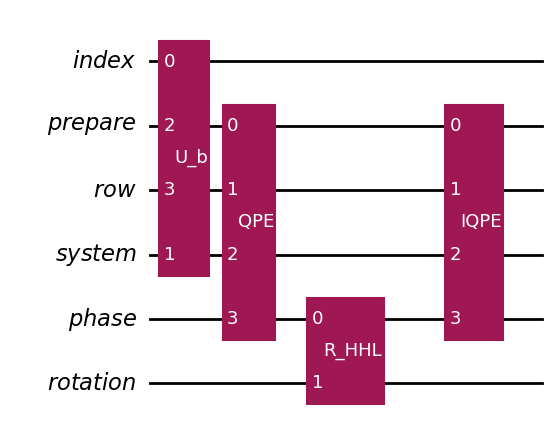

In [54]:
# ============================================================
# Cell 41 : Full HHL Architecture Summary
# ============================================================

#
# This cell summarizes the complete
# HHL architecture assembled so far.
#
#
# Pipeline:
#
#     U_b
#
#     QPE(W)
#
#     Chebyshev Rotation Synthesis
#
#     IQPE(W)
#
#
# The next cell begins the
# measurement / readout layer.
#

from qiskit import (
    QuantumCircuit,
    QuantumRegister
)
from qiskit.circuit import Gate


# ============================================================
# Architecture visualization
# ============================================================

idx_view = QuantumRegister(
    1,
    "index"
)

prepare_view = QuantumRegister(
    1,
    "prepare"
)

row_view = QuantumRegister(
    1,
    "row"
)

system_view = QuantumRegister(
    1,
    "system"
)

phase_view = QuantumRegister(
    1,
    "phase"
)

rotation_view = QuantumRegister(
    1,
    "rotation"
)


ARCHITECTURE_VIEW = QuantumCircuit(

    idx_view,
    prepare_view,
    row_view,
    system_view,
    phase_view,
    rotation_view

)


# ------------------------------------------------------------
# Symbolic gates
# ------------------------------------------------------------

UB_VIEW = Gate(
    name="U_b",
    num_qubits=4,
    params=[]
)

QPE_VIEW_GATE = Gate(
    name="QPE",
    num_qubits=4,
    params=[]
)

ROTATION_VIEW_GATE = Gate(
    name="R_HHL",
    num_qubits=2,
    params=[]
)

IQPE_VIEW_GATE = Gate(
    name="IQPE",
    num_qubits=4,
    params=[]
)


# ------------------------------------------------------------
# U_b
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    UB_VIEW,

    [

        idx_view[0],

        system_view[0],

        prepare_view[0],

        row_view[0]

    ]

)


# ------------------------------------------------------------
# QPE
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    QPE_VIEW_GATE,

    [

        prepare_view[0],

        row_view[0],

        system_view[0],

        phase_view[0]

    ]

)


# ------------------------------------------------------------
# Chebyshev Rotation Synthesis
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    ROTATION_VIEW_GATE,

    [

        phase_view[0],

        rotation_view[0]

    ]

)


# ------------------------------------------------------------
# IQPE
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    IQPE_VIEW_GATE,

    [

        prepare_view[0],

        row_view[0],

        system_view[0],

        phase_view[0]

    ]

)


# ============================================================
# Register table
# ============================================================

REGISTER_SUMMARY = {

    "index":
        n_index_reg,

    "prepare":
        n_prepare_reg,

    "row":
        n_row_reg,

    "system":
        n_system_reg,

    "phase":
        n_phase_reg,

    "rotation":
        n_rotation_reg

}

TOTAL_QUBITS_SUMMARY = sum(
    REGISTER_SUMMARY.values()
)


# ============================================================
# Complexity table
# ============================================================

BLOCK_COMPLEXITIES = [

    (
        "U_b",
        "O(log^2(N))"
    ),

    (
        "QPE(W)",
        "O((1/EPSILON_QPE_PHASE) polylog(N)) = O(kappa^2 polylog(N))"
    ),

    (
        "R_HHL",
        (
            "O(2^m_HHL) for the full Boolean expansion, "
            "O(m_HHL^degree) when restricted to monomials "
            "of degree at most degree"
        )
    ),

    (
        "IQPE(W)",
        "O((1/EPSILON_QPE_PHASE) polylog(N)) = O(kappa^2 polylog(N))"
    ),

    (
        "OVERALL",
        (
            "Dominated by QPE/IQPE: "
            "O(kappa^2 polylog(N)) "
            "for the chosen parameter regime."
        )
    )

]


# ============================================================
# Final logical state
# ============================================================

FINAL_LOGICAL_STATE = """

|0>_phase

⊗

Σ_j β_j |u_j>

(

sqrt(1-(C_HHL/lambda_j)^2)|0>

+

(C_HHL/lambda_j)|1>

)

"""


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Full HHL Architecture Summary")
print("=" * 70)

print()

print("Pipeline:")

print()

print("U_b")

print(" -> QPE(W)")

print(" -> Chebyshev Rotation Synthesis")

print(" -> IQPE(W)")

print()

print("=" * 70)

print()
print("Register Summary")
print()
print("=" * 70)

for reg_name, reg_size in REGISTER_SUMMARY.items():

    print(
        f"{reg_name:<15}{reg_size}"
    )

print()

print(
    f"{'TOTAL':<15}"
    f"{TOTAL_QUBITS_SUMMARY}"
)

print()

print("=" * 70)

print()
print("Complexity Summary")
print()
print("=" * 70)

for block, complexity in BLOCK_COMPLEXITIES:

    print(
        f"{block:<15}{complexity}"
    )

print()

print("=" * 70)

print()
print("Success Probability")
print()
print("=" * 70)

print()

print(
    f"KAPPA_BOUND                : "
    f"{KAPPA_BOUND:.4f}"
)

print()

print(
    f"Worst-case lower bound      : "
    f"{SUCCESS_PROBABILITY_LOWER_BOUND:.6f}"
)

print()

print(
    "Amplitude amplification "
    "not included in this prototype."
)

print()

print("=" * 70)

print()
print("Registers Explicitly Reset")
print()
print("=" * 70)

print()

print("  phase")

print()

print(
    "prepare and row registers"
)

print(
    "are expected to return to |0>"
)

print(
    "through the inverse"
)

print(
    "qubitized walk operator."
)

print()

print("=" * 70)

print()
print("Remaining Active Information")
print()
print("=" * 70)

print()

print("system register")

print("rotation ancilla")

print()

print("=" * 70)

print()
print("Final Logical State")
print()
print("=" * 70)

print(
    FINAL_LOGICAL_STATE
)

print()

print("=" * 70)

print()

print(
    "Next step:"
)

print(
    "Measurement and readout machinery"
)

print()

print("=" * 70)


# ============================================================
# Architecture diagram
# ============================================================

print(
    "\nRegister-level architecture diagram:\n"
)

display(

    ARCHITECTURE_VIEW.draw(

        "mpl",

        fold=-1

    )

)

In [59]:
# ============================================================
# Cell 42 : Financial Readout Architecture
# ============================================================

#
# This cell formalizes how useful
# financial information will be
# extracted from the final HHL state.
#
#
# Final HHL state:
#
#     |x>
#
# =
#
#     Σ_i x_i |i>
#
#
# where:
#
#     x_i
#
# represents the relative risk score
# associated with node i.
#
#
# Two application-level readout modes
# are supported:
#
#
# ------------------------------------------------------------
# Mode 1
# ------------------------------------------------------------
#
#     Top-k risky node discovery
#
#
# ------------------------------------------------------------
# Mode 2
# ------------------------------------------------------------
#
#     Risk-score estimation for a
#     specified node eta.
#

# ============================================================
# Use Case 1
# ============================================================

TOP_K_READOUT = {

    "name":

        "Top-k risky node discovery",

    "goal":

        (
            "Identify the nodes having "
            "largest amplitudes in |x>."
        ),

    "measurement":

        (
            "Repeated sampling of the "
            "system register conditioned "
            "on successful ancilla "
            "post-selection."
        ),

    "post_processing":

        (
            "Remove dummy nodes and "
            "rank surviving nodes by "
            "observed frequency."
        ),

    "sample_complexity":

        "O(k), but depends on desired confidence.",

    "output":

        "Top-k risk-ranked nodes"
}


# ============================================================
# Use Case 2
# ============================================================

NODE_RISK_READOUT = {

    "name":

        "Single-node risk estimation",

    "goal":

        (
            "Estimate the solution value (risk score) "
            "associated with a chosen "
            "node eta."
        ),

    "observable":

        "|eta><eta|",

    "measurement":

        (
            "Estimate probability "
            "|x_eta|^2."
        ),

    "reconstruction":

        (
            "x_eta = sqrt(|x_eta|^2)"
        ),

    "assumption":

        (
            "Model 1 and Model 2 produce "
            "nonnegative real solutions."
        ),

    "output":

        "Estimated solution value (risk score) of node eta"
}


# ============================================================
# Readout complexity
# ============================================================

READOUT_COMPLEXITY = {

    "top_k":

        "O(k)",

    "single_node":

        "O(1/epsilon_measure^2)",

    "requires_full_vector":

        False
}


# ============================================================
# Interpretation notes
# ============================================================

INTERPRETATION_NOTES = [

    (
        "Risk rankings are relative "
        "rather than absolute."
    ),

    (
        "Only measurement statistics from the final "
        "state are required."
    ),

    (
        "No reconstruction of the full "
        "N-dimensional solution vector "
        "is performed."
    ),

    (
        "This preserves the quantum "
        "advantage of HHL."
    )
]


# ============================================================
# Measurement architecture
# ============================================================

MEASUREMENT_ARCHITECTURE = {

    "active_registers":

        [
            "system",
            "rotation"
        ],

    "postselection":

        (
            "Condition on rotation "
            "ancilla = 1."
        ),

    "top_k":

        TOP_K_READOUT,

    "single_node":

        NODE_RISK_READOUT
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Financial Readout Architecture")
print("=" * 70)

print()

print("Final active registers:")

print()

print("  system")
print("  rotation")

print()

print("Post-selection condition:")

print()

print(
    "  rotation ancilla = 1"
)

print()

print("=" * 70)

print()
print("Use Case 1 : Top-k Risk Discovery")
print()
print("=" * 70)

print()

print(
    TOP_K_READOUT["goal"]
)

print()

print(
    f"Sample complexity : "
    f"{TOP_K_READOUT['sample_complexity']}"
)

print()

print(
    f"Output : "
    f"{TOP_K_READOUT['output']}"
)

print()

print("=" * 70)

print()
print("Use Case 2 : Single Node Risk")
print()
print("=" * 70)

print()

print(
    NODE_RISK_READOUT["goal"]
)

print()

print(
    "Observable:"
)

print()

print(
    f"  {NODE_RISK_READOUT['observable']}"
)

print()

print(
    f"Reconstruction : "
    f"{NODE_RISK_READOUT['reconstruction']}"
)

print()

print("=" * 70)

print()
print("Interpretation")
print()
print("=" * 70)

print()

for item in INTERPRETATION_NOTES:

    print(
        f"- {item}"
    )

print()

print("=" * 70)

print()

print(
    "Notebook A complete."
)

print()

print(
    "Next stage:"
)

print(
    "Notebook B: "
    "Executable validation "
    "of the assembled HHL pipeline."
)

print()

print("=" * 70)


Financial Readout Architecture

Final active registers:

  system
  rotation

Post-selection condition:

  rotation ancilla = 1


Use Case 1 : Top-k Risk Discovery


Identify the nodes having largest amplitudes in |x>.

Sample complexity : O(k), but depends on desired confidence.

Output : Top-k risk-ranked nodes


Use Case 2 : Single Node Risk


Estimate the solution value (risk score) associated with a chosen node eta.

Observable:

  |eta><eta|

Reconstruction : x_eta = sqrt(|x_eta|^2)


Interpretation


- Risk rankings are relative rather than absolute.
- Only measurement statistics from the final state are required.
- No reconstruction of the full N-dimensional solution vector is performed.
- This preserves the quantum advantage of HHL.


Notebook A complete.

Next stage:
Notebook B: Executable validation of the assembled HHL pipeline.

